In [1]:
import pandas as pd
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

pd.set_option('display.max_columns', 500)
pd.set_option('display.max_rows', 500)
import matplotlib.pyplot as plt
import seaborn as sns
import lightgbm as lgb
from sklearn import preprocessing, metrics
import optuna
from sklearn.model_selection import StratifiedKFold, KFold, RepeatedKFold, GroupKFold, GridSearchCV, train_test_split, TimeSeriesSplit
import gc
import os

In [2]:
# Source - https://stackoverflow.com/a/20896732
# Posted by pzp, modified by community. See post 'Timeline' for change history
# Retrieved 2026-04-01, License - CC BY-SA 4.0

import sys
print(sys.version)


3.12.7 | packaged by conda-forge | (main, Oct  4 2024, 15:47:54) [MSC v.1941 64 bit (AMD64)]


In [19]:
# df = pd.read_csv('../data/processed/room_monthly_features_v5.2.csv') 
# df = pd.read_csv('../data/processed/room_monthly_features_v6.csv') # 
# df = pd.read_csv('../data/processed/room_monthly_features_v7.3.csv')
# df = pd.read_csv('../data/processed/room_monthly_features_v7.4.csv')# Best so far
df = pd.read_csv('../data/processed/room_monthly_features_v8.csv')
df.head()

,month_period,id,masterId,propertyId,roomId,numChild,price,commission,range_booking_arrival,num_of_nights,price_per_day,status_confirmed,status_new,subStatus_noShow,subStatus_nonPayment,subStatus_none,subStatus_walkin,title_Honeymoon_decor,title_RO,title_Teman_kim_kasih_breakfast,title_Twin_bed,arrivalTime_16_30,arrivalTime__,groupNote_Room_Only_,custom1_Paid_OTA,custom1_Paid_by_OTA_Auto_Adjusted,referer_Booking_com,refererEditable_Booking_com,channel_booking,apiSource_Booking_com,allowChannelUpdate_all,allowAutoAction_disable,allowAutoAction_enable,allowReview_default,allowCancellation__type_propertyDefault_,cancelTime_2024_08_05T03_15_10Z,year,month,year_month,total_capacity_nights,used_room_nights,leftover_rooms,cal_days_covered,cal_numAvail_mean,cal_numAvail_min,cal_numAvail_max,cal_numAvail_std,cal_numAvail_zero_days,cal_numAvail_low_days,cal_minStay_mean,cal_minStay_max,cal_minStay_restrict_days,cal_maxStay_mean,cal_multiplier_mean,cal_multiplier_max,cal_override_days,cal_soldout_rate,cal_low_avail_rate,cal_restrict_rate,cal_override_rate,prop_latitude,prop_longitude,prop_checkin_start_min,prop_checkin_end_min,prop_checkout_end_min,prop_booking_cutoff_hour,prop_vat_rate,prop_feature_codes_count,prop_group_keywords_count,prop_type_bedAndBreakfast,prop_type_bungalow,prop_type_guesthouse,prop_type_hotel,prop_type_resort,prop_type_villa,prop_country_ID,ch_channel_count,ch_enabled_ratio,ch_publish_ratio,ch_connect_inventory_ratio,ch_connect_limited_ratio,ch_price_per_day_ratio,review_count,avg_review_score,avg_facilities_score,avg_comfort_score,avg_staff_score,avg_value_score,avg_clean_score,avg_location_score,tfidf_beach,tfidf_clean,tfidf_da,tfidf_de,tfidf_der,tfidf_die,tfidf_el,tfidf_en,tfidf_est,tfidf_et,tfidf_friendly,tfidf_good,tfidf_great,tfidf_hotel,tfidf_la,tfidf_le,tfidf_location,tfidf_muy,tfidf_nice,tfidf_place,tfidf_pool,tfidf_que,tfidf_room,tfidf_sehr,tfidf_staff,tfidf_stay,tfidf_super,tfidf_trs,tfidf_un,tfidf_und,qty,room_cfg_qty_raw,room_cfg_min_price,room_cfg_min_stay,room_cfg_max_stay,room_cfg_max_people,room_cfg_max_adult,room_cfg_max_children,room_cfg_tax_percentage,room_cfg_tax_person,room_cfg_rack_rate,room_cfg_cleaning_fee,room_cfg_security_deposit,room_cfg_sell_priority,room_cfg_room_size,room_cfg_block_after_checkout_days,room_cfg_control_priority,room_cfg_include_in_reports,room_cfg_units_count,room_cfg_has_unallocated_unit,room_cfg_feature_count,room_cfg_roomType_bungalow,room_cfg_roomType_double,room_cfg_roomType_family,room_cfg_roomType_quadruple,room_cfg_roomType_single,room_cfg_roomType_triple,room_cfg_roomType_twin,room_cfg_roomType_twindouble,room_cfg_roomType_villa,room_cfg_restrictionStrategy_staythrough,room_cfg_overbookingProtection_property,room_cfg_overbookingProtection_room,room_cfg_unitAllocation_perbooking,room_fc_airport_shuttle,room_fc_air_conditioning,room_fc_baggage_storage,room_fc_balcony,room_fc_bar,room_fc_bathrobe,room_fc_bathroom,room_fc_bath_or_shower,room_fc_bath_shower,room_fc_bath_toilet,room_fc_beach,room_fc_beach_front,room_fc_beach_view,room_fc_bedroom,room_fc_bed_double,room_fc_bed_single,room_fc_bicycle,room_fc_breakfast_included,room_fc_breakfast_in_room,room_fc_breakfast_possible,room_fc_cable,room_fc_car_available,room_fc_cleaning_included,room_fc_cleaning_possible,room_fc_closets_in_room,room_fc_coffee_maker,room_fc_cycling,room_fc_deck_patio_uncovered,room_fc_desk,room_fc_dining_area,room_fc_dining_room_seats,room_fc_garden,room_fc_hair_dryer,room_fc_hangers,room_fc_iron,room_fc_kettle,room_fc_laptop_friendly,room_fc_linens,room_fc_luxory_linen,room_fc_minibar,room_fc_mountain_biking,room_fc_private_bathroom,room_fc_reception_24_hour,room_fc_refrigerator,room_fc_restaurant,room_fc_room_soundproofed,room_fc_safe,room_fc_satellite,room_fc_scuba_or_snorkeling,room_fc_separate_toilet_area,room_fc_shampoo,room_fc_sitting_area,room_fc_tables_and_chairs,room_fc_toiletries,room_fc_towels,room_fc_tv,room_fc_tv_hd_32_plus,room_fc_wakeupcall,room_fc_wifi
0,2023-01,3.718405e+

In [20]:
import pandas as pd
import numpy as np

def create_continuous_calendar_grid(df):
    """
    Forces the dataframe to have a continuous row for every month 
    between the min and max date for every room.
    """
    print("Building continuous calendar grid...")
    df = df.copy()
    
    # 1. Ensure date is datetime
    if 'date' not in df.columns:
        if pd.api.types.is_period_dtype(df['month_period']):
            df['date'] = df['month_period'].dt.to_timestamp()
        else:
            df['date'] = pd.to_datetime(df['month_period'])
            
    # 2. Get global start and end dates
    min_date = df['date'].min()
    max_date = df['date'].max()
    
    # 3. Create a perfect range of all months
    all_months = pd.date_range(start=min_date, end=max_date, freq='MS')
    all_rooms = df['roomId'].unique()
    
    # 4. Create Cartesian product (Every room gets every month)
    grid = pd.MultiIndex.from_product(
        [all_rooms, all_months], 
        names=['roomId', 'date']
    ).to_frame(index=False)
    
    # 5. Merge the real data onto the perfect grid
    full_df = pd.merge(grid, df, on=['roomId', 'date'], how='left')
    
    # 6. Rebuild month_period for the newly created empty rows
    full_df['month_period'] = full_df['date'].dt.to_period('M')
    
    # 7. Forward/Backward fill static categorical features so they aren't NaN
    static_cols = [
        "propertyId", "room_cfg_room_type", "room_cfg_restriction_strategy", 
        "room_cfg_overbooking_protection", "room_cfg_unit_allocation", "room_cfg_tier"
    ]
    for col in static_cols:
        if col in full_df.columns:
            full_df[col] = full_df.groupby('roomId')[col].transform(lambda x: x.ffill().bfill())
            
    full_df = full_df.sort_values(['roomId', 'date']).reset_index(drop=True)
    print(f"Grid built. Expanded from {len(df)} to {len(full_df)} rows to fill chronological gaps.")
    
    return full_df

In [21]:
df['price'] = df['price_per_day'] 
df = df.drop('price_per_day', axis=1)
df['date'] = pd.to_datetime(df['month_period'].astype(str))
df.head()


,month_period,id,masterId,propertyId,roomId,numChild,price,commission,range_booking_arrival,num_of_nights,status_confirmed,status_new,subStatus_noShow,subStatus_nonPayment,subStatus_none,subStatus_walkin,title_Honeymoon_decor,title_RO,title_Teman_kim_kasih_breakfast,title_Twin_bed,arrivalTime_16_30,arrivalTime__,groupNote_Room_Only_,custom1_Paid_OTA,custom1_Paid_by_OTA_Auto_Adjusted,referer_Booking_com,refererEditable_Booking_com,channel_booking,apiSource_Booking_com,allowChannelUpdate_all,allowAutoAction_disable,allowAutoAction_enable,allowReview_default,allowCancellation__type_propertyDefault_,cancelTime_2024_08_05T03_15_10Z,year,month,year_month,total_capacity_nights,used_room_nights,leftover_rooms,cal_days_covered,cal_numAvail_mean,cal_numAvail_min,cal_numAvail_max,cal_numAvail_std,cal_numAvail_zero_days,cal_numAvail_low_days,cal_minStay_mean,cal_minStay_max,cal_minStay_restrict_days,cal_maxStay_mean,cal_multiplier_mean,cal_multiplier_max,cal_override_days,cal_soldout_rate,cal_low_avail_rate,cal_restrict_rate,cal_override_rate,prop_latitude,prop_longitude,prop_checkin_start_min,prop_checkin_end_min,prop_checkout_end_min,prop_booking_cutoff_hour,prop_vat_rate,prop_feature_codes_count,prop_group_keywords_count,prop_type_bedAndBreakfast,prop_type_bungalow,prop_type_guesthouse,prop_type_hotel,prop_type_resort,prop_type_villa,prop_country_ID,ch_channel_count,ch_enabled_ratio,ch_publish_ratio,ch_connect_inventory_ratio,ch_connect_limited_ratio,ch_price_per_day_ratio,review_count,avg_review_score,avg_facilities_score,avg_comfort_score,avg_staff_score,avg_value_score,avg_clean_score,avg_location_score,tfidf_beach,tfidf_clean,tfidf_da,tfidf_de,tfidf_der,tfidf_die,tfidf_el,tfidf_en,tfidf_est,tfidf_et,tfidf_friendly,tfidf_good,tfidf_great,tfidf_hotel,tfidf_la,tfidf_le,tfidf_location,tfidf_muy,tfidf_nice,tfidf_place,tfidf_pool,tfidf_que,tfidf_room,tfidf_sehr,tfidf_staff,tfidf_stay,tfidf_super,tfidf_trs,tfidf_un,tfidf_und,qty,room_cfg_qty_raw,room_cfg_min_price,room_cfg_min_stay,room_cfg_max_stay,room_cfg_max_people,room_cfg_max_adult,room_cfg_max_children,room_cfg_tax_percentage,room_cfg_tax_person,room_cfg_rack_rate,room_cfg_cleaning_fee,room_cfg_security_deposit,room_cfg_sell_priority,room_cfg_room_size,room_cfg_block_after_checkout_days,room_cfg_control_priority,room_cfg_include_in_reports,room_cfg_units_count,room_cfg_has_unallocated_unit,room_cfg_feature_count,room_cfg_roomType_bungalow,room_cfg_roomType_double,room_cfg_roomType_family,room_cfg_roomType_quadruple,room_cfg_roomType_single,room_cfg_roomType_triple,room_cfg_roomType_twin,room_cfg_roomType_twindouble,room_cfg_roomType_villa,room_cfg_restrictionStrategy_staythrough,room_cfg_overbookingProtection_property,room_cfg_overbookingProtection_room,room_cfg_unitAllocation_perbooking,room_fc_airport_shuttle,room_fc_air_conditioning,room_fc_baggage_storage,room_fc_balcony,room_fc_bar,room_fc_bathrobe,room_fc_bathroom,room_fc_bath_or_shower,room_fc_bath_shower,room_fc_bath_toilet,room_fc_beach,room_fc_beach_front,room_fc_beach_view,room_fc_bedroom,room_fc_bed_double,room_fc_bed_single,room_fc_bicycle,room_fc_breakfast_included,room_fc_breakfast_in_room,room_fc_breakfast_possible,room_fc_cable,room_fc_car_available,room_fc_cleaning_included,room_fc_cleaning_possible,room_fc_closets_in_room,room_fc_coffee_maker,room_fc_cycling,room_fc_deck_patio_uncovered,room_fc_desk,room_fc_dining_area,room_fc_dining_room_seats,room_fc_garden,room_fc_hair_dryer,room_fc_hangers,room_fc_iron,room_fc_kettle,room_fc_laptop_friendly,room_fc_linens,room_fc_luxory_linen,room_fc_minibar,room_fc_mountain_biking,room_fc_private_bathroom,room_fc_reception_24_hour,room_fc_refrigerator,room_fc_restaurant,room_fc_room_soundproofed,room_fc_safe,room_fc_satellite,room_fc_scuba_or_snorkeling,room_fc_separate_toilet_area,room_fc_shampoo,room_fc_sitting_area,room_fc_tables_and_chairs,room_fc_toiletries,room_fc_towels,room_fc_tv,room_fc_tv_hd_32_plus,room_fc_wakeupcall,room_fc_wifi,date
0,2023-01,3.718405e+07,5.9002

In [22]:
data = df

In [23]:
import pandas as pd
import numpy as np

# 1. Load the inflation data
inflasi_df = pd.read_csv('../data/raw/inflasi.csv', sep=';')

# 2. Map Indonesian months to numbers
indo_months = {
    'Januari': '01', 'Februari': '02', 'Maret': '03', 'April': '04',
    'Mei': '05', 'Juni': '06', 'Juli': '07', 'Agustus': '08',
    'September': '09', 'Oktober': '10', 'November': '11', 'Desember': '12'
}

# 3. Clean the 'Periode' column and convert to Datetime
# Example: "Maret 2026" -> "2026-03-01"
inflasi_df['month_str'] = inflasi_df['Periode'].apply(lambda x: x.split()[0])
inflasi_df['year_str'] = inflasi_df['Periode'].apply(lambda x: x.split()[1])
inflasi_df['month_num'] = inflasi_df['month_str'].map(indo_months)
inflasi_df['date'] = pd.to_datetime(inflasi_df['year_str'] + '-' + inflasi_df['month_num'] + '-01')

# 4. Clean the 'Data Inflasi' column and convert to Float
# Example: "3.48 %" -> 3.48
inflasi_df['inflation_rate'] = inflasi_df['Data Inflasi'].str.replace(' %', '').astype(float)

# Keep only what we need
inflasi_df = inflasi_df[['date', 'inflation_rate']]

# 5. Merge into your main 'data'
# Assuming your main 'data' already has the 'date' column properly formatted
data = pd.merge(data, inflasi_df, on='date', how='left')

# Forward fill any missing inflation months just in case
data['inflation_rate'] = data['inflation_rate'].ffill().bfill()

In [24]:
df.drop(columns=['date'], inplace=True)

In [9]:

# ==========================================
# 1. INITIAL DATA PREP 
# ==========================================
# 1. Safely handle the PeriodDtype so Pandas doesn't crash
if pd.api.types.is_period_dtype(data['month_period']):
    data['date'] = data['month_period'].dt.to_timestamp()
else:
    data['date'] = pd.to_datetime(data['month_period'])

# 2. Extract year and month for global reference
data['year'] = data['date'].dt.year
data['month'] = data['date'].dt.month

# 3. Sort correctly
data = data.sort_values(["roomId", "date"]).reset_index(drop=True)

# ---------------------------------------------------------
# 🚨 OPTIONAL BUT RECOMMENDED: Run the grid fixer here! 🚨
data = create_continuous_calendar_grid(data)
# ---------------------------------------------------------

# 4. Fill missing prices (ffill/bfill or interpolate)
data["price"] = data["price"].replace(0, np.nan)
data["price"] = data.groupby("roomId")["price"].transform(lambda x: x.ffill().bfill())

overall_holdout_mape = []
overall_holdout_mae = []
best_params_by_h = {}
trained_models = {}

def safe_mape(y_true, y_pred, eps=1e-6):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    denom = np.where(np.abs(y_true) < eps, eps, np.abs(y_true))
    return np.mean(np.abs(y_true - y_pred) / denom)

Building continuous calendar grid...
Grid built. Expanded from 1372 to 2200 rows to fill chronological gaps.


In [10]:
# Create a mask to remove the 'fake' or 'broken' 2023 data for specific properties
# while keeping their 2024+ data and keeping everyone else's 2023 data.

mask_to_remove = (data['propertyId'] == 243134) & (data['date'] < '2024-01-01')
data = data[~mask_to_remove].reset_index(drop=True)

print(f"Removed pre-2024 data for Sari Gili. Remaining rows: {len(data)}")

Removed pre-2024 data for Sari Gili. Remaining rows: 2124


In [328]:
df.select_dtypes(include=['number']).columns

Index(['id', 'masterId', 'propertyId', 'roomId', 'numChild', 'price',
       'commission', 'range_booking_arrival', 'num_of_nights',
       'status_confirmed',
       ...
       'room_fc_separate_toilet_area', 'room_fc_shampoo',
       'room_fc_sitting_area', 'room_fc_tables_and_chairs',
       'room_fc_toiletries', 'room_fc_towels', 'room_fc_tv',
       'room_fc_tv_hd_32_plus', 'room_fc_wakeupcall', 'room_fc_wifi'],
      dtype='object', length=222)

In [35]:
import pandas as pd
import numpy as np

def advanced_hybrid_fe(data):
    df = data.copy()
    
    # 1. Pastikan terurut dengan benar agar fitur Shift/Rolling tidak bocor
    df = df.sort_values(['roomId', 'month_period']).reset_index(drop=True)

    # ======================
    # TIME & SEASON FEATURES (SAFE - No Leakage)
    # ======================
    df['date'] = pd.to_datetime(df['month_period'])
    df['month'] = df['date'].dt.month
    df['quarter'] = df['date'].dt.quarter
    df['year'] = df['date'].dt.year
    
    season_map = {1:0, 2:0, 11:0, 3:1, 4:1, 5:1, 6:1, 10:1, 7:2, 8:2, 9:2, 12:3}
    df['season_strength'] = df['month'].map(season_map)

    # ======================
    # HOLIDAY & PEAK SEASON FEATURES (SAFE)
    # ======================
    # 1. Peak International Tourist Months (Gili/Lombok is packed in Jul/Aug and late Dec)
    df['is_peak_season'] = df['month'].isin([7, 8, 12]).astype(int)
    
    # 2. Eid al-Fitr (Lebaran) Mapping
    # Lebaran shifts every year. Here is the mapping for the month it primarily falls in.
    eid_months = {
        2022: 5,  # May
        2023: 4,  # April
        2024: 4,  # April
        2025: 3,  # March
        2026: 3,  # March
        2027: 3   # March
    }
    
    # Check if the row's month matches the Eid month for that specific year
    df['is_eid_month'] = df.apply(lambda row: 1 if eid_months.get(row['year']) == row['month'] else 0, axis=1)

    # 3. High Demand / Holiday Month Flag (Combines Eid and End of Year)
    df['is_major_holiday_month'] = ((df['month'] == 12) | (df['is_eid_month'] == 1)).astype(int)

    # ======================
    # PRICE LAGS & ROLLING (Target Variable)
    # ======================
    price_lags = [1, 2, 3, 6, 12]
    for lag in price_lags:
        df[f'price_lag_{lag}'] = df.groupby('roomId')['price'].shift(lag)

    windows = [3, 6, 12]
    for w in windows:
        df[f'price_roll_mean_{w}'] = df.groupby('roomId')['price_lag_1'].transform(
            lambda x: x.rolling(w, min_periods=1).mean()
        )
        df[f'price_roll_std_{w}'] = df.groupby('roomId')['price_lag_1'].transform(
            lambda x: x.rolling(w, min_periods=2).std()
        )
        df[f'price_roll_max_{w}'] = df.groupby('roomId')['price_lag_1'].transform(
            lambda x: x.rolling(w, min_periods=1).max()
        )
        df[f'price_roll_min_{w}'] = df.groupby('roomId')['price_lag_1'].transform(
            lambda x: x.rolling(w, min_periods=1).min()
        )

    df['price_diff_1'] = df['price_lag_1'] - df['price_lag_2']
    df['price_diff_12'] = df['price_lag_1'] - df['price_lag_12']
    df['price_growth_1'] = df['price_diff_1'] / (df['price_lag_2'] + 1e-5)
    df['price_ema_3'] = df.groupby('roomId')['price_lag_1'].transform(
        lambda x: x.ewm(span=3, adjust=False).mean()
    )
    

    # ======================
    # NEW BEHAVIOR & OCCUPANCY LAYS (Preventing Cheating)
    # ======================
    leaky_numerical_cols = [
        'used_room_nights', 'leftover_rooms', 'range_booking_arrival', 
        'num_of_nights', 'commission', 'numChild'
    ]
    
    leaky_numerical_cols = [c for c in leaky_numerical_cols if c in df.columns]

    for col in leaky_numerical_cols:
        for lag in [1, 2, 12]:
            df[f'{col}_lag_{lag}'] = df.groupby('roomId')[col].shift(lag)
        
        df[f'{col}_roll_mean_3'] = df.groupby('roomId')[f'{col}_lag_1'].transform(
            lambda x: x.rolling(3, min_periods=1).mean()
        )

    if 'used_room_nights_lag_1' in df.columns and 'used_room_nights_lag_2' in df.columns:
        df['occupancy_trend'] = df['used_room_nights_lag_1'] - df['used_room_nights_lag_2']

    # ======================
    # SHIFTING ALL OTHER ONE-HOT / CATEGORICAL COLUMNS
    # ======================
    # UPDATE: Added our new holiday features to the "safe" list so they aren't deleted!
    safe_current_month_cols = [
        'id', 'propertyId', 'roomId', 'month_period', 'date', 
        'month', 'quarter', 'year', 'season_strength', 
        'is_peak_season', 'is_eid_month', 'is_major_holiday_month', # <-- New Safe Columns
        'total_capacity_nights', 'price'
    ]
    
    all_leaky_cols = [col for col in df.columns if col not in safe_current_month_cols and not col.endswith(('lag_1', 'lag_2', 'lag_3', 'lag_6', 'lag_12', 'mean_3', 'mean_6', 'mean_12', 'std_3', 'std_6', 'std_12', 'max_3', 'max_6', 'max_12', 'min_3', 'min_6', 'min_12', 'diff_1', 'diff_12', 'growth_1', 'ema_3', 'occupancy_trend'))]

    for col in all_leaky_cols:
        if col not in leaky_numerical_cols:
            df[f'{col}_lag_1'] = df.groupby('roomId')[col].shift(1)
            
    df['price_to_mean_ratio'] = df['price_lag_1'] / df['price_roll_mean_12']
    df['price_vs_property_avg'] = df['price_lag_1'] / df.groupby('propertyId')['price_lag_1'].transform('mean')
    df['occupancy_price_interaction'] = df['used_room_nights_lag_1'] * df['price_lag_1']      
    # Avoid division by zero
    eps = 1e-5

    # =========================
    # 1. Price vs Rolling Means
    # =========================
    if 'price_roll_mean_12' in df.columns:
        df['price_vs_roll_mean_12'] = df['price_lag_1'] / (df['price_roll_mean_12'] + eps)

    if 'price_roll_mean_6' in df.columns:
        df['price_vs_roll_mean_6'] = df['price_lag_1'] / (df['price_roll_mean_6'] + eps)

    # =========================
    # 2. Trend Features
    # =========================
    if 'price_roll_mean_3' in df.columns and 'price_roll_mean_12' in df.columns:
        df['trend_3_vs_12'] = df['price_roll_mean_3'] / (df['price_roll_mean_12'] + eps)

    if 'price_roll_mean_6' in df.columns:
        df['trend_slope'] = df['price_lag_1'] - df['price_roll_mean_6']

    # =========================
    # 3. Occupancy × Price
    # =========================
    if 'used_room_nights_lag_1' in df.columns:
        df['occupancy_price_interaction'] = (
            df['used_room_nights_lag_1'] * df['price_lag_1']
        )

    # =========================
    # 4. Property-relative pricing
    # =========================
    if 'propertyId' in df.columns:
        prop_mean = df.groupby('propertyId')['price_lag_1'].transform('mean')
        prop_std = df.groupby('propertyId')['price_lag_1'].transform('std')

        df['price_vs_property_mean'] = df['price_lag_1'] / (prop_mean + eps)
        df['price_zscore_property'] = (df['price_lag_1'] - prop_mean) / (prop_std + eps)

    # =========================
    # 5. Season interactions
    # =========================
    if 'season_strength' in df.columns:
        df['season_price_interaction'] = df['season_strength'] * df['price_lag_1']

    if 'is_peak_season' in df.columns:
        df['peak_price_interaction'] = df['is_peak_season'] * df['price_lag_1']

    # =========================
    # Optional: Growth × Season
    # =========================
    if 'price_growth_1' in df.columns and 'season_strength' in df.columns:
        df['growth_season_interaction'] = df['price_growth_1'] * df['season_strength']

    # =========================
    # Optional: Occupancy × Season
    # =========================
    if 'occupancy_trend' in df.columns and 'is_peak_season' in df.columns:
        df['occupancy_season_interaction'] = (
            df['occupancy_trend'] * df['is_peak_season']
        )
        
    # Overall market trend per month
    df['global_month_mean_price'] = df.groupby('month_period')['price_lag_1'].transform('mean')

    # Property-level market
    df['property_month_mean_price'] = df.groupby(['propertyId', 'month_period'])['price_lag_1'].transform('mean')
    # ======================
    # DROP THE CHEATING COLUMNS
    # ======================
    df = df.drop(columns=all_leaky_cols)
    
    if 'id' in df.columns:
        df = df.drop(columns=['id'])

    # ======================
    # ROOM-LEVEL STATISTICAL FEATURES date
    # ======================

    eps = 1e-5

    # # Historical mean / std / median per room (using lagged price to avoid leakage)
    # room_stats = df.groupby('roomId')['price_lag_1']

    # df['room_mean_price'] = room_stats.transform('mean')
    # df['room_median_price'] = room_stats.transform('median')
    # df['room_std_price'] = room_stats.transform('std')

    # # How current price compares to room history
    # df['price_vs_room_mean'] = df['price_lag_1'] / (df['room_mean_price'] + eps)
    # df['price_vs_room_median'] = df['price_lag_1'] / (df['room_median_price'] + eps)

    # # Z-score within room
    # df['price_zscore_room'] = (
    #     df['price_lag_1'] - df['room_mean_price']
    # ) / (df['room_std_price'] + eps)

    # # Coefficient of variation (stability of room pricing)
    # df['room_price_cv'] = df['room_std_price'] / (df['room_mean_price'] + eps)

    # # Rank of current price within room history
    # df['room_price_rank'] = df.groupby('roomId')['price_lag_1'].rank(pct=True)

    # # Rolling room mean trend (short vs long term)
    # df['room_roll_mean_3'] = df.groupby('roomId')['price_lag_1'].transform(
    #     lambda x: x.rolling(3, min_periods=1).mean()
    # )

    # df['room_roll_mean_12'] = df.groupby('roomId')['price_lag_1'].transform(
    #     lambda x: x.rolling(12, min_periods=1).mean()
    # )

    # df['room_trend_3_vs_12'] = df['room_roll_mean_3'] / (df['room_roll_mean_12'] + eps)
    
    ## add new
    # Compute property-level mean price (on TRAIN only if possible)
    # property_mean_price = df.groupby('propertyId')['price'].transform('mean')

    # # Add normalized features
    # df['property_mean_price'] = property_mean_price

    # df['price_vs_property_mean'] = df['price'] / df['property_mean_price']
    # df['price_diff_from_property'] = df['price'] - df['property_mean_price']
    df['room_price_std_6'] = df.groupby('roomId')['price_lag_1'].transform(
    lambda x: x.rolling(6, min_periods=2).std()
    )
    df['is_volatile_room'] = (df['room_price_std_6'] > df['room_price_std_6'].median()).astype(int)
    df['is_spike'] = (
        abs(df['price_lag_1'] - df['price_roll_mean_6']) 
        > 2 * df['price_roll_std_6']
    ).astype(int)
    df['price_cv_6'] = df['room_price_std_6'] / (df['price_roll_mean_6'] + 1e-5)
    return df

# Cara penggunaan:
data = advanced_hybrid_fe(df)
data['roomId'] = data['roomId'].astype('category')
data['propertyId'] = data['propertyId'].astype('category')

KeyboardInterrupt: 

In [30]:
bad_rooms = [
    350455.0,
    354681.0,
    370150.0,
    388812.0,
    419106.0,
    419296.0
]

data = data[~data['roomId'].isin(bad_rooms)].copy()

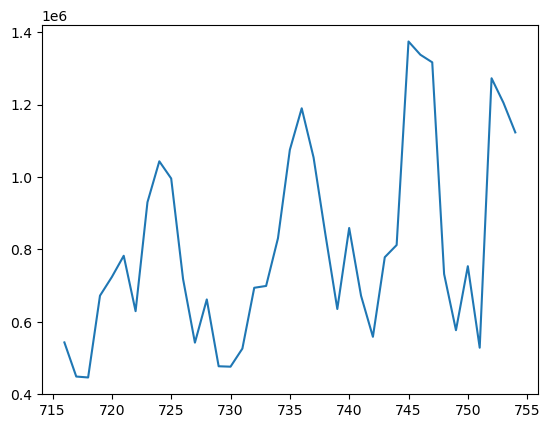

In [9]:
plt.plot(data[data["roomId"] == 388812]['price'])

In [12]:
df.groupby("roomId")["price"].mean()

roomId
350455.0    3.307837e+05
350464.0    4.901757e+05
354680.0    8.488587e+05
354681.0    8.547622e+05
354682.0    7.953104e+05
354683.0    7.948725e+05
359135.0    9.894948e+05
359136.0    1.219984e+06
359142.0    1.058381e+06
370147.0    2.306528e+05
370148.0    3.181563e+05
370149.0    2.152001e+05
370150.0    2.555798e+05
381255.0    1.335389e+06
388810.0    7.533222e+05
388811.0    8.891434e+05
388812.0    8.082936e+05
388813.0    6.123039e+05
416397.0    5.207382e+05
416398.0    5.950643e+05
416400.0    5.292074e+05
419104.0    5.976871e+05
419105.0    4.336163e+05
419106.0    2.990795e+06
419126.0    5.187519e+05
419129.0    5.418192e+05
419296.0    4.083750e+06
431070.0    3.798010e+05
431071.0    4.935805e+05
431095.0    4.434600e+05
462631.0    3.726860e+05
462632.0    5.856602e+05
462634.0    6.180583e+05
500275.0    4.166783e+05
502851.0    5.836192e+05
512298.0    4.376367e+05
512299.0    6.689207e+05
512300.0    4.248855e+05
515268.0    5.226193e+05
622210.0    1.7100

In [13]:
df.groupby("roomId")["price"].std()

roomId
350455.0    1.170132e+05
350464.0    1.522153e+05
354680.0    2.307757e+05
354681.0    2.585246e+05
354682.0    2.021993e+05
354683.0    1.978713e+05
359135.0    3.176553e+05
359136.0    3.364415e+05
359142.0    3.192083e+05
370147.0    3.678598e+04
370148.0    4.673636e+04
370149.0    4.792326e+04
370150.0    1.032277e+05
381255.0    3.595542e+05
388810.0    2.587877e+05
388811.0    2.640997e+05
388812.0    2.707635e+05
388813.0    2.379599e+05
416397.0    1.778852e+05
416398.0    1.859740e+05
416400.0    1.796928e+05
419104.0    3.640875e+05
419105.0    2.459580e+05
419106.0    1.166647e+06
419126.0    2.091039e+05
419129.0    2.339478e+05
419296.0    1.321432e+06
431070.0    5.312386e+04
431071.0    9.262574e+04
431095.0    5.923279e+04
462631.0    1.235161e+05
462632.0    1.530986e+05
462634.0    1.662233e+05
500275.0    9.695998e+04
502851.0    1.612182e+05
512298.0    1.218868e+05
512299.0    3.740918e+05
512300.0    1.040400e+05
515268.0    3.725436e+05
622210.0          

In [98]:
# import pandas as pd
# import numpy as np

# def advanced_hybrid_fe(data):
#     df = data.copy()
    
#     # ======================
#     # 0. PRE-PROCESSING & CLEANING SCHEMA
#     # ======================
#     if 'price_per_day_mean' in df.columns:
#         df['price'] = df['price_per_day_mean']
        
#     if 'propertyId_mean' in df.columns:
#         df['propertyId'] = df['propertyId_mean'].astype(int)
    
#     cols_to_drop_immediately = ['id_mean', 'id_sum', 'masterId_mean', 'masterId_sum', 
#                                 'propertyId_mean', 'propertyId_sum', 'year_month']
#     df = df.drop(columns=[c for c in cols_to_drop_immediately if c in df.columns])

#     df = df.sort_values(['roomId', 'month_period']).reset_index(drop=True)

#     # ======================
#     # 1. TIME, SEASON & HOLIDAY FEATURES (SAFE)
#     # ======================
#     df['date'] = pd.to_datetime(df['month_period'])
#     df['month'] = df['date'].dt.month
#     df['quarter'] = df['date'].dt.quarter
#     df['year'] = df['date'].dt.year
    
#     season_map = {1:0, 2:0, 11:0, 3:1, 4:1, 5:1, 6:1, 10:1, 7:2, 8:2, 9:2, 12:3}
#     df['season_strength'] = df['month'].map(season_map)

#     df['is_peak_season'] = df['month'].isin([7, 8, 12]).astype(int)
#     eid_months = {2022: 5, 2023: 4, 2024: 4, 2025: 3, 2026: 3, 2027: 3}
#     df['is_eid_month'] = df.apply(lambda row: 1 if eid_months.get(row['year']) == row['month'] else 0, axis=1)
#     df['is_major_holiday_month'] = ((df['month'] == 12) | (df['is_eid_month'] == 1)).astype(int)

#     # ======================
#     # 2. DYNAMIC LEAKAGE PREVENTION
#     # ======================
#     safe_current_month_cols = [
#         'roomId', 'propertyId', 'month_period', 'date', 'month', 'quarter', 
#         'year', 'season_strength', 'is_peak_season', 'is_eid_month', 
#         'is_major_holiday_month', 'total_capacity_nights', 'price'
#     ]
    
#     leaky_cols = [col for col in df.columns if col not in safe_current_month_cols]

#     # ======================
#     # 3. GENERATE LAGS FOR ALL LEAKY COLUMNS
#     # ======================
#     for col in leaky_cols:
#         df[f'{col}_lag_1'] = df.groupby('roomId')[col].shift(1)
        
#         # Added review_count and avg_review_score to get lag_2 for momentum tracking
#         if col in ['used_room_nights', 'num_of_nights_mean', 'status_confirmed_sum', 'avg_review_score', 'review_count']:
#             df[f'{col}_lag_2'] = df.groupby('roomId')[col].shift(2)

#     price_lags = [1, 2, 3, 6, 12]
#     for lag in price_lags:
#         df[f'price_lag_{lag}'] = df.groupby('roomId')['price'].shift(lag)
    
#     for w in [3, 6, 12]:
#         df[f'price_roll_mean_{w}'] = df.groupby('roomId')['price_lag_1'].transform(lambda x: x.rolling(w, min_periods=1).mean())
#         df[f'price_roll_std_{w}'] = df.groupby('roomId')['price_lag_1'].transform(lambda x: x.rolling(w, min_periods=2).std())

#     # ======================
#     # 4. REPUTATION & NLP METRICS (NEW)
#     # ======================
#     eps = 1e-5
    
#     # Track Reputation Momentum (Is the property getting better or worse?)
#     if 'avg_review_score_lag_1' in df.columns and 'avg_review_score_lag_2' in df.columns:
#         df['review_score_momentum'] = df['avg_review_score_lag_1'] - df['avg_review_score_lag_2']
#         df['review_volume_trend'] = df['review_count_lag_1'] - df['review_count_lag_2']

#     # Smooth out review scores with a 3-month rolling mean
#     review_cols = [c for c in leaky_cols if 'avg_' in c]
#     for col in review_cols:
#         if f'{col}_lag_1' in df.columns:
#             df[f'{col}_roll_mean_3'] = df.groupby('roomId')[f'{col}_lag_1'].transform(
#                 lambda x: x.rolling(3, min_periods=1).mean()
#             )

#     # Smooth out TF-IDF features: A single month of text is noisy. 
#     # A 3-month rolling mean of TF-IDF captures "persistent themes" (e.g., ongoing construction or a consistently great breakfast).
#     tfidf_cols = [c for c in leaky_cols if c.startswith('tfidf_')]
#     for col in tfidf_cols:
#         if f'{col}_lag_1' in df.columns:
#             df[f'{col}_roll_mean_3'] = df.groupby('roomId')[f'{col}_lag_1'].transform(
#                 lambda x: x.rolling(3, min_periods=1).mean()
#             )

#     # ======================
#     # 5. ADVANCED HOSPITALITY METRICS
#     # ======================
#     if 'used_room_nights_lag_1' in df.columns:
#         df['occupancy_rate_lag_1'] = df['used_room_nights_lag_1'] / (df['total_capacity_nights'] + eps)
        
#         if 'price_lag_1' in df.columns:
#             df['revpar_lag_1'] = df['occupancy_rate_lag_1'] * df['price_lag_1']
            
#         if 'used_room_nights_lag_2' in df.columns:
#             df['occupancy_trend'] = df['used_room_nights_lag_1'] - df['used_room_nights_lag_2']

#     if 'subStatus_noShow_sum_lag_1' in df.columns and 'status_confirmed_sum_lag_1' in df.columns:
#         df['noshow_rate_lag_1'] = df['subStatus_noShow_sum_lag_1'] / (df['status_confirmed_sum_lag_1'] + df['subStatus_noShow_sum_lag_1'] + eps)

#     if 'price_lag_1' in df.columns and 'price_lag_2' in df.columns:
#         df['price_growth_1'] = (df['price_lag_1'] - df['price_lag_2']) / (df['price_lag_2'] + eps)

#     # ======================
#     # 6. CONTEXTUAL & RELATIVE FEATURES
#     # ======================
#     if 'price_lag_1' in df.columns:
#         df['peak_price_interaction'] = df['is_peak_season'] * df['price_lag_1']
        
#         prop_mean = df.groupby('propertyId')['price_lag_1'].transform('mean')
#         df['price_vs_property_mean'] = df['price_lag_1'] / (prop_mean + eps)
        
#         room_stats = df.groupby('roomId')['price_lag_1']
#         df['room_historical_mean'] = room_stats.transform('mean')
#         df['price_vs_room_history'] = df['price_lag_1'] / (df['room_historical_mean'] + eps)

#     # ======================
#     # 7. DROP LEAKY CURRENT-MONTH COLUMNS
#     # ======================
#     df = df.drop(columns=leaky_cols)
    
#     return df
# # # Cara penggunaan:
# data = advanced_hybrid_fe(df)
# data['roomId'] = data['roomId'].astype('category')
# data['propertyId'] = data['propertyId'].astype('category')

In [56]:
data.head()

,month_period,propertyId,roomId,price,year,month,total_capacity_nights,date,quarter,season_strength,is_peak_season,is_eid_month,is_major_holiday_month,price_lag_1,price_lag_2,price_lag_3,price_lag_6,price_lag_12,price_roll_mean_3,price_roll_std_3,price_roll_max_3,price_roll_min_3,price_roll_mean_6,price_roll_std_6,price_roll_max_6,price_roll_min_6,price_roll_mean_12,price_roll_std_12,price_roll_max_12,price_roll_min_12,price_diff_1,price_diff_12,price_growth_1,price_ema_3,used_room_nights_lag_1,used_room_nights_lag_2,used_room_nights_lag_12,used_room_nights_roll_mean_3,leftover_rooms_lag_1,leftover_rooms_lag_2,leftover_rooms_lag_12,leftover_rooms_roll_mean_3,range_booking_arrival_lag_1,range_booking_arrival_lag_2,range_booking_arrival_lag_12,range_booking_arrival_roll_mean_3,num_of_nights_lag_1,num_of_nights_lag_2,num_of_nights_lag_12,num_of_nights_roll_mean_3,commission_lag_1,commission_lag_2,commission_lag_12,commission_roll_mean_3,numChild_lag_1,numChild_lag_2,numChild_lag_12,numChild_roll_mean_3,occupancy_trend,masterId_lag_1,status_confirmed_lag_1,status_new_lag_1,subStatus_noShow_lag_1,subStatus_nonPayment_lag_1,subStatus_none_lag_1,subStatus_walkin_lag_1,title_Honeymoon_decor_lag_1,title_RO_lag_1,title_Teman_kim_kasih_breakfast_lag_1,title_Twin_bed_lag_1,arrivalTime_16_30_lag_1,arrivalTime___lag_1,voucher_geniuscm_lag_1,groupNote_Room_Only__lag_1,custom1_Paid_OTA_lag_1,custom1_Paid_by_OTA_Auto_Adjusted_lag_1,referer_Booking_com_lag_1,refererEditable_Booking_com_lag_1,reference_45867993_marie_lag_1,reference_E5593226_ANNA_HUBER_lag_1,reference_EJ4657377__lag_1,reference_PAL643451_LUCAS_lag_1,reference_PAM228132_lag_1,reference_YB7740043_lag_1,channel_booking_lag_1,apiSource_Booking_com_lag_1,allowChannelUpdate_all_lag_1,allowAutoAction_disable_lag_1,allowAutoAction_enable_lag_1,allowReview_default_lag_1,allowCancellation__type_propertyDefault__lag_1,cancelTime_2024_08_05T03_15_10Z_lag_1,year_month_lag_1,review_count_lag_1,avg_review_score_lag_1,avg_facilities_score_lag_1,avg_comfort_score_lag_1,avg_staff_score_lag_1,avg_value_score_lag_1,avg_clean_score_lag_1,avg_location_score_lag_1,tfidf_beach_lag_1,tfidf_clean_lag_1,tfidf_da_lag_1,tfidf_de_lag_1,tfidf_der_lag_1,tfidf_die_lag_1,tfidf_el_lag_1,tfidf_en_lag_1,tfidf_est_lag_1,tfidf_et_lag_1,tfidf_friendly_lag_1,tfidf_good_lag_1,tfidf_great_lag_1,tfidf_hotel_lag_1,tfidf_la_lag_1,tfidf_le_lag_1,tfidf_location_lag_1,tfidf_muy_lag_1,tfidf_nice_lag_1,tfidf_place_lag_1,tfidf_pool_lag_1,tfidf_que_lag_1,tfidf_room_lag_1,tfidf_sehr_lag_1,tfidf_staff_lag_1,tfidf_stay_lag_1,tfidf_super_lag_1,tfidf_trs_lag_1,tfidf_un_lag_1,tfidf_und_lag_1,price_to_mean_ratio,price_vs_property_avg,occupancy_price_interaction,price_vs_roll_mean_12,price_vs_roll_mean_6,trend_3_vs_12,trend_slope,price_vs_property_mean,price_zscore_property,season_price_interaction,peak_price_interaction,growth_season_interaction,occupancy_season_interaction,global_month_mean_price,property_month_mean_price
0,2022-06,158986.0,350455.0,262500.000000,2022,6,240,2022-06-01,2,1,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2022-07,158986.0,350455.0,254484.181818,2022,7,248,2022-07-01,3,2,1,0,0,262500.000000,NaN,NaN,NaN,NaN,262500.000000,NaN,262500.000000,262500.000000,262500.000000,NaN,262500.000000,262500.000000,262500.000000,NaN,262500.000000,262500.000000,NaN,NaN,NaN,262500.000000,4.0,NaN,NaN,4.000000,236.0,NaN,NaN,236.000000,1.000000,NaN,NaN,1.000000,2.000000,NaN,NaN,2.000000,117075.000000,NaN,NaN,117075.000000,0.000000,NaN,NaN,0.000000,

In [57]:
# data = data.drop(columns=['commission'])


In [58]:
# The updated useful features based on your latest LightGBM importance scores
# useful_features = [
#     'roomId',
#     'season_strength',
#     'id',
#     'lag_3',
#     'propertyId',
#     'subStatus_none',
#     'month',
#     'status_new',
#     'lag_6',
#     'lag_1',
#     'commission_lag1',
#     'diff_1',
#     'lag_2',
#     'status_confirmed',
#     'growth_1',
#     'roll_std_3',
#     'roll_mean_6',
#     'roll_min_3',
#     'roll_std_6',
#     'roll_std_12',
#     'price',
#     'date',
#     'year'
# ]
# Save this list for your training and testing
# useful_features = [
#     # 'room_historical_avg',      # Top signal: The room's average baseline
#     'id',                       # Record identifier
#     'lag_3', 'lag_6', 'lag_2', 'lag_1',  # Price history
#     'subStatus_none',           # Booking status indicator
#     'growth_1', 'diff_1', 'diff_12',    # Trend & Momentum
#     'month', 'season_strength', # Time context
#     'roomId',                   # Room categorical
#     'roll_std_3', 'roll_std_6', 'roll_std_12', # Volatility
#     'roll_mean_6',              # Moving average
#     'commission_lag1',          # Lagged business costs
#     'status_confirmed',         # Current booking state
#     'status_confirmed_lag1',     # Previous booking state,
#     "propertyId",
#     'price',
#     'date',
#     'year'
# ]

useful_features = [
    # Top 20 Performance Features
    'month', 'price_lag_6', 'occupancy_trend', 
    'roomId', 'price_diff_1', 'range_booking_arrival_lag_1', 'price_growth_1', 
    'price_roll_std_6', 'price_lag_1', 'range_booking_arrival_lag_2', 
    'price_roll_std_3', 'num_of_nights_lag_1', 'price_lag_3', 
    'range_booking_arrival_roll_mean_3', 'num_of_nights_roll_mean_3', 
    'commission_lag_1', 'commission_lag_2', 'num_of_nights_lag_2', 'price_lag_2',
    'season_strength',
    # Must-keep structural columns
    'price', 'month_period', 'propertyId', 'date'
]



In [146]:
# Hardcoded list of features that had 0.0 importance
useless_features = [
    'custom1_Paid_by_OTA_Auto_Adjusted_lag_1',
    'title_Honeymoon_decor_lag_1',
    'arrivalTime___lag_1',
    'subStatus_nonPayment_lag_1',
    'reference_45867993_marie_lag_1',
    'refererEditable_Booking_com_lag_1',
    'referer_Booking_com_lag_1',
    'reference_E5593226_ANNA_HUBER_lag_1',
    'reference_YB7740043_lag_1',
    'reference_EJ4657377__lag_1',
    'reference_PAL643451_LUCAS_lag_1',
    'reference_PAM228132_lag_1',
    'allowChannelUpdate_all_lag_1',
    'apiSource_Booking_com_lag_1',
    'channel_booking_lag_1',
    'allowAutoAction_disable_lag_1',
    'allowCancellation__type_propertyDefault__lag_1',
    'allowReview_default_lag_1',
    'allowAutoAction_enable_lag_1',
    'cancelTime_2024_08_05T03_15_10Z_lag_1'
]
low_importance_cols = [
    "numChild_lag_1",
    "numChild_lag_2",
    "is_eid_month",
    "price_ema_3",
    "arrivalTime_16_30_lag_1",
    "range_booking_arrival_lag_12",
    "occupancy_season_interaction",
    "commission_roll_mean_3",
    "total_capacity_nights",
    "price_roll_min_6",
    "commission_lag_12",
    "price_roll_min_3",
    "used_room_nights_lag_12",
    "price_roll_max_3",
    "commission_lag_1",
    "num_of_nights_lag_12",
    "price_lag_2",
    "price_roll_max_12",
    "subStatus_none_lag_1",
    "title_RO_lag_1",
    "status_new_lag_1",
    "status_confirmed_lag_1",
    "commission_lag_2",
    "range_booking_arrival_roll_mean_3",
    "occupancy_price_interaction",
    "numChild_roll_mean_3",
    "leftover_rooms_lag_1",
    "leftover_rooms_lag_2",
    "leftover_rooms_lag_12",
    "used_room_nights_roll_mean_3",
    "price_roll_mean_3",
    "num_of_nights_roll_mean_3",
    "used_room_nights_lag_12"
]
# Drop them from the dataframe safely (errors='ignore' prevents crashes 
# if a column is already missing)
data = data.drop(columns=useless_features, errors='ignore')
data = data.drop(columns=low_importance_cols, errors='ignore')

print(f"🧹 Successfully dropped up to {len(useless_features)} useless columns!")

🧹 Successfully dropped up to 20 useless columns!


In [128]:
data_old = data

In [94]:
data['price'].mean()

np.float64(684050.0708743833)

In [45]:
import optuna
import lightgbm as lgb
import numpy as np
import pandas as pd
from sklearn import metrics
from sklearn.model_selection import TimeSeriesSplit
from statsmodels.tsa.ar_model import AutoReg
import gc

# 1. Ensure Stationarity
# We use Log-Difference (Delta of Log Prices) which is standard for making price data stationary
data = data.sort_values('date').reset_index(drop=True)
data['stationary_target'] = np.log1p(data['price']) - np.log1p(data['price_lag_1'])

# 2. Split Data
train_data = data[data['date'] < '2026-01-01'].copy()
test_data = data[data['date'] >= '2026-01-01'].copy()

# Drop rows where stationarity calculation isn't possible (first month)
train_data = train_data.dropna(subset=['stationary_target']).reset_index(drop=True)
test_data = test_data.dropna(subset=['stationary_target']).reset_index(drop=True)

# Define feature columns - ensure categorical types are set
cat_features = ['roomId', 'propertyId']
for df in [train_data, test_data]:
    for col in cat_features:
        df[col] = df[col].astype('category')

# Remove non-numeric/unnecessary columns that cause errors
drop_cols = ['price', 'date', 'month_period', 'stationary_target', 'year_month_lag_1']
features = [c for c in train_data.columns if c not in drop_cols]

def objective(trial):
    # Hyperparameters for LightGBM
    params = {
        "objective": "regression",
        "metric": "rmse",
        "verbosity": -1,
        "boosting_type": "gbdt",
        "random_state": 222,
        "learning_rate": trial.suggest_float("learning_rate", 0.005, 0.05, log=True),
        "num_leaves": trial.suggest_int("num_leaves", 15, 127),
        "feature_fraction": trial.suggest_float("feature_fraction", 0.5, 1.0),
        "bagging_fraction": trial.suggest_float("bagging_fraction", 0.5, 1.0),
        "bagging_freq": trial.suggest_int("bagging_freq", 1, 7),
        "min_child_samples": trial.suggest_int("min_child_samples", 5, 100),
    }
    
    # AR Model Lag parameter
    ar_lags = trial.suggest_int("ar_lags", 1, 6)

    tscv = TimeSeriesSplit(n_splits=5)
    cv_maes = []

    for fold_n, (train_idx, val_idx) in enumerate(tscv.split(train_data)):
        df_trn = train_data.iloc[train_idx].reset_index(drop=True)
        df_val = train_data.iloc[val_idx].reset_index(drop=True)

        # --- PHASE 1: AR MODEL ---
        # Train AR on the stationary target
        ar_model = AutoReg(df_trn['stationary_target'], lags=ar_lags).fit()
        
        # Predict AR component for training (to get residuals) and validation
        # AR predictions start after the 'lags' period
        ar_preds_trn = ar_model.predict(start=ar_lags, end=len(df_trn)-1)
        ar_preds_val = ar_model.predict(start=len(df_trn), end=len(df_trn)+len(df_val)-1)

        # --- PHASE 2: RESIDUALS ---
        # Target for LGBM = Actual Stationary Target - AR Prediction
        # We must align the indices because AR loses the first 'ar_lags' rows
        y_resid_trn = df_trn['stationary_target'].iloc[ar_lags:].values - ar_preds_trn.values
        X_trn = df_trn[features].iloc[ar_lags:]
        
        y_resid_val = df_val['stationary_target'].values - ar_preds_val.values
        X_val = df_val[features]

        # --- PHASE 3: LIGHTGBM ---
        dtrain = lgb.Dataset(X_trn, label=y_resid_trn, categorical_feature=cat_features)
        dval = lgb.Dataset(X_val, label=y_resid_val, categorical_feature=cat_features, reference=dtrain)

        model = lgb.train(
            params, dtrain, 
            valid_sets=[dval],
            callbacks=[lgb.early_stopping(stopping_rounds=50, verbose=False)]
        )

        # --- PHASE 4: RECONSTRUCTION ---
        # Final Prediction = AR_Prediction + LGBM_Residual_Prediction
        lgbm_resid_pred = model.predict(X_val)
        final_log_diff_pred = ar_preds_val.values + lgbm_resid_pred
        
        # Convert log-diff back to actual price: Price_t = exp(log(Price_{t-1}) + Predicted_Diff)
        prev_actual_log_price = np.log1p(df_val['price_lag_1'].values)
        final_price_pred = np.expm1(prev_actual_log_price + final_log_diff_pred)
        
        mae = metrics.mean_absolute_error(df_val['price'], final_price_pred)
        cv_maes.append(mae)

    return np.mean(cv_maes)

# Run Optimization
study = optuna.create_study(direction="minimize")
study.optimize(objective, n_trials=100)

print(f"Best Hybrid MAE: {study.best_value}")

[I 2026-04-03 01:09:20,199] A new study created in memory with name: no-name-56ca84cb-f3f5-4076-b33c-e229b22fc649


[I 2026-04-03 01:09:20,532] Trial 0 finished with value: 137306.64394973023 and parameters: {'learning_rate': 0.005461106652587317, 'num_leaves': 97, 'feature_fraction': 0.6964453279292944, 'bagging_fraction': 0.9809864784808585, 'bagging_freq': 5, 'min_child_samples': 52, 'ar_lags': 2}. Best is trial 0 with value: 137306.64394973023.
[I 2026-04-03 01:09:20,751] Trial 1 finished with value: 134776.1692319478 and parameters: {'learning_rate': 0.02308368590858528, 'num_leaves': 34, 'feature_fraction': 0.6069572413248661, 'bagging_fraction': 0.7469101326846797, 'bagging_freq': 1, 'min_child_samples': 90, 'ar_lags': 4}. Best is trial 1 with value: 134776.1692319478.
[I 2026-04-03 01:09:21,078] Trial 2 finished with value: 126518.96405899494 and parameters: {'learning_rate': 0.01838945816914969, 'num_leaves': 78, 'feature_fraction': 0.9331013559910682, 'bagging_fraction': 0.6515036253438926, 'bagging_freq': 3, 'min_child_samples': 56, 'ar_lags': 2}. Best is trial 2 with value: 126518.964058

KeyboardInterrupt: 

In [ ]:
def train(params):
    ar_lags = params['ar_lags']
    del params['ar_lags']
    
    tscv = TimeSeriesSplit(n_splits=5)
    cv_maes = []
    cv_r2 = []

    for fold_n, (train_idx, val_idx) in enumerate(tscv.split(train_data)):
        df_trn = train_data.iloc[train_idx].reset_index(drop=True)
        df_val = train_data.iloc[val_idx].reset_index(drop=True)

        # --- PHASE 1: AR MODEL ---
        # Train AR on the stationary target
        ar_model = AutoReg(df_trn['stationary_target'], lags=ar_lags).fit()
        
        # Predict AR component for training (to get residuals) and validation
        # AR predictions start after the 'lags' period
        ar_preds_trn = ar_model.predict(start=ar_lags, end=len(df_trn)-1)
        ar_preds_val = ar_model.predict(start=len(df_trn), end=len(df_trn)+len(df_val)-1)

        # --- PHASE 2: RESIDUALS ---
        # Target for LGBM = Actual Stationary Target - AR Prediction
        # We must align the indices because AR loses the first 'ar_lags' rows
        y_resid_trn = df_trn['stationary_target'].iloc[ar_lags:].values - ar_preds_trn.values
        X_trn = df_trn[features].iloc[ar_lags:]
        
        y_resid_val = df_val['stationary_target'].values - ar_preds_val.values
        X_val = df_val[features]

        # --- PHASE 3: LIGHTGBM ---
        dtrain = lgb.Dataset(X_trn, label=y_resid_trn, categorical_feature=cat_features)
        dval = lgb.Dataset(X_val, label=y_resid_val, categorical_feature=cat_features, reference=dtrain)

        model = lgb.train(
            params, dtrain, 
            valid_sets=[dval],
            callbacks=[lgb.early_stopping(stopping_rounds=50, verbose=False)]
        )

        # --- PHASE 4: RECONSTRUCTION ---
        # Final Prediction = AR_Prediction + LGBM_Residual_Prediction
        lgbm_resid_pred = model.predict(X_val)
        final_log_diff_pred = ar_preds_val.values + lgbm_resid_pred
        
        # Convert log-diff back to actual price: Price_t = exp(log(Price_{t-1}) + Predicted_Diff)
        prev_actual_log_price = np.log1p(df_val['price_lag_1'].values)
        final_price_pred = np.expm1(prev_actual_log_price + final_log_diff_pred)
        
        mae = metrics.mean_absolute_error(df_val['price'], final_price_pred)
        r2 = metrics.r2_score(df_val['price'], final_price_pred)
        cv_maes.append(mae)
        cv_r2.append(r2)
    
        importance = model.feature_importance(importance_type='gain')
    feature_names = model.feature_name()

    feat_imp = pd.DataFrame({
        'feature': feature_names,
        'importance': importance
    }).sort_values(by='importance', ascending=False)

    print(feat_imp)

    return np.mean(cv_maes), np.mean(cv_r2)

# Run Optimization
mae, r2 = train(study.best_params)

print(f"Best Hybrid MAE: {mae}")
print(f"Best Hybrid r2: {r2}")

NameError: name 'data' is not defined

In [63]:
**best

SyntaxError: invalid syntax (2466569375.py, line 1)

In [21]:
import optuna
import lightgbm as lgb
import numpy as np
import pandas as pd
from sklearn import metrics
from sklearn.model_selection import TimeSeriesSplit
import gc

# 1. Pastikan data sudah terurut berdasarkan tanggal
data = data.sort_values('date').reset_index(drop=True)

# 2. Split train and test first!
train_data = data[data['date'] < '2026-01-01'].copy()
test_data = data[data['date'] >= '2026-01-01'].copy()

## Tambah stuff and stuff
train_mean = train_data.groupby('propertyId')['price'].mean()

train_data['property_mean_price'] = train_data['propertyId'].map(train_mean)
test_data['property_mean_price'] = test_data['propertyId'].map(train_mean)

train_data['price_lag_1'] = train_data['price_lag_1'].astype(float)
test_data['price_lag_1'] = test_data['price_lag_1'].astype(float)

train_data['property_mean_price'] = train_data['property_mean_price'].astype(float)
test_data['property_mean_price'] = test_data['property_mean_price'].astype(float)

# Features
train_data['price_vs_property_mean'] = train_data['price_lag_1'] / train_data['property_mean_price']
train_data['price_diff_from_property'] = train_data['price_lag_1'] - train_data['property_mean_price']

test_data['price_vs_property_mean'] = test_data['price_lag_1'] / test_data['property_mean_price']
test_data['price_diff_from_property'] = test_data['price_lag_1'] - test_data['property_mean_price']

## Drop any rows where price_lag_1 is NaN (usually just the first month of data)
train_data = train_data.dropna(subset=['price_lag_1']).reset_index(drop=True)
test_data = test_data.dropna(subset=['price_lag_1']).reset_index(drop=True)


# Target is now the DIFFERENCE (Delta) between this month and last month
y_train = np.log1p(train_data['price']) - np.log1p(train_data['price_lag_1'])

x_train = train_data.drop(columns=['price', 'date', 'month_period'], errors='ignore')

# We still need these for testing
test = test_data.drop(columns=['price', 'date', 'month_period'], errors='ignore')
actual_test_prices = test_data['price'].values
baseline_test_prices = test_data['price_lag_1'].values # Last month's price

# Define columns safely
columns = x_train.select_dtypes(include='number').columns.to_list() + ['roomId', 'propertyId']
columns = list(set(columns).intersection(x_train.columns)) # Ensure no duplicates or missing cols

# Define an objective function to be minimized
def objective(trial):
    params = {
        "objective": "huber",
        "metric": "rmse",
        "boosting_type": "gbdt",
        "verbosity": -1,
        'alpha': 0.9,

        # Tamed the trees to prevent overfitting on small time-series data
        "num_boost_round": trial.suggest_int("num_boost_round", 300, 1500),
        "num_leaves": trial.suggest_int("num_leaves", 15, 63), 
        "max_depth": trial.suggest_int("max_depth", 3, 9),     
        "min_data_in_leaf": trial.suggest_int("min_data_in_leaf", 10, 50), 
        
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.05, log=True),
        "min_child_weight": trial.suggest_float("min_child_weight", 1e-3, 0.1, log=True),

        "feature_fraction": trial.suggest_float("feature_fraction", 0.6, 1.0),
        "bagging_fraction": trial.suggest_float("bagging_fraction", 0.6, 1.0),
        "bagging_freq": trial.suggest_int("bagging_freq", 1, 10),

        "reg_alpha": trial.suggest_float("reg_alpha", 1e-3, 10.0, log=True),
        "reg_lambda": trial.suggest_float("reg_lambda", 1e-3, 10.0, log=True),
        "random_state": 222,
    }

    # TimeSeries Cross Validation
    tscv = TimeSeriesSplit(n_splits=5)
    splits = list(tscv.split(x_train))
    n_fold = len(splits)
    
    test_diff_preds = np.zeros(test.shape[0])
    mean_score = []
    
    for fold_n, (train_index, valid_index) in enumerate(splits):
        
        # Use different variable names (X_trn, y_trn) so we don't overwrite global x_train
        X_trn, X_val = x_train[columns].iloc[train_index], x_train[columns].iloc[valid_index]
        y_trn, y_val = y_train.iloc[train_index], y_train.iloc[valid_index] # These are Deltas!

        dtrain = lgb.Dataset(X_trn, label=y_trn, categorical_feature=['roomId', 'propertyId'])
        dvalid = lgb.Dataset(X_val, label=y_val, categorical_feature=['roomId', 'propertyId'], reference=dtrain)
        
        
        clf = lgb.train(
            params,
            dtrain,
            valid_sets=[dtrain, dvalid],
            callbacks=[
                lgb.early_stopping(stopping_rounds=50, verbose=False),
            ]
        )
        
        # Predict the DIFFERENCE for validation
        pred_diff_valid = clf.predict(X_val, num_iteration=clf.best_iteration)
        
        # Actual predicted price = Last month's base price + Predicted Difference
        base_price_valid = train_data['price_lag_1'].iloc[valid_index].values
        final_y_pred_valid = np.expm1(np.log1p(base_price_valid) + pred_diff_valid)
        
        # Real absolute prices for scoring
        real_y_valid = train_data['price'].iloc[valid_index].values
        
        val_score = np.sqrt(metrics.mean_squared_error(real_y_valid, final_y_pred_valid))
        mean_score.append(val_score)
        
        # Accumulate the DIFFERENCE predictions for the final Test set
        test_diff_preds += clf.predict(test[columns], num_iteration=clf.best_iteration) / n_fold
        
        # Optuna Pruning
        score = np.mean(mean_score)
        trial.report(score, fold_n)
        if trial.should_prune():
            raise optuna.TrialPruned()
        
        # Cleanup
        del X_trn, X_val, y_trn, y_val, dtrain, dvalid
        gc.collect()

    # Outside the fold loop: Calculate the final predicted absolute prices for the Test Set
    final_test_predictions = np.expm1(np.log1p(baseline_test_prices) + test_diff_preds)
    
    # You can print out the true MAE of the holdout set here if you want to track it
    test_mae = metrics.mean_absolute_error(actual_test_prices, final_test_predictions)
    trial.set_user_attr("Holdout_MAE", test_mae)

    return test_mae  # Optuna will minimize the CV RMSE

# Run Optimization
study = optuna.create_study(direction="minimize")
study.optimize(objective, n_trials=10) 

print("Best Params:", study.best_params)
print("Best CV RMSE:", study.best_value)

[I 2026-04-03 00:29:38,485] A new study created in memory with name: no-name-db9cc588-3c14-49b5-b29a-ac72e6f2cec5


[I 2026-04-03 00:29:40,363] Trial 0 finished with value: 128314.11037062714 and parameters: {'num_boost_round': 754, 'num_leaves': 27, 'max_depth': 8, 'min_data_in_leaf': 38, 'learning_rate': 0.01487974881699756, 'min_child_weight': 0.05564891327117143, 'feature_fraction': 0.8821673199876534, 'bagging_fraction': 0.7371608571930901, 'bagging_freq': 9, 'reg_alpha': 0.00916616125425557, 'reg_lambda': 0.9498952259434161}. Best is trial 0 with value: 128314.11037062714.
[I 2026-04-03 00:29:41,773] Trial 1 finished with value: 125445.64161240163 and parameters: {'num_boost_round': 596, 'num_leaves': 52, 'max_depth': 9, 'min_data_in_leaf': 21, 'learning_rate': 0.03669528262962203, 'min_child_weight': 0.003125486626575154, 'feature_fraction': 0.7402816557179911, 'bagging_fraction': 0.6219566030642032, 'bagging_freq': 6, 'reg_alpha': 0.25550376187586754, 'reg_lambda': 0.03490444579639308}. Best is trial 1 with value: 125445.64161240163.
[I 2026-04-03 00:29:43,406] Trial 2 finished with value: 1

KeyboardInterrupt: 

Final Holdout MAE : Rp 121,293
Final Holdout R2  : 0.8964
                                            feature  importance
31                                   is_peak_season   93.133171
65                           peak_price_interaction   67.993006
4                                      price_diff_1   56.136480
19                                   price_growth_1   50.278948
50                              price_to_mean_ratio   50.165715
78                           price_vs_property_mean   37.460054
54                                 price_roll_std_6   33.624154
22                            price_zscore_property   29.697679
51                         season_price_interaction   28.635523
33                            price_vs_property_avg   27.884457
5                                     price_diff_12   27.254711
11                                  season_strength   25.486597
48                                            month   24.947859
3                                           qu

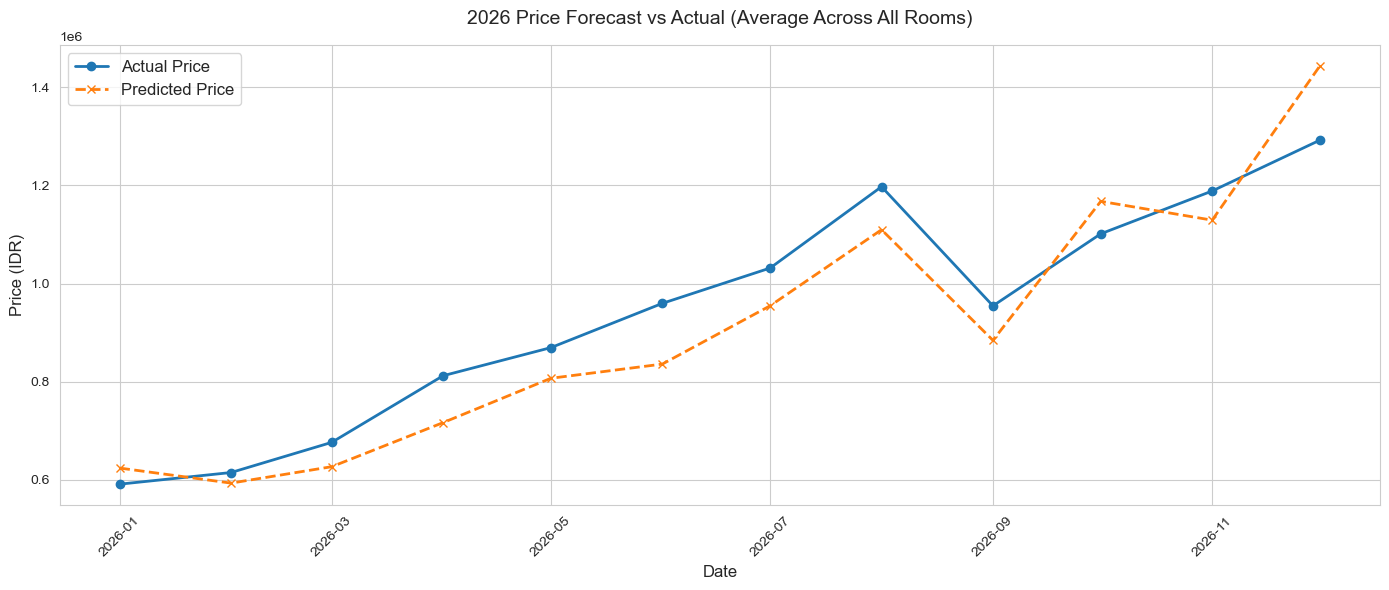


📊 Plotting Specific Trend for Room 354680.0...


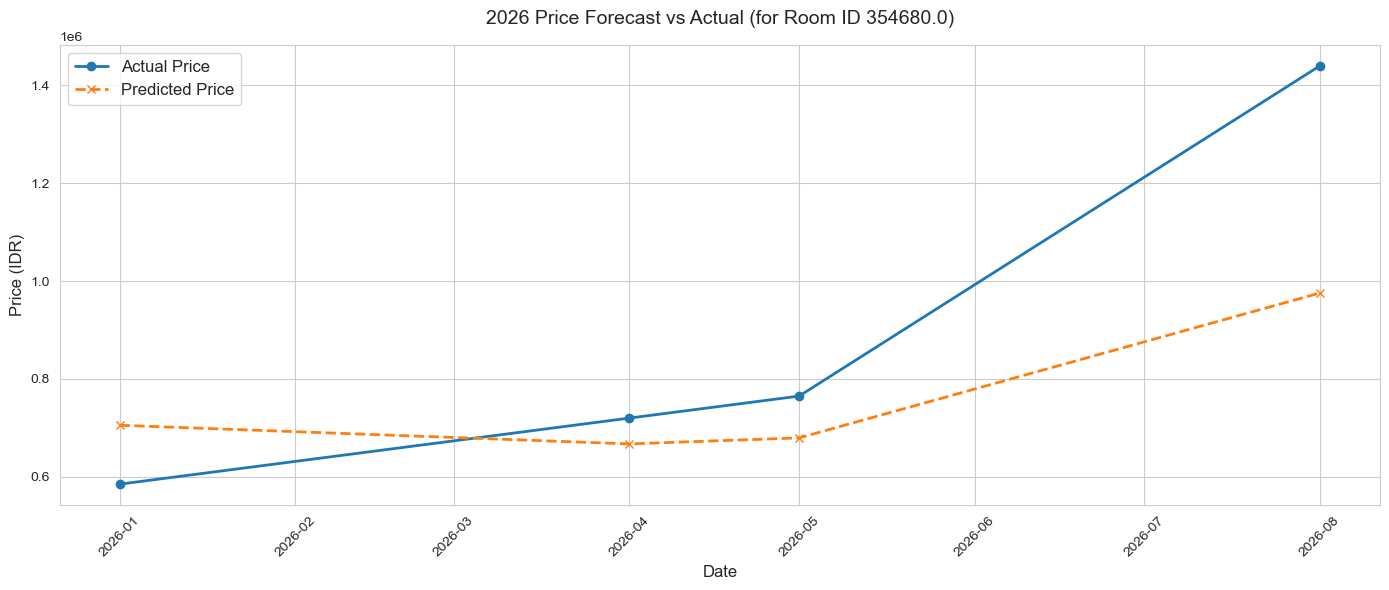

In [156]:
import optuna
import lightgbm as lgb
import numpy as np
import pandas as pd
from sklearn import metrics
from sklearn.model_selection import TimeSeriesSplit
import gc
import matplotlib.pyplot as plt
import seaborn as sns

# ... [KEEP ALL YOUR DATA SPLITTING & SETUP CODE HERE] ...

def train(params):
    # TimeSeries Cross Validation
    tscv = TimeSeriesSplit(n_splits=5)
    splits = list(tscv.split(x_train))
    n_fold = len(splits)
    
    test_diff_preds = np.zeros(test.shape[0])
    mean_score = []
    
    for fold_n, (train_index, valid_index) in enumerate(splits):
        # Use different variable names (X_trn, y_trn) so we don't overwrite global x_train
        X_trn, X_val = x_train[columns].iloc[train_index], x_train[columns].iloc[valid_index]
        y_trn, y_val = y_train.iloc[train_index], y_train.iloc[valid_index] # These are Deltas!

        dtrain = lgb.Dataset(X_trn, label=y_trn, categorical_feature=['roomId', 'propertyId'])
        dvalid = lgb.Dataset(X_val, label=y_val, categorical_feature=['roomId', 'propertyId'], reference=dtrain)
        
        
        clf = lgb.train(
            params,
            dtrain,
            valid_sets=[dtrain, dvalid],
            callbacks=[
                lgb.early_stopping(stopping_rounds=50, verbose=False),
            ]
        )
        
        # Predict the DIFFERENCE for validation
        pred_diff_valid = clf.predict(X_val, num_iteration=clf.best_iteration)
        
        # Actual predicted price = Last month's base price + Predicted Difference
        base_price_valid = train_data['price_lag_1'].iloc[valid_index].values
        final_y_pred_valid = np.expm1(np.log1p(base_price_valid) + pred_diff_valid)
        
        # Real absolute prices for scoring
        real_y_valid = train_data['price'].iloc[valid_index].values
        
        val_score = np.sqrt(metrics.mean_squared_error(real_y_valid, final_y_pred_valid))
        mean_score.append(val_score)
        
        # Accumulate the DIFFERENCE predictions for the final Test set
        test_diff_preds += clf.predict(test[columns], num_iteration=clf.best_iteration) / n_fold
        
        # Optuna Pruning
        score = np.mean(mean_score)
        
        importance = clf.feature_importance(importance_type='gain')
        
        # Cleanup
        del X_trn, X_val, y_trn, y_val, dtrain, dvalid
        gc.collect()

    # Outside the fold loop: Calculate the final predicted absolute prices for the Test Set
    final_test_predictions = np.expm1(np.log1p(baseline_test_prices) + test_diff_preds)
    
    # You can print out the true MAE of the holdout set here if you want to track it
    test_mae = metrics.mean_absolute_error(actual_test_prices, final_test_predictions)
    test_r2 = metrics.r2_score(actual_test_prices, final_test_predictions)
    
    print(f'Final Holdout MAE : Rp {test_mae:,.0f}')
    print(f'Final Holdout R2  : {test_r2:.4f}')

    # Save predictions to the test dataframe so we can plot them!
    results_df = test_data.copy()
    results_df['predicted_price'] = final_test_predictions
    
    feature_names = clf.feature_name()

    feat_imp = pd.DataFrame({
        'feature': feature_names,
        'importance': importance
    }).sort_values(by='importance', ascending=False)

    print(feat_imp)

    return results_df, clf

# ==========================================
# RUN TRAINING & GET RESULTS
# ==========================================
# Assuming `study.best_params` exists from your previous Optuna run
results_df, clf = train(study.best_params) 

# ==========================================
# PLOTTING THE 2026 FORECAST
# ==========================================
def plot_forecast(results_df, room_id=None):
    plt.figure(figsize=(14, 6))
    sns.set_style("whitegrid")
    
    if room_id:
        # Plot for a specific room
        plot_data = results_df[results_df['roomId'] == room_id].sort_values('date')
        title_suffix = f"for Room ID {room_id}"
    else:
        # Average the prices across all rooms per month
        plot_data = results_df.groupby('date')[['price', 'predicted_price']].mean().reset_index()
        title_suffix = "Average Across All Rooms"
        
    plt.plot(plot_data['date'], plot_data['price'], label='Actual Price', marker='o', linewidth=2, color='#1f77b4')
    plt.plot(plot_data['date'], plot_data['predicted_price'], label='Predicted Price', marker='x', linestyle='--', linewidth=2, color='#ff7f0e')
    
    plt.title(f"2026 Price Forecast vs Actual ({title_suffix})", fontsize=14, pad=15)
    plt.xlabel("Date", fontsize=12)
    plt.ylabel("Price (IDR)", fontsize=12)
    plt.legend(fontsize=12)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

# 1. Plot the overall macro trend (Average of all rooms)
print("\n📊 Plotting Average Hotel Trend...")
plot_forecast(results_df)

# 2. Plot a specific room (Replace with a real Room ID from your dataset)
sample_room = results_df['roomId'].unique()[0] 
print(f"\n📊 Plotting Specific Trend for Room {sample_room}...")
plot_forecast(results_df, room_id=sample_room)

In [60]:
import optuna
import lightgbm as lgb
import numpy as np
import pandas as pd
from sklearn import metrics
from sklearn.model_selection import TimeSeriesSplit
import gc

# 1. Pastikan data sudah terurut berdasarkan tanggal
data = data.sort_values('date').reset_index(drop=True)

# 2. SAFE FEATURE ENGINEERING: Calculate expanding mean to prevent target leakage
# This ensures the mean only looks at past data for that property, not future data.
data['price_lag_1'] = data['price_lag_1'].astype(float)
data['property_mean_price'] = data.groupby('propertyId')['price_lag_1'].transform(lambda x: x.expanding().mean())

# Features based on the safe mean
data['price_vs_property_mean'] = data['price_lag_1'] / data['property_mean_price']
data['price_diff_from_property'] = data['price_lag_1'] - data['property_mean_price']

# 3. Split train and test AFTER safe feature engineering
train_data = data[data['date'] < '2026-01-01'].copy()
test_data = data[data['date'] >= '2026-01-01'].copy()

# Drop rows where price_lag_1 is NaN (usually the first month of data)
train_data = train_data.dropna(subset=['price_lag_1']).reset_index(drop=True)
test_data = test_data.dropna(subset=['price_lag_1']).reset_index(drop=True)

# 4. FIX TARGET: Absolute Difference instead of Log Difference
# This stops exponential error multiplication when reconstructing prices
y_train = train_data['price'] - train_data['price_lag_1']

# Separate features
x_train = train_data.drop(columns=['price', 'date', 'month_period'], errors='ignore')

# We still need these for testing
test = test_data.drop(columns=['price', 'date', 'month_period'], errors='ignore')
actual_test_prices = test_data['price'].values
baseline_test_prices = test_data['price_lag_1'].values # Last month's price

# Define columns safely
columns = x_train.select_dtypes(include='number').columns.to_list() + ['roomId', 'propertyId']
columns = list(set(columns).intersection(x_train.columns))

# Ensure categoricals are properly typed for LightGBM
for col in ['roomId', 'propertyId']:
    if col in columns:
        x_train[col] = x_train[col].astype('category')
        test[col] = test[col].astype('category')

# Define an objective function to be minimized
def objective(trial):
    params = {
        "objective": "mae",  # Changed to MAE to directly optimize for your goal
        "metric": "mae",     # Evaluate using MAE
        "boosting_type": "gbdt",
        "verbosity": -1,
        
        "num_boost_round": trial.suggest_int("num_boost_round", 300, 1500),
        "num_leaves": trial.suggest_int("num_leaves", 15, 63), 
        "max_depth": trial.suggest_int("max_depth", 3, 9),     
        "min_data_in_leaf": trial.suggest_int("min_data_in_leaf", 10, 50), 
        
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.05, log=True),
        "min_child_weight": trial.suggest_float("min_child_weight", 1e-3, 0.1, log=True),

        "feature_fraction": trial.suggest_float("feature_fraction", 0.6, 1.0),
        "bagging_fraction": trial.suggest_float("bagging_fraction", 0.6, 1.0),
        "bagging_freq": trial.suggest_int("bagging_freq", 1, 10),

        "reg_alpha": trial.suggest_float("reg_alpha", 1e-3, 10.0, log=True),
        "reg_lambda": trial.suggest_float("reg_lambda", 1e-3, 10.0, log=True),
        "random_state": 222,
    }

    # TimeSeries Cross Validation
    tscv = TimeSeriesSplit(n_splits=5)
    splits = list(tscv.split(x_train))
    n_fold = len(splits)
    
    test_diff_preds = np.zeros(test.shape[0])
    mean_score = []
    
    for fold_n, (train_index, valid_index) in enumerate(splits):
        
        X_trn, X_val = x_train[columns].iloc[train_index], x_train[columns].iloc[valid_index]
        y_trn, y_val = y_train.iloc[train_index], y_train.iloc[valid_index] 

        dtrain = lgb.Dataset(X_trn, label=y_trn)
        dvalid = lgb.Dataset(X_val, label=y_val, reference=dtrain)
        
        clf = lgb.train(
            params,
            dtrain,
            valid_sets=[dtrain, dvalid],
            callbacks=[
                lgb.early_stopping(stopping_rounds=50, verbose=False),
            ]
        )
        
        # Predict the DIFFERENCE for validation
        pred_diff_valid = clf.predict(X_val, num_iteration=clf.best_iteration)
        
        # FIX RECONSTRUCTION: Base price + Predicted Absolute Difference
        base_price_valid = train_data['price_lag_1'].iloc[valid_index].values
        final_y_pred_valid = base_price_valid + pred_diff_valid
        
        # Real absolute prices for scoring
        real_y_valid = train_data['price'].iloc[valid_index].values
        
        # Calculate MAE for this fold
        val_score = metrics.mean_absolute_error(real_y_valid, final_y_pred_valid)
        mean_score.append(val_score)
        
        # Accumulate the DIFFERENCE predictions for the final Test set
        test_diff_preds += clf.predict(test[columns], num_iteration=clf.best_iteration) / n_fold
        
        # Optuna Pruning based on CV score
        score = np.mean(mean_score)
        trial.report(score, fold_n)
        if trial.should_prune():
            raise optuna.TrialPruned()
        
        # Cleanup
        del X_trn, X_val, y_trn, y_val, dtrain, dvalid
        gc.collect()
        
        importance = clf.feature_importance(importance_type='gain')
    feature_names = clf.feature_name()

    feat_imp = pd.DataFrame({
        'feature': feature_names,
        'importance': importance
    }).sort_values(by='importance', ascending=False)

    # print(feat_imp)

    # Calculate final predictions for the Holdout Test Set
    final_test_predictions = baseline_test_prices + test_diff_preds
    
    # Track the Holdout MAE as a user attribute (so you can view it in Optuna plots)
    test_mae = metrics.mean_absolute_error(actual_test_prices, final_test_predictions)
    trial.set_user_attr("Holdout_MAE", test_mae)

    # FIX OPTUNA RETURN: Return the Cross-Validation MAE, NOT the Test MAE
    cv_mae = np.mean(mean_score)
    return cv_mae  

# Run Optimization
study = optuna.create_study(direction="minimize")
study.optimize(objective, n_trials=1000) 

print("Best Params:", study.best_params)
print("Best CV MAE:", study.best_value)

[I 2026-04-03 01:14:19,864] A new study created in memory with name: no-name-93e9668c-c68c-4023-8ac8-56101b857035


[I 2026-04-03 01:14:22,246] Trial 0 finished with value: 112285.51824537183 and parameters: {'num_boost_round': 757, 'num_leaves': 50, 'max_depth': 3, 'min_data_in_leaf': 10, 'learning_rate': 0.022079817879329517, 'min_child_weight': 0.0021189102444753123, 'feature_fraction': 0.9191672179268654, 'bagging_fraction': 0.6574952733738872, 'bagging_freq': 7, 'reg_alpha': 0.0021441778880638474, 'reg_lambda': 0.1413682054240594}. Best is trial 0 with value: 112285.51824537183.
[I 2026-04-03 01:14:26,138] Trial 1 finished with value: 111882.19399660942 and parameters: {'num_boost_round': 1411, 'num_leaves': 24, 'max_depth': 6, 'min_data_in_leaf': 21, 'learning_rate': 0.017878737371818526, 'min_child_weight': 0.07345822835575114, 'feature_fraction': 0.7300239670047595, 'bagging_fraction': 0.8798466844211295, 'bagging_freq': 1, 'reg_alpha': 0.040459621632252744, 'reg_lambda': 0.12871776250698894}. Best is trial 1 with value: 111882.19399660942.
[I 2026-04-03 01:14:29,713] Trial 2 finished with v

KeyboardInterrupt: 

In [ ]:
Best Params: {'num_boost_round': 1338, 'num_leaves': 24, 'max_depth': 7, 'min_data_in_leaf': 20, 'learning_rate': 0.03692162860809076, 'min_child_weight': 0.0029730495727740636, 'feature_fraction': 0.6618999296881551, 'bagging_fraction': 0.7985344896919819, 'bagging_freq': 7, 'reg_alpha': 0.0615559663668795, 'reg_lambda': 0.06198632488623635}
Best CV MAE: 106827.4404586615

In [ ]:
data_old = data
data = data_old


In [30]:
data = data[data['propertyId'] == 163277]

In [33]:
import optuna
import lightgbm as lgb
import numpy as np
import pandas as pd
from sklearn import metrics
from sklearn.model_selection import TimeSeriesSplit
import gc

# 1. Pastikan data sudah terurut berdasarkan tanggal
data = data.sort_values(['roomId', 'date']).reset_index(drop=True)

# ---> Fix the 0 prices by filling them with adjacent months <---
data['price'] = data['price'].replace(0, np.nan)
data['price_lag_1'] = data['price_lag_1'].replace(0, np.nan)

data['price'] = data.groupby('roomId')['price'].transform(lambda x: x.ffill().bfill())
data['price_lag_1'] = data.groupby('roomId')['price_lag_1'].transform(lambda x: x.ffill().bfill())

# 2. SAFE FEATURE ENGINEERING
data['price_lag_1'] = data['price_lag_1'].astype(float)
data['property_mean_price'] = data.groupby('propertyId')['price_lag_1'].transform(lambda x: x.expanding().mean())

data['price_vs_property_mean'] = data['price_lag_1'] / data['property_mean_price']
data['price_diff_from_property'] = data['price_lag_1'] - data['property_mean_price']

# ==========================================
# 3. DIRECT MULTI-STEP TARGET CREATION
# ==========================================
for h in range(1, 13):
    data[f'target_step_{h}'] = data.groupby('roomId')['price'].shift(-(h-1))

studies = {}

# ==========================================
# 4. OPTIMIZATION LOOP FOR 12 MODELS
# ==========================================
def optimize_step(h, n_trials=30):
    print(f"\n{'='*50}")
    print(f"🚀 Optimizing Model for Step {h} (Predicting Month {h})")
    print(f"{'='*50}")

    step_data = data.dropna(subset=['price_lag_1', f'target_step_{h}']).reset_index(drop=True)
    
    train_data = step_data[step_data['date'] < '2025-01-01'].copy()
    test_data = step_data[step_data['date'] >= '2025-01-01'].copy()

    # ---> LOG TRANSFORMATION HERE <---
    # Target is now the log difference (log return) instead of absolute difference
    y_train = np.log1p(train_data[f'target_step_{h}']) - np.log1p(train_data['price_lag_1'])

    target_cols_to_drop = [f'target_step_{i}' for i in range(1, 13)]
    x_train = train_data.drop(columns=['price', 'date', 'month_period'] + target_cols_to_drop, errors='ignore')
    test = test_data.drop(columns=['price', 'date', 'month_period'] + target_cols_to_drop, errors='ignore')

    # Keep track of actuals for MAPE calculation (Raw original scale)
    actual_test_prices = test_data[f'target_step_{h}'].values
    baseline_test_prices = test_data['price_lag_1'].values

    columns = x_train.select_dtypes(include='number').columns.to_list() + ['roomId', 'propertyId']
    columns = list(set(columns).intersection(x_train.columns))

    for col in ['roomId', 'propertyId']:
        if col in columns:
            x_train[col] = x_train[col].astype('category')
            test[col] = test[col].astype('category')

    def objective(trial):
        params = {
            "objective": "mae", 
            "metric": "mae",
            "boosting_type": "gbdt",
            "verbosity": -1,
            
            "num_boost_round": trial.suggest_int("num_boost_round", 300, 1000),
            "num_leaves": trial.suggest_int("num_leaves", 15, 63), 
            "max_depth": trial.suggest_int("max_depth", 3, 9),     
            "min_data_in_leaf": trial.suggest_int("min_data_in_leaf", 10, 50), 
            "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.05, log=True),
            "min_child_weight": trial.suggest_float("min_child_weight", 1e-3, 0.1, log=True),
            "feature_fraction": trial.suggest_float("feature_fraction", 0.6, 1.0),
            "bagging_fraction": trial.suggest_float("bagging_fraction", 0.6, 1.0),
            "bagging_freq": trial.suggest_int("bagging_freq", 1, 10),
            "reg_alpha": trial.suggest_float("reg_alpha", 1e-3, 10.0, log=True),
            "reg_lambda": trial.suggest_float("reg_lambda", 1e-3, 10.0, log=True),
            "random_state": 222,
        }

        tscv = TimeSeriesSplit(n_splits=2)
        splits = list(tscv.split(x_train))
        n_fold = len(splits)
        
        test_diff_preds = np.zeros(test.shape[0]) if len(test) > 0 else []
        mean_mape_score = []
        
        for fold_n, (train_index, valid_index) in enumerate(splits):
            X_trn, X_val = x_train[columns].iloc[train_index], x_train[columns].iloc[valid_index]
            y_trn, y_val = y_train.iloc[train_index], y_train.iloc[valid_index] 
            dtrain = lgb.Dataset(X_trn, label=y_trn)
            dvalid = lgb.Dataset(X_val, label=y_val, reference=dtrain)
            
            clf = lgb.train(
                params,
                dtrain,
                valid_sets=[dtrain, dvalid],
                callbacks=[lgb.early_stopping(stopping_rounds=50, verbose=False)]
            )
            
            # Predict LOG DIFFERENCE
            pred_diff_valid = clf.predict(X_val, num_iteration=clf.best_iteration)
            
            # ---> RECONSTRUCT PRICE UN-LOGGED <---
            base_price_valid = train_data['price_lag_1'].iloc[valid_index].values
            # Reconstruct: exp( log(base_price) + predicted_log_diff ) - 1
            final_y_pred_valid = np.expm1(np.log1p(base_price_valid) + pred_diff_valid)
            
            # GET REAL PRICE (Already un-logged)
            real_y_valid = train_data[f'target_step_{h}'].iloc[valid_index].values
            
            # --- EVALUATE WITH MAPE ---
            val_mape = metrics.mean_absolute_percentage_error(real_y_valid, final_y_pred_valid)
            mean_mape_score.append(val_mape)
            
            if len(test) > 0:
                test_diff_preds += clf.predict(test[columns], num_iteration=clf.best_iteration) / n_fold
            
            trial.report(np.mean(mean_mape_score), fold_n)
            if trial.should_prune():
                raise optuna.TrialPruned()
            
            del X_trn, X_val, y_trn, y_val, dtrain, dvalid
            gc.collect()

        # Calculate final MAPE for Holdout Test Set
        if len(test) > 0:
            # ---> RECONSTRUCT TEST PRICE UN-LOGGED <---
            final_test_predictions = np.expm1(np.log1p(baseline_test_prices) + test_diff_preds)
            test_mape = metrics.mean_absolute_percentage_error(actual_test_prices, final_test_predictions)
            trial.set_user_attr("Holdout_MAPE", test_mape)

        return np.mean(mean_mape_score)  

    study = optuna.create_study(direction="minimize")
    study.optimize(objective, n_trials=n_trials) 
    
    print(f"\n✅ Step {h} Finished | Best CV MAPE: {study.best_value:.4f}")
    return study

# Loop through and train 12 independent models
for step in range(1, 13):
    studies[step] = optimize_step(step, n_trials=3)


🚀 Optimizing Model for Step 1 (Predicting Month 1)

✅ Step 1 Finished | Best CV MAPE: 0.1658

🚀 Optimizing Model for Step 2 (Predicting Month 2)

✅ Step 2 Finished | Best CV MAPE: 0.2162

🚀 Optimizing Model for Step 3 (Predicting Month 3)

✅ Step 3 Finished | Best CV MAPE: 0.2189

🚀 Optimizing Model for Step 4 (Predicting Month 4)

✅ Step 4 Finished | Best CV MAPE: 0.2426

🚀 Optimizing Model for Step 5 (Predicting Month 5)

✅ Step 5 Finished | Best CV MAPE: 0.2469

🚀 Optimizing Model for Step 6 (Predicting Month 6)

✅ Step 6 Finished | Best CV MAPE: 0.2505

🚀 Optimizing Model for Step 7 (Predicting Month 7)

✅ Step 7 Finished | Best CV MAPE: 0.2499

🚀 Optimizing Model for Step 8 (Predicting Month 8)

✅ Step 8 Finished | Best CV MAPE: 0.2655

🚀 Optimizing Model for Step 9 (Predicting Month 9)

✅ Step 9 Finished | Best CV MAPE: 0.2778

🚀 Optimizing Model for Step 10 (Predicting Month 10)

✅ Step 10 Finished | Best CV MAPE: 0.2546

🚀 Optimizing Model for Step 11 (Predicting Month 11)

✅ 

In [10]:
for i in range(1, 13):
    print(f"Bulan ke-{i} Best CV MAPE (Persentase error dari prediksi): {(studies[i].best_value*100):.2f}%, Holdout MAPE: {studies[i].best_trial.user_attrs['Holdout_MAPE']:.4f}")

Bulan ke-1 Best CV MAPE (Persentase error dari prediksi): 14.62%, Holdout MAPE: 0.1797
Bulan ke-2 Best CV MAPE (Persentase error dari prediksi): 18.89%, Holdout MAPE: 0.2035
Bulan ke-3 Best CV MAPE (Persentase error dari prediksi): 20.54%, Holdout MAPE: 0.2548
Bulan ke-4 Best CV MAPE (Persentase error dari prediksi): 22.69%, Holdout MAPE: 0.2879
Bulan ke-5 Best CV MAPE (Persentase error dari prediksi): 23.33%, Holdout MAPE: 0.2781
Bulan ke-6 Best CV MAPE (Persentase error dari prediksi): 24.25%, Holdout MAPE: 0.2287
Bulan ke-7 Best CV MAPE (Persentase error dari prediksi): 24.00%, Holdout MAPE: 0.1667
Bulan ke-8 Best CV MAPE (Persentase error dari prediksi): 24.30%, Holdout MAPE: 0.1226
Bulan ke-9 Best CV MAPE (Persentase error dari prediksi): 24.59%, Holdout MAPE: 0.1248
Bulan ke-10 Best CV MAPE (Persentase error dari prediksi): 23.77%, Holdout MAPE: 0.1246
Bulan ke-11 Best CV MAPE (Persentase error dari prediksi): 21.86%, Holdout MAPE: 0.1564
Bulan ke-12 Best CV MAPE (Persentase erro

In [82]:
for i in range(1, 13):
    print(f"Bulan ke-{i} Best CV MAPE (Persentase error dari prediksi): {(studies[i].best_value*100):.2f}%, Holdout MAPE: {studies[i].best_trial.user_attrs['Holdout_MAPE']:.4f}")

Bulan ke-1 Best CV MAPE (Persentase error dari prediksi): 14.80%, Holdout MAPE: 0.1824
Bulan ke-2 Best CV MAPE (Persentase error dari prediksi): 19.28%, Holdout MAPE: 0.2104
Bulan ke-3 Best CV MAPE (Persentase error dari prediksi): 21.99%, Holdout MAPE: 0.2611
Bulan ke-4 Best CV MAPE (Persentase error dari prediksi): 23.63%, Holdout MAPE: 0.2894
Bulan ke-5 Best CV MAPE (Persentase error dari prediksi): 24.35%, Holdout MAPE: 0.2808
Bulan ke-6 Best CV MAPE (Persentase error dari prediksi): 25.70%, Holdout MAPE: 0.2232
Bulan ke-7 Best CV MAPE (Persentase error dari prediksi): 25.31%, Holdout MAPE: 0.1623
Bulan ke-8 Best CV MAPE (Persentase error dari prediksi): 25.74%, Holdout MAPE: 0.1174
Bulan ke-9 Best CV MAPE (Persentase error dari prediksi): 25.40%, Holdout MAPE: 0.1117
Bulan ke-10 Best CV MAPE (Persentase error dari prediksi): 24.83%, Holdout MAPE: 0.1255
Bulan ke-11 Best CV MAPE (Persentase error dari prediksi): 22.38%, Holdout MAPE: 0.1393
Bulan ke-12 Best CV MAPE (Persentase erro

In [32]:
import lightgbm as lgb
import numpy as np
import pandas as pd
from sklearn import metrics

print("🚀 Training Best Models on Full Train Set & Evaluating on 2026 Holdout...\n")

test_mapes = {}
trained_models = {}

target_cols_to_drop = [f'target_step_{i}' for i in range(1, 13)]

for h in range(1, 13):
    # 1. Isolate the data for this step (exactly like in the Optuna loop)
    step_data = data.dropna(subset=['price_lag_1', f'target_step_{h}']).reset_index(drop=True)
    
    train_data = step_data[step_data['date'] < '2025-01-01'].copy()
    test_data = step_data[step_data['date'] >= '2025-01-01'].copy()
    
    # 2. Setup Targets (Log Return)
    y_train = np.log1p(train_data[f'target_step_{h}']) - np.log1p(train_data['price_lag_1'])
    
    # 3. Setup Features
    x_train = train_data.drop(columns=['price', 'date', 'month_period'] + target_cols_to_drop, errors='ignore')
    x_test = test_data.drop(columns=['price', 'date', 'month_period'] + target_cols_to_drop, errors='ignore')
    
    # 4. Actual Prices for Evaluation
    actual_test_prices = test_data[f'target_step_{h}'].values
    baseline_test_prices = test_data['price_lag_1'].values
    
    # 5. Handle Categorical Columns
    columns = x_train.select_dtypes(include='number').columns.to_list() + ['roomId', 'propertyId']
    columns = list(set(columns).intersection(x_train.columns))
    
    for col in ['roomId', 'propertyId']:
        if col in columns:
            x_train[col] = x_train[col].astype('category')
            x_test[col] = x_test[col].astype('category')

    dtrain = lgb.Dataset(x_train[columns], label=y_train)

    # 6. Retrieve Best Params from the Study
    best_params = studies[h].best_params.copy()
    best_params.update({
        "objective": "mae", 
        "metric": "mae",
        "boosting_type": "gbdt",
        "verbosity": -1,
        "random_state": 222
    })
    
    # Extract num_boost_round since it's passed directly to lgb.train, not in the param dict
    nbr = best_params.pop("num_boost_round")
    
    # 7. Train the Model on 100% of the Training Data
    model = lgb.train(best_params, dtrain, num_boost_round=nbr)
    trained_models[h] = model
    
    # 8. Predict and Evaluate on the Test Data (if available)
    if len(test_data) > 0:
        # Predict Log Difference
        pred_log_diff = model.predict(x_test[columns])
        
        # Reconstruct exactly like we did in the objective function
        final_test_preds = np.expm1(np.log1p(baseline_test_prices) + pred_log_diff)
        
        # Calculate MAPE
        test_mape = metrics.mean_absolute_percentage_error(actual_test_prices, final_test_preds)
        test_mapes[h] = test_mape
        
        print(f"✅ Step {h} (Month {h}) Holdout MAPE: {test_mape:.4f}")
    else:
        print(f"⚠️ Step {h} (Month {h}): No test data available to evaluate.")

# Print summary
print("\n" + "="*40)
print("🎯 FINAL SUMMARY: HOLDOUT MAPE BY MONTH")
print("="*40)
for h, mape in test_mapes.items():
    print(f"Month {h:<2}: {mape:.4f} ({mape*100:.2f}%)")

🚀 Training Best Models on Full Train Set & Evaluating on 2026 Holdout...

✅ Step 1 (Month 1) Holdout MAPE: 0.1047
✅ Step 2 (Month 2) Holdout MAPE: 0.1261
✅ Step 3 (Month 3) Holdout MAPE: 0.2107
✅ Step 4 (Month 4) Holdout MAPE: 0.2677
✅ Step 5 (Month 5) Holdout MAPE: 0.1829
✅ Step 6 (Month 6) Holdout MAPE: 0.1983
✅ Step 7 (Month 7) Holdout MAPE: 0.1568
✅ Step 8 (Month 8) Holdout MAPE: 0.1293
✅ Step 9 (Month 9) Holdout MAPE: 0.1007
✅ Step 10 (Month 10) Holdout MAPE: 0.1045
✅ Step 11 (Month 11) Holdout MAPE: 0.1207
✅ Step 12 (Month 12) Holdout MAPE: 0.1185

🎯 FINAL SUMMARY: HOLDOUT MAPE BY MONTH
Month 1 : 0.1047 (10.47%)
Month 2 : 0.1261 (12.61%)
Month 3 : 0.2107 (21.07%)
Month 4 : 0.2677 (26.77%)
Month 5 : 0.1829 (18.29%)
Month 6 : 0.1983 (19.83%)
Month 7 : 0.1568 (15.68%)
Month 8 : 0.1293 (12.93%)
Month 9 : 0.1007 (10.07%)
Month 10: 0.1045 (10.45%)
Month 11: 0.1207 (12.07%)
Month 12: 0.1185 (11.85%)


In [ ]:
========================================
🎯 FINAL SUMMARY: HOLDOUT MAPE BY MONTH
========================================
Month 1 : 0.1047 (10.47%)
Month 2 : 0.1261 (12.61%)
Month 3 : 0.2107 (21.07%)
Month 4 : 0.2677 (26.77%)
Month 5 : 0.1829 (18.29%)
Month 6 : 0.1983 (19.83%)
Month 7 : 0.1568 (15.68%)
Month 8 : 0.1293 (12.93%)
Month 9 : 0.1007 (10.07%)
Month 10: 0.1045 (10.45%)
Month 11: 0.1207 (12.07%)
Month 12: 0.1185 (11.85%)

In [44]:
data = data[data['propertyId'] == 163277]

advanced_hybrid_fe_direct is ready. Example: step_data = advanced_hybrid_fe_direct(data, h=1)


In [64]:
import optuna
import lightgbm as lgb
import numpy as np
import pandas as pd
from sklearn import metrics
from sklearn.model_selection import TimeSeriesSplit
import gc

# 1. Pastikan data sudah terurut berdasarkan tanggal
data = data.sort_values(['roomId', 'date']).reset_index(drop=True)

# ---> Fix the 0 prices by filling them with adjacent months <---
data['price'] = data['price'].replace(0, np.nan)
data['price_lag_1'] = data['price_lag_1'].replace(0, np.nan)

data['price'] = data.groupby('roomId')['price'].transform(lambda x: x.ffill().bfill())
data['price_lag_1'] = data.groupby('roomId')['price_lag_1'].transform(lambda x: x.ffill().bfill())

# 2. SAFE FEATURE ENGINEERING
data['price_lag_1'] = data['price_lag_1'].astype(float)
data['property_mean_price'] = data.groupby('propertyId')['price_lag_1'].transform(lambda x: x.expanding().mean())

data['price_vs_property_mean'] = data['price_lag_1'] / data['property_mean_price']
data['price_diff_from_property'] = data['price_lag_1'] - data['property_mean_price']

# ==========================================
# 3. DIRECT MULTI-STEP TARGET CREATION
# ==========================================
for h in range(1, 13):
    data[f'target_step_{h}'] = data.groupby('roomId')['price'].shift(-(h-1))

# Now studies will hold [propertyId][step]
studies = {}
unique_properties = data['propertyId'].dropna().unique()

# ==========================================
# 4. OPTIMIZATION LOOP PER PROPERTY, THEN 12 MODELS
# ==========================================
def optimize_property_step(prop_id, prop_data, h, n_trials=30):
    print(f"\n{'='*50}")
    print(f"🚀 Optimizing Model for Property {prop_id} | Step {h} (Month {h})")
    print(f"{'='*50}")

    step_data = prop_data.dropna(subset=['price_lag_1', f'target_step_{h}']).reset_index(drop=True)
    
    if len(step_data) == 0:
        print(f"⚠️ No valid data for Property {prop_id} Step {h}")
        return None

    train_data = step_data[step_data['date'] < '2025-01-01'].copy()
    test_data = step_data[step_data['date'] >= '2025-01-01'].copy()
    
    if len(train_data) == 0:
        return None

    # Target: Log difference
    y_train = np.log1p(train_data[f'target_step_{h}']) - np.log1p(train_data['price_lag_1'])

    target_cols_to_drop = [f'target_step_{i}' for i in range(1, 13)]
    x_train = train_data.drop(columns=['price', 'date', 'month_period'] + target_cols_to_drop, errors='ignore')
    test = test_data.drop(columns=['price', 'date', 'month_period'] + target_cols_to_drop, errors='ignore')

    # Keep track of actual raw prices
    actual_test_prices = test_data[f'target_step_{h}'].values
    baseline_test_prices = test_data['price_lag_1'].values

    columns = x_train.select_dtypes(include='number').columns.to_list() + ['roomId', 'propertyId']
    columns = list(set(columns).intersection(x_train.columns))

    for col in ['roomId', 'propertyId']:
        if col in columns:
            x_train[col] = x_train[col].astype('category')
            test[col] = test[col].astype('category')

    def objective(trial):
        params = {
            "objective": "mae", 
            "metric": "mae",
            "boosting_type": "gbdt",
            "verbosity": -1,
            
            "num_boost_round": trial.suggest_int("num_boost_round", 100, 800),
            "num_leaves": trial.suggest_int("num_leaves", 10, 40), 
            "max_depth": trial.suggest_int("max_depth", 3, 8),     
            "min_data_in_leaf": trial.suggest_int("min_data_in_leaf", 5, 30), 
            "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.1, log=True),
            "feature_fraction": trial.suggest_float("feature_fraction", 0.6, 1.0),
            "bagging_fraction": trial.suggest_float("bagging_fraction", 0.6, 1.0),
            "bagging_freq": trial.suggest_int("bagging_freq", 1, 10),
            "random_state": 222,
        }

        # Check if enough samples for CV
        n_splits = 2 if len(x_train) > 50 else 1
        
        if n_splits >= 2:
            tscv = TimeSeriesSplit(n_splits=n_splits)
            splits = list(tscv.split(x_train))
        else:
            # Fallback to simple split if not enough data
            split_idx = int(len(x_train) * 0.8)
            if split_idx == 0:
                raise optuna.TrialPruned("Not enough data to train")
            splits = [ (np.arange(split_idx), np.arange(split_idx, len(x_train))) ]
            
        n_fold = len(splits)
        
        test_diff_preds = np.zeros(test.shape[0]) if len(test) > 0 else []
        mean_mae_score = []
        
        for fold_n, (train_index, valid_index) in enumerate(splits):
            X_trn, X_val = x_train[columns].iloc[train_index], x_train[columns].iloc[valid_index]
            y_trn, y_val = y_train.iloc[train_index], y_train.iloc[valid_index] 
            
            dtrain = lgb.Dataset(X_trn, label=y_trn)
            dvalid = lgb.Dataset(X_val, label=y_val, reference=dtrain)
            
            clf = lgb.train(
                params,
                dtrain,
                valid_sets=[dtrain, dvalid],
                callbacks=[lgb.early_stopping(stopping_rounds=30, verbose=False)]
            )
            
            # Predict LOG DIFFERENCE
            pred_diff_valid = clf.predict(X_val, num_iteration=clf.best_iteration)
            
            # ---> RECONSTRUCT PRICE UN-LOGGED <---
            base_price_valid = train_data['price_lag_1'].iloc[valid_index].values
            final_y_pred_valid = np.expm1(np.log1p(base_price_valid) + pred_diff_valid)
            
            # GET REAL PRICE (Already un-logged)
            real_y_valid = train_data[f'target_step_{h}'].iloc[valid_index].values
            
            val_mae = metrics.mean_absolute_error(real_y_valid, final_y_pred_valid)
            mean_mae_score.append(val_mae)
            
            if len(test) > 0:
                test_diff_preds += clf.predict(test[columns], num_iteration=clf.best_iteration) / n_fold
            
            trial.report(np.mean(mean_mae_score), fold_n)
            if trial.should_prune():
                raise optuna.TrialPruned()

        # Final MAE for Holdout Test Set
        if len(test) > 0:
            final_test_predictions = np.expm1(np.log1p(baseline_test_prices) + test_diff_preds)
            test_mae = metrics.mean_absolute_error(actual_test_prices, final_test_predictions)
            trial.set_user_attr("Holdout_MAE", test_mae)

        return np.mean(mean_mae_score)  

    study = optuna.create_study(direction="minimize")
    study.optimize(objective, n_trials=n_trials) 
    
    print(f"\n✅ Prop {prop_id} | Step {h} Finished | Best CV MAE: {study.best_value:.4f}")
    return study

# ==========================================
# EXECUTE LOOP OVER PROPERTIES THEN STEPS
# ==========================================
for prop_id in unique_properties:
    print(f"\n\n{'*'*60}")
    print(f"🏢 BUILDING MODELS FOR PROPERTY ID: {prop_id}")
    print(f"{'*'*60}")
    
    studies[prop_id] = {}
    prop_data = data[data['propertyId'] == prop_id].copy()
    
    for step in range(1, 13):
        res = optimize_property_step(prop_id, prop_data, step, n_trials=5)
        if res is not None:
            studies[prop_id][step] = res



************************************************************
🏢 BUILDING MODELS FOR PROPERTY ID: 158986.0
************************************************************

🚀 Optimizing Model for Property 158986.0 | Step 1 (Month 1)

✅ Prop 158986.0 | Step 1 Finished | Best CV MAE: 103751.7890

🚀 Optimizing Model for Property 158986.0 | Step 2 (Month 2)

✅ Prop 158986.0 | Step 2 Finished | Best CV MAE: 138926.5742

🚀 Optimizing Model for Property 158986.0 | Step 3 (Month 3)

✅ Prop 158986.0 | Step 3 Finished | Best CV MAE: 186140.6807

🚀 Optimizing Model for Property 158986.0 | Step 4 (Month 4)

✅ Prop 158986.0 | Step 4 Finished | Best CV MAE: 69459.1427

🚀 Optimizing Model for Property 158986.0 | Step 5 (Month 5)

✅ Prop 158986.0 | Step 5 Finished | Best CV MAE: 76830.1456

🚀 Optimizing Model for Property 158986.0 | Step 6 (Month 6)

✅ Prop 158986.0 | Step 6 Finished | Best CV MAE: 199102.5013

🚀 Optimizing Model for Property 158986.0 | Step 7 (Month 7)

✅ Prop 158986.0 | Step 7 Finished 

In [57]:
import optuna
import lightgbm as lgb
import numpy as np
import pandas as pd
from sklearn import metrics
from sklearn.model_selection import TimeSeriesSplit
import gc

# 1. Pastikan data sudah terurut berdasarkan tanggal
data = data.sort_values(['roomId', 'date']).reset_index(drop=True)

# ---> Fix the 0 prices by filling them with adjacent months <---
data['price'] = data['price'].replace(0, np.nan)
data['price_lag_1'] = data['price_lag_1'].replace(0, np.nan)

data['price'] = data.groupby('roomId')['price'].transform(lambda x: x.ffill().bfill())
data['price_lag_1'] = data.groupby('roomId')['price_lag_1'].transform(lambda x: x.ffill().bfill())

# 2. SAFE FEATURE ENGINEERING
data['price_lag_1'] = data['price_lag_1'].astype(float)
data['property_mean_price'] = data.groupby('propertyId')['price_lag_1'].transform(lambda x: x.expanding().mean())

data['price_vs_property_mean'] = data['price_lag_1'] / data['property_mean_price']
data['price_diff_from_property'] = data['price_lag_1'] - data['property_mean_price']

# ==========================================
# 3. DIRECT MULTI-STEP TARGET CREATION
# ==========================================
for h in range(1, 13):
    data[f'target_step_{h}'] = data.groupby('roomId')['price'].shift(-(h-1))

studies = {}

# ==========================================
# 4. OPTIMIZATION LOOP FOR 12 MODELS
# ==========================================
def optimize_step(h, n_trials=30):
    print(f"\n{'='*50}")
    print(f"🚀 Optimizing Model for Step {h} (Predicting Month {h})")
    print(f"{'='*50}")

    step_data = data.dropna(subset=['price_lag_1', f'target_step_{h}']).reset_index(drop=True)
    
    train_data = step_data[step_data['date'] < '2025-01-01'].copy()
    test_data = step_data[step_data['date'] >= '2025-01-01'].copy()

    # ---> LOG TRANSFORMATION HERE <---
    # Target is now the log difference (log return) instead of absolute difference
    y_train = np.log1p(train_data[f'target_step_{h}']) - np.log1p(train_data['price_lag_1'])

    target_cols_to_drop = [f'target_step_{i}' for i in range(1, 13)]
    x_train = train_data.drop(columns=['price', 'date', 'month_period'] + target_cols_to_drop, errors='ignore')
    test = test_data.drop(columns=['price', 'date', 'month_period'] + target_cols_to_drop, errors='ignore')

    # Keep track of actuals for MAE calculation (Raw original scale)
    actual_test_prices = test_data[f'target_step_{h}'].values
    baseline_test_prices = test_data['price_lag_1'].values

    columns = x_train.select_dtypes(include='number').columns.to_list() + ['roomId', 'propertyId']
    columns = list(set(columns).intersection(x_train.columns))

    for col in ['roomId', 'propertyId']:
        if col in columns:
            x_train[col] = x_train[col].astype('category')
            test[col] = test[col].astype('category')

    def objective(trial):
        params = {
            "objective": "mae", 
            "metric": "mae",
            "boosting_type": "gbdt",
            "verbosity": -1,
            
            "num_boost_round": trial.suggest_int("num_boost_round", 300, 1000),
            "num_leaves": trial.suggest_int("num_leaves", 15, 63), 
            "max_depth": trial.suggest_int("max_depth", 3, 9),     
            "min_data_in_leaf": trial.suggest_int("min_data_in_leaf", 10, 50), 
            "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.05, log=True),
            "min_child_weight": trial.suggest_float("min_child_weight", 1e-3, 0.1, log=True),
            "feature_fraction": trial.suggest_float("feature_fraction", 0.6, 1.0),
            "bagging_fraction": trial.suggest_float("bagging_fraction", 0.6, 1.0),
            "bagging_freq": trial.suggest_int("bagging_freq", 1, 10),
            "reg_alpha": trial.suggest_float("reg_alpha", 1e-3, 10.0, log=True),
            "reg_lambda": trial.suggest_float("reg_lambda", 1e-3, 10.0, log=True),
            "random_state": 222,
        }

        tscv = TimeSeriesSplit(n_splits=2)
        splits = list(tscv.split(x_train))
        n_fold = len(splits)
        
        test_diff_preds = np.zeros(test.shape[0]) if len(test) > 0 else []
        mean_mae_score = []
        
        for fold_n, (train_index, valid_index) in enumerate(splits):
            X_trn, X_val = x_train[columns].iloc[train_index], x_train[columns].iloc[valid_index]
            y_trn, y_val = y_train.iloc[train_index], y_train.iloc[valid_index] 
            dtrain = lgb.Dataset(X_trn, label=y_trn)
            dvalid = lgb.Dataset(X_val, label=y_val, reference=dtrain)
            
            clf = lgb.train(
                params,
                dtrain,
                valid_sets=[dtrain, dvalid],
                callbacks=[lgb.early_stopping(stopping_rounds=50, verbose=False)]
            )
            
            # Predict LOG DIFFERENCE
            pred_diff_valid = clf.predict(X_val, num_iteration=clf.best_iteration)
            
            # ---> RECONSTRUCT PRICE UN-LOGGED <---
            base_price_valid = train_data['price_lag_1'].iloc[valid_index].values
            # Reconstruct: exp( log(base_price) + predicted_log_diff ) - 1
            final_y_pred_valid = np.expm1(np.log1p(base_price_valid) + pred_diff_valid)
            
            # GET REAL PRICE (Already un-logged)
            real_y_valid = train_data[f'target_step_{h}'].iloc[valid_index].values
            
            # --- EVALUATE WITH MAE ---
            val_mae = metrics.mean_absolute_error(real_y_valid, final_y_pred_valid)
            mean_mae_score.append(val_mae)
            
            if len(test) > 0:
                test_diff_preds += clf.predict(test[columns], num_iteration=clf.best_iteration) / n_fold
            
            trial.report(np.mean(mean_mae_score), fold_n)
            if trial.should_prune():
                raise optuna.TrialPruned()
            
            del X_trn, X_val, y_trn, y_val, dtrain, dvalid
            gc.collect()

        # Calculate final MAE for Holdout Test Set fold_n
        if len(test) > 0:
            # ---> RECONSTRUCT TEST PRICE UN-LOGGED <---
            final_test_predictions = np.expm1(np.log1p(baseline_test_prices) + test_diff_preds)
            test_mae = metrics.mean_absolute_error(actual_test_prices, final_test_predictions)
            trial.set_user_attr("Holdout_MAE", test_mae)

        return np.mean(mean_mae_score)  

    study = optuna.create_study(direction="minimize")
    study.optimize(objective, n_trials=n_trials) 
    
    print(f"\n✅ Step {h} Finished | Best CV MAE: {study.best_value:.4f}")
    return study

# Loop through and train 12 independent models
for step in range(1, 13):
    studies[step] = optimize_step(step, n_trials=10)


🚀 Optimizing Model for Step 1 (Predicting Month 1)

✅ Step 1 Finished | Best CV MAE: 82664.3046

🚀 Optimizing Model for Step 2 (Predicting Month 2)

✅ Step 2 Finished | Best CV MAE: 106815.6558

🚀 Optimizing Model for Step 3 (Predicting Month 3)

✅ Step 3 Finished | Best CV MAE: 102904.7368

🚀 Optimizing Model for Step 4 (Predicting Month 4)

✅ Step 4 Finished | Best CV MAE: 105627.1106

🚀 Optimizing Model for Step 5 (Predicting Month 5)

✅ Step 5 Finished | Best CV MAE: 112475.4010

🚀 Optimizing Model for Step 6 (Predicting Month 6)

✅ Step 6 Finished | Best CV MAE: 113430.9253

🚀 Optimizing Model for Step 7 (Predicting Month 7)

✅ Step 7 Finished | Best CV MAE: 118800.6128

🚀 Optimizing Model for Step 8 (Predicting Month 8)

✅ Step 8 Finished | Best CV MAE: 125842.2057

🚀 Optimizing Model for Step 9 (Predicting Month 9)

✅ Step 9 Finished | Best CV MAE: 127779.3477

🚀 Optimizing Model for Step 10 (Predicting Month 10)

✅ Step 10 Finished | Best CV MAE: 124458.1184

🚀 Optimizing Mode

In [58]:
for i in range(1, 13):
    print(f"Bulan ke-{i} Best CV MAE (Persentase error dari prediksi): {(studies[i].best_value*100):.2f}%, Holdout MAE: {studies[i].best_trial.user_attrs['Holdout_MAE']:.4f}")

Bulan ke-1 Best CV MAE (Persentase error dari prediksi): 8266430.46%, Holdout MAE: 122073.0954
Bulan ke-2 Best CV MAE (Persentase error dari prediksi): 10681565.58%, Holdout MAE: 160763.4608
Bulan ke-3 Best CV MAE (Persentase error dari prediksi): 10290473.68%, Holdout MAE: 171963.2389
Bulan ke-4 Best CV MAE (Persentase error dari prediksi): 10562711.06%, Holdout MAE: 183161.6905
Bulan ke-5 Best CV MAE (Persentase error dari prediksi): 11247540.10%, Holdout MAE: 185379.9854
Bulan ke-6 Best CV MAE (Persentase error dari prediksi): 11343092.53%, Holdout MAE: 198668.3142
Bulan ke-7 Best CV MAE (Persentase error dari prediksi): 11880061.28%, Holdout MAE: 186759.2334
Bulan ke-8 Best CV MAE (Persentase error dari prediksi): 12584220.57%, Holdout MAE: 176608.5649
Bulan ke-9 Best CV MAE (Persentase error dari prediksi): 12777934.77%, Holdout MAE: 164430.3997
Bulan ke-10 Best CV MAE (Persentase error dari prediksi): 12445811.84%, Holdout MAE: 151175.1714
Bulan ke-11 Best CV MAE (Persentase erro

In [59]:
import lightgbm as lgb
import numpy as np
import pandas as pd
from sklearn import metrics

print("🚀 Training Best Models on Full Train Set & Evaluating on 2026 Holdout...\n")

test_maes = {}
trained_models = {}

target_cols_to_drop = [f'target_step_{i}' for i in range(1, 13)]

for h in range(1, 13):
    # 1. Isolate the data for this step (exactly like in the Optuna loop)
    step_data = data.dropna(subset=['price_lag_1', f'target_step_{h}']).reset_index(drop=True)
    
    train_data = step_data[step_data['date'] < '2025-01-01'].copy()
    test_data = step_data[step_data['date'] >= '2025-01-01'].copy()
    
    # 2. Setup Targets (Absolute Difference instead of Log Return)
    y_train = train_data[f'target_step_{h}'] - train_data['price_lag_1']
    
    # 3. Setup Features
    x_train = train_data.drop(columns=['price', 'date', 'month_period'] + target_cols_to_drop, errors='ignore')
    x_test = test_data.drop(columns=['price', 'date', 'month_period'] + target_cols_to_drop, errors='ignore')
    
    # 4. Actual Prices for Evaluation
    actual_test_prices = test_data[f'target_step_{h}'].values
    baseline_test_prices = test_data['price_lag_1'].values
    
    # 5. Handle Categorical Columns
    columns = x_train.select_dtypes(include='number').columns.to_list() + ['roomId', 'propertyId']
    columns = list(set(columns).intersection(x_train.columns))
    
    for col in ['roomId', 'propertyId']:
        if col in columns:
            x_train[col] = x_train[col].astype('category')
            x_test[col] = x_test[col].astype('category')

    dtrain = lgb.Dataset(x_train[columns], label=y_train)

    # 6. Retrieve Best Params from the Study
    best_params = studies[h].best_params.copy()
    best_params.update({
        "objective": "mae", 
        "metric": "mae",
        "boosting_type": "gbdt",
        "verbosity": -1,
        "random_state": 222
    })
    
    # Extract num_boost_round since it's passed directly to lgb.train, not in the param dict
    nbr = best_params.pop("num_boost_round")
    
    # 7. Train the Model on 100% of the Training Data
    model = lgb.train(best_params, dtrain, num_boost_round=nbr)
    trained_models[h] = model
    
    # 8. Predict and Evaluate on the Test Data (if available)
    if len(test_data) > 0:
        # Predict Absolute Difference
        pred_diff = model.predict(x_test[columns])
        
        # Reconstruct: Base price + Predicted Difference
        final_test_preds = baseline_test_prices + pred_diff
        
        # Calculate MAE
        test_mae = metrics.mean_absolute_error(actual_test_prices, final_test_preds)
        test_maes[h] = test_mae
        
        print(f"✅ Step {h} (Month {h}) Holdout MAE: {test_mae:,.0f}")
    else:
        print(f"⚠️ Step {h} (Month {h}): No test data available to evaluate.")

# Print summary
print("\n" + "="*40)
print("🎯 FINAL SUMMARY: HOLDOUT MAE BY MONTH")
print("="*40)
for h, mae in test_maes.items():
    print(f"Month {h:<2}: {mae:,.0f}")

🚀 Training Best Models on Full Train Set & Evaluating on 2026 Holdout...

✅ Step 1 (Month 1) Holdout MAE: 111,974 (Trained for 965 rounds)
✅ Step 2 (Month 2) Holdout MAE: 146,114 (Trained for 375 rounds)
✅ Step 3 (Month 3) Holdout MAE: 168,305 (Trained for 528 rounds)
✅ Step 4 (Month 4) Holdout MAE: 182,446 (Trained for 491 rounds)
✅ Step 5 (Month 5) Holdout MAE: 179,946 (Trained for 584 rounds)
✅ Step 6 (Month 6) Holdout MAE: 199,551 (Trained for 330 rounds)
✅ Step 7 (Month 7) Holdout MAE: 184,564 (Trained for 617 rounds)
✅ Step 8 (Month 8) Holdout MAE: 166,633 (Trained for 383 rounds)
✅ Step 9 (Month 9) Holdout MAE: 157,091 (Trained for 392 rounds)
✅ Step 10 (Month 10) Holdout MAE: 150,477 (Trained for 549 rounds)
✅ Step 11 (Month 11) Holdout MAE: 155,616 (Trained for 412 rounds)
✅ Step 12 (Month 12) Holdout MAE: 160,914 (Trained for 133 rounds)

🎯 FINAL SUMMARY: HOLDOUT MAE BY MONTH
Month 1 : 111,974
Month 2 : 146,114
Month 3 : 168,305
Month 4 : 182,446
Month 5 : 179,946
Month 6 : 1

In [65]:
import pandas as pd
import numpy as np
from sklearn import metrics

print("📊 Calculating MAE, MAPE, and Mean Price by Property ID and Room ID for the Holdout Test Set...\n")

eval_records = []
target_cols_to_drop = [f'target_step_{i}' for i in range(1, 13)]

# Gather predictions across all 12 steps
for h in range(1, 13):
    step_data = data.dropna(subset=['price_lag_1', f'target_step_{h}']).reset_index(drop=True)
    test_data = step_data[step_data['date'] >= '2025-01-01'].copy()
    
    if len(test_data) == 0:
        continue
        
    x_test = test_data.drop(columns=['price', 'date', 'month_period'] + target_cols_to_drop, errors='ignore')
    
    # Handle Categorical Columns identically
    columns = x_test.select_dtypes(include='number').columns.to_list() + ['roomId', 'propertyId']
    columns = list(set(columns).intersection(x_test.columns))
    for col in ['roomId', 'propertyId']:
        if col in columns:
            x_test[col] = x_test[col].astype('category')
            
    model = trained_models[h]
    
    # Predict Absolute Difference
    pred_diff = model.predict(x_test[columns])
    
    # Reconstruct: Base price + Predicted Difference
    baseline_test_prices = test_data['price_lag_1'].values
    final_test_preds = baseline_test_prices + pred_diff
    
    # Save predictions vs actuals alongside IDs
    temp_df = test_data[['roomId', 'propertyId']].copy()
    temp_df['step'] = h
    temp_df['actual'] = test_data[f'target_step_{h}'].values
    temp_df['predicted'] = final_test_preds
    
    eval_records.append(temp_df)

# Combine all steps into a single dataframe
eval_df = pd.concat(eval_records, ignore_index=True)

def calculate_metrics(group):
    actuals = group['actual']
    preds = group['predicted']
    
    mae = metrics.mean_absolute_error(actuals, preds)
    # Use a small number to prevent zero-division error in MAPE calculation
    actuals_safe = np.where(actuals == 0, 1e-5, actuals)
    mape = metrics.mean_absolute_percentage_error(actuals_safe, preds) * 100
    y_mean = actuals.mean()
    
    return pd.Series({
        'MAE': mae,
        'MAPE (%)': mape,
        'Actual_Mean': y_mean
    })

# Compute metrics grouped by Property ID
print("="*60)
print("🏨 METRICS BY PROPERTY ID")
print("="*60)
prop_metrics = eval_df.groupby('propertyId', observed=True).apply(calculate_metrics).reset_index()
# Formatting output strictly for readability
prop_metrics['MAE'] = prop_metrics['MAE'].apply(lambda x: f"{x:,.0f}")
prop_metrics['MAPE (%)'] = prop_metrics['MAPE (%)'].apply(lambda x: f"{x:.2f}%")
prop_metrics['Actual_Mean'] = prop_metrics['Actual_Mean'].apply(lambda x: f"{x:,.0f}")
display(prop_metrics)


# Compute metrics grouped by Room ID
print("\n" + "="*60)
print("🚪 METRICS BY ROOM ID")
print("="*60)
room_metrics = eval_df.groupby('roomId', observed=True).apply(calculate_metrics).reset_index()
room_metrics['MAE'] = room_metrics['MAE'].apply(lambda x: f"{x:,.0f}")
room_metrics['MAPE (%)'] = room_metrics['MAPE (%)'].apply(lambda x: f"{x:.2f}%")
room_metrics['Actual_Mean'] = room_metrics['Actual_Mean'].apply(lambda x: f"{x:,.0f}")
display(room_metrics)
        # metrics)

advanced_hybrid_fe_direct is ready. Example: step_data = advanced_hybrid_fe_direct(data, h=1)


In [20]:
import optuna
import lightgbm as lgb
import numpy as np
import pandas as pd
from sklearn import metrics
from sklearn.model_selection import TimeSeriesSplit
import gc
import warnings

warnings.filterwarnings('ignore')
optuna.logging.set_verbosity(optuna.logging.WARNING) 

# ==========================================
# 1. SETUP & PREPROCESSING
# ==========================================
print("🔄 Preprocessing and Scaling Data...")
data = data.sort_values(['roomId', 'date']).reset_index(drop=True)

data['price'] = data['price'].replace(0, np.nan)
data['price_lag_1'] = data['price_lag_1'].replace(0, np.nan)

data['price'] = data.groupby('roomId')['price'].transform(lambda x: x.ffill().bfill())
data['price_lag_1'] = data.groupby('roomId')['price_lag_1'].transform(lambda x: x.ffill().bfill())
data['price_lag_1'] = data['price_lag_1'].astype(float)

# ==========================================
# 2. ROOM-LEVEL Z-SCORE SCALING
# ==========================================
train_mask = data['date'] < '2025-01-01'

# 1. FOOLPROOF AGGREGATION: Directly name the columns during the agg function by ROOM ID
room_stats = data[train_mask].groupby('roomId')['price'].agg(
    room_mean='mean',
    room_std='std'
).reset_index()

# 2. If std is 0 (prices never changed) or NaN, replace with 1 to avoid division by zero
room_stats['room_std'] = room_stats['room_std'].fillna(1).replace(0, 1)

# 3. SAFETY NET: Drop the columns if they already exist from running the cell previously
data = data.drop(columns=['room_mean', 'room_std'], errors='ignore')

# 4. Merge back into the main dataset based on roomId
data = data.merge(room_stats, on='roomId', how='left')

# 5. Fallback for any weird rooms only present in the test set
global_mean = data[train_mask]['price'].mean()
global_std = data[train_mask]['price'].std()

data['room_mean'] = data['room_mean'].fillna(global_mean)
data['room_std'] = data['room_std'].fillna(global_std)

# 6. Apply Scaling using room-level stats
data['price_scaled'] = (data['price'] - data['room_mean']) / data['room_std']
data['price_lag_1_scaled'] = (data['price_lag_1'] - data['room_mean']) / data['room_std']

# 7. Safe Feature Engineering on SCALED data
data['property_mean_price_scaled'] = data.groupby('propertyId')['price_lag_1_scaled'].transform(lambda x: x.expanding().mean())
data['price_diff_from_property_scaled'] = data['price_lag_1_scaled'] - data['property_mean_price_scaled']

# ==========================================
# 3. DIRECT MULTI-STEP TARGET CREATION
# ==========================================
for h in range(1, 13):
    # Keep Raw target for final MAPE Evaluation
    data[f'target_step_{h}_raw'] = data.groupby('roomId')['price'].shift(-(h-1))
    # Keep Scaled target for LightGBM Training
    data[f'target_step_{h}_scaled'] = data.groupby('roomId')['price_scaled'].shift(-(h-1))

studies = {}

# ==========================================
# 4. OPTIMIZATION LOOP FOR 12 MODELS
# ==========================================
def optimize_step(h, n_trials=30):
    print(f"\n{'='*60}")
    print(f"🚀 Optimizing Model for Step {h} (Predicting Month {h})")
    print(f"{'='*60}")

    step_data = data.dropna(subset=['price_lag_1_scaled', f'target_step_{h}_scaled']).reset_index(drop=True)
    
    train_data = step_data[step_data['date'] < '2025-01-01'].copy()
    test_data = step_data[step_data['date'] >= '2025-01-01'].copy()

    # Model predicts the difference in the SCALED prices
    y_train = train_data[f'target_step_{h}_scaled'] - train_data['price_lag_1_scaled']

    # Drop all target columns and raw price columns so model is forced to use scaled metrics
    target_cols = [f'target_step_{i}_raw' for i in range(1, 13)] + [f'target_step_{i}_scaled' for i in range(1, 13)]
    drop_cols = ['price', 'price_lag_1', 'date', 'month_period'] + target_cols
    
    x_train = train_data.drop(columns=drop_cols, errors='ignore')
    test = test_data.drop(columns=drop_cols, errors='ignore')

    # Keep track of unscaled actuals and room stats for evaluation
    actual_test_prices_raw = test_data[f'target_step_{h}_raw'].values
    baseline_test_prices_scaled = test_data['price_lag_1_scaled'].values
    
    test_room_means = test_data['room_mean'].values
    test_room_stds = test_data['room_std'].values

    columns = x_train.select_dtypes(include='number').columns.to_list() + ['roomId', 'propertyId']
    columns = list(set(columns).intersection(x_train.columns))

    for col in ['roomId', 'propertyId']:
        if col in columns:
            x_train[col] = x_train[col].astype('category')
            test[col] = test[col].astype('category')

    def objective(trial):
        params = {
            "objective": "mae", 
            "metric": "mae",
            "boosting_type": "gbdt",
            "verbosity": -1,
            "num_boost_round": trial.suggest_int("num_boost_round", 300, 1000),
            "num_leaves": trial.suggest_int("num_leaves", 15, 63), 
            "max_depth": trial.suggest_int("max_depth", 3, 9),     
            "min_data_in_leaf": trial.suggest_int("min_data_in_leaf", 10, 50), 
            "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.05, log=True),
            "min_child_weight": trial.suggest_float("min_child_weight", 1e-3, 0.1, log=True),
            "feature_fraction": trial.suggest_float("feature_fraction", 0.6, 1.0),
            "bagging_fraction": trial.suggest_float("bagging_fraction", 0.6, 1.0),
            "bagging_freq": trial.suggest_int("bagging_freq", 1, 10),
            "reg_alpha": trial.suggest_float("reg_alpha", 1e-3, 10.0, log=True),
            "reg_lambda": trial.suggest_float("reg_lambda", 1e-3, 10.0, log=True),
            "random_state": 222,
        }

        tscv = TimeSeriesSplit(n_splits=2)
        splits = list(tscv.split(x_train))
        n_fold = len(splits)
        
        test_diff_preds = np.zeros(test.shape[0]) if len(test) > 0 else []
        mean_mape_score = []
        
        for fold_n, (train_index, valid_index) in enumerate(splits):
            X_trn, X_val = x_train[columns].iloc[train_index], x_train[columns].iloc[valid_index]
            y_trn, y_val = y_train.iloc[train_index], y_train.iloc[valid_index] 
            dtrain = lgb.Dataset(X_trn, label=y_trn)
            dvalid = lgb.Dataset(X_val, label=y_val, reference=dtrain)
            
            clf = lgb.train(params, dtrain, valid_sets=[dtrain, dvalid], callbacks=[lgb.early_stopping(stopping_rounds=50, verbose=False)])
            
            # 1. Predict SCALED DIFFERENCE
            pred_diff_scaled_valid = clf.predict(X_val, num_iteration=clf.best_iteration)
            
            # 2. RECONSTRUCT SCALED PRICE
            base_price_scaled_valid = train_data['price_lag_1_scaled'].iloc[valid_index].values
            final_y_pred_scaled = base_price_scaled_valid + pred_diff_scaled_valid
            
            # 3. UNSCALE BACK TO REAL MONEY USING ROOM STATS
            room_mean_valid = train_data['room_mean'].iloc[valid_index].values
            room_std_valid = train_data['room_std'].iloc[valid_index].values
            
            # Reverse Z-Score: (Scaled * Std) + Mean
            final_y_pred_unscaled = (final_y_pred_scaled * room_std_valid) + room_mean_valid
            
            # 4. EVALUATE WITH RAW ACTUAL PRICES
            real_y_valid = train_data[f'target_step_{h}_raw'].iloc[valid_index].values
            val_mape = metrics.mean_absolute_percentage_error(real_y_valid, final_y_pred_unscaled)
            mean_mape_score.append(val_mape)
            
            if len(test) > 0:
                test_diff_preds += clf.predict(test[columns], num_iteration=clf.best_iteration) / n_fold
            
            trial.report(np.mean(mean_mape_score), fold_n)
            if trial.should_prune():
                raise optuna.TrialPruned()
            
            del X_trn, X_val, y_trn, y_val, dtrain, dvalid
            gc.collect()

        # Calculate final MAPE for Holdout Test Set
        if len(test) > 0:
            final_test_pred_scaled = baseline_test_prices_scaled + test_diff_preds
            # UNSCALE TEST PREDICTIONS USING ROOM STATS
            final_test_pred_unscaled = (final_test_pred_scaled * test_room_stds) + test_room_means
            test_mape = metrics.mean_absolute_percentage_error(actual_test_prices_raw, final_test_pred_unscaled)
            trial.set_user_attr("Holdout_MAPE", test_mape)

        return np.mean(mean_mape_score)  

    study = optuna.create_study(direction="minimize")
    study.optimize(objective, n_trials=n_trials) 
    
    print(f"✅ Step {h} Finished | Best CV MAPE: {study.best_value*100:.2f}%")
    return study

# Let it actually tune using 30 trials per step!
for step in range(1, 13):
    studies[step] = optimize_step(step, n_trials=3)

🔄 Preprocessing and Scaling Data...

🚀 Optimizing Model for Step 1 (Predicting Month 1)
✅ Step 1 Finished | Best CV MAPE: 8.26%

🚀 Optimizing Model for Step 2 (Predicting Month 2)
✅ Step 2 Finished | Best CV MAPE: 17.62%

🚀 Optimizing Model for Step 3 (Predicting Month 3)
✅ Step 3 Finished | Best CV MAPE: 17.50%

🚀 Optimizing Model for Step 4 (Predicting Month 4)
✅ Step 4 Finished | Best CV MAPE: 17.79%

🚀 Optimizing Model for Step 5 (Predicting Month 5)
✅ Step 5 Finished | Best CV MAPE: 19.41%

🚀 Optimizing Model for Step 6 (Predicting Month 6)
✅ Step 6 Finished | Best CV MAPE: 19.71%

🚀 Optimizing Model for Step 7 (Predicting Month 7)
✅ Step 7 Finished | Best CV MAPE: 19.13%

🚀 Optimizing Model for Step 8 (Predicting Month 8)
✅ Step 8 Finished | Best CV MAPE: 22.29%

🚀 Optimizing Model for Step 9 (Predicting Month 9)
✅ Step 9 Finished | Best CV MAPE: 21.90%

🚀 Optimizing Model for Step 10 (Predicting Month 10)
✅ Step 10 Finished | Best CV MAPE: 20.47%

🚀 Optimizing Model for Step 11 

In [89]:
import pandas as pd
from sklearn import metrics
from sklearn.linear_model import Ridge
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
import lightgbm as lgb

# ==========================================
# 1. INITIAL DATA PREP
# ==========================================
# Ensure data is sorted to prevent leakage
data = data.sort_values(['roomId', 'month_period']).reset_index(drop=True)

# Fix 0 prices by filling them with adjacent months
data['price'] = data['price'].replace(0, np.nan)
data['price'] = data.groupby('roomId')['price'].transform(lambda x: x.ffill().bfill())

# Lists to track the Holdout performance
overall_holdout_mape = []
overall_holdout_mae = []

# ==========================================
# 2. 12-MONTH ENSEMBLE LOOP (Ridge + LGBM)
# ==========================================
for h in range(1, 13):
    print(f"\n{'='*70}")
    print(f"🚀 Training Ensemble (Ridge + LGBM) for Horizon {h} (Month {h})")
    print(f"{'='*70}")

    # Generate features
    step_data = advanced_hybrid_fe_direct(data, h=h)
    step_data = step_data.dropna(subset=[f'price_lag_{h}', 'price']).reset_index(drop=True)
    
    # Train / Test Split
    train_data = step_data[step_data['date'] < '2025-01-01'].copy()
    test_data = step_data[step_data['date'] >= '2025-01-01'].copy()

    # Target: Log difference
    y_train = np.log1p(train_data['price']) - np.log1p(train_data[f'price_lag_{h}'])

    # Columns to drop for features
    cols_to_drop = ['price', 'log_price', 'target_diff', 'date', 'month_period', f'log_price_lag_{h}', 'id']
    
    x_train_full = train_data.drop(columns=[c for c in cols_to_drop if c in train_data.columns])
    x_test_full = test_data.drop(columns=[c for c in cols_to_drop if c in test_data.columns])

    # --- Prepare Data for LightGBM (Includes Categoricals) ---
    cat_cols = ['roomId', 'propertyId']
    for col in cat_cols:
        if col in x_train_full.columns:
            x_train_full[col] = x_train_full[col].astype('category')
            x_test_full[col] = x_test_full[col].astype('category')
    # ---> ADD THIS FIX: Filter out rogue strings/objects for LightGBM <---
    good_lgbm_dtypes = ['number', 'category', 'bool']
    x_train_full = x_train_full.select_dtypes(include=good_lgbm_dtypes)
    x_test_full = x_test_full.select_dtypes(include=good_lgbm_dtypes)
    # --- Prepare Data for Ridge (Strictly Numeric) ---
    x_train_ridge = x_train_full.select_dtypes(include=['number', 'bool'])
    x_test_ridge = x_test_full.select_dtypes(include=['number', 'bool'])

    actual_test_prices = test_data['price'].values
    baseline_test_prices = test_data[f'price_lag_{h}'].values
    baseline_train_prices = train_data[f'price_lag_{h}'].values

    # ==========================================
    # 3. BUILD & TRAIN MODELS
    # ==========================================
    # Model 1: Ridge Pipeline
    ridge_pipeline = make_pipeline(
        SimpleImputer(strategy='mean'), 
        StandardScaler(), 
        Ridge(alpha=1.0)
    )
    ridge_pipeline.fit(x_train_ridge, y_train)

    # Model 2: LightGBM
    # Using Huber loss for robustness against outliers
    lgbm_model = lgb.LGBMRegressor(
        objective='huber',
        n_estimators=400,
        learning_rate=0.03,
        max_depth=6,
        num_leaves=31,
        random_state=222,
        verbose=-1
    )
    lgbm_model.fit(x_train_full, y_train)
    # Get feature importance
    importances = lgbm_model.feature_importances_
    feature_names = x_train_full.columns

    feat_imp = pd.DataFrame({
        'feature': feature_names,
        'importance': importances
    }).sort_values(by='importance', ascending=False)

    # print("\n🔍 Top 15 Feature Importances (LGBM):")
    # print(feat_imp.head(15))

    # ==========================================
    # 4. PREDICT & ENSEMBLE
    # ==========================================
    # --- Train Set Predictions ---
    pred_train_ridge = ridge_pipeline.predict(x_train_ridge)
    pred_train_lgbm = lgbm_model.predict(x_train_full)
    
    # Combine predictions (Simple 50/50 Average)
    pred_diff_train_ens = (pred_train_ridge + pred_train_lgbm) / 2
    final_train_predictions = np.expm1(np.log1p(baseline_train_prices) + pred_diff_train_ens)
    
    train_mape = metrics.mean_absolute_percentage_error(train_data['price'], final_train_predictions)
    train_mae = metrics.mean_absolute_error(train_data['price'], final_train_predictions)

    print(f"✅ Step {h} Trained!")
    print(f"   - Ensemble Train MAPE   : {train_mape:.4f} | Train MAE   : Rp {train_mae:,.2f}")

    # --- Holdout Set Predictions ---
    if len(x_test_full) > 0:
        pred_test_ridge = ridge_pipeline.predict(x_test_ridge)
        pred_test_lgbm = lgbm_model.predict(x_test_full)
        
        # Combine predictions (Simple 50/50 Average)
        pred_diff_test_ens = (pred_test_lgbm) / 1
        final_test_predictions = np.expm1(np.log1p(baseline_test_prices) + pred_diff_test_ens)
        
        test_mape = metrics.mean_absolute_percentage_error(actual_test_prices, final_test_predictions)
        test_mae = metrics.mean_absolute_error(actual_test_prices, final_test_predictions)
        
        print(f"   - Ensemble Holdout MAPE : {test_mape:.4f} | Holdout MAE : Rp {test_mae:,.2f}")
        
        overall_holdout_mape.append(test_mape)
        overall_holdout_mae.append(test_mae)

# ==========================================
# 5. FINAL SUMMARY
# ==========================================
print("\n" + "*"*70)
print("🏆 FINAL OVERALL ENSEMBLE METRICS (Mean of 12 Models) 🏆")
print("*"*70)

if overall_holdout_mape and overall_holdout_mae:
    mean_12_mape = np.mean(overall_holdout_mape)
    mean_12_mae = np.mean(overall_holdout_mae)
    print(f"🔹 Mean Holdout MAPE across 12 months : {mean_12_mape:.4f} ({mean_12_mape*100:.2f}%)")
    print(f"🔹 Mean Holdout MAE across 12 months  : Rp {mean_12_mae:,.2f}")
else:
    print("Test set metrics not calculated (ensure test data exists).")
print("*"*70 + "\n")


🚀 Training Ensemble (Ridge + LGBM) for Horizon 1 (Month 1)
✅ Step 1 Trained!
   - Ensemble Train MAPE   : 0.0721 | Train MAE   : Rp 43,047.73
   - Ensemble Holdout MAPE : 0.1595 | Holdout MAE : Rp 108,652.48

🚀 Training Ensemble (Ridge + LGBM) for Horizon 2 (Month 2)
✅ Step 2 Trained!
   - Ensemble Train MAPE   : 0.0766 | Train MAE   : Rp 44,324.65
   - Ensemble Holdout MAPE : 0.2036 | Holdout MAE : Rp 126,105.62

🚀 Training Ensemble (Ridge + LGBM) for Horizon 3 (Month 3)
✅ Step 3 Trained!
   - Ensemble Train MAPE   : 0.0725 | Train MAE   : Rp 42,303.39
   - Ensemble Holdout MAPE : 0.2048 | Holdout MAE : Rp 133,900.35

🚀 Training Ensemble (Ridge + LGBM) for Horizon 4 (Month 4)
✅ Step 4 Trained!
   - Ensemble Train MAPE   : 0.0740 | Train MAE   : Rp 43,285.27
   - Ensemble Holdout MAPE : 0.2343 | Holdout MAE : Rp 138,806.85

🚀 Training Ensemble (Ridge + LGBM) for Horizon 5 (Month 5)
✅ Step 5 Trained!
   - Ensemble Train MAPE   : 0.0715 | Train MAE   : Rp 42,482.12
   - Ensemble Holdout

In [14]:
import pandas as pd
import numpy as np

def advanced_hybrid_fe_direct(data, h=1):
    """
    Feature engineering for Direct Multi-Step Forecasting.
    
    Parameters:
    data (pd.DataFrame): The raw dataset.
    h (int): The forecast horizon (1 to 12). 
             If h=12, the most recent available data is from 12 months ago.
    """
    df = data.copy()
    
    # 1. Sort correctly to prevent data leakage in shifts
    df = df.sort_values(['roomId', 'month_period']).reset_index(drop=True)

    # ======================
    # TIME & SEASON FEATURES (Target Month)
    # These are SAFE because calendar features are known infinitely into the future.
    # ======================
    if pd.api.types.is_period_dtype(df['month_period']):
        df['date'] = df['month_period'].dt.to_timestamp()
    else:
        df['date'] = pd.to_datetime(df['month_period'])
    # df['date'] = pd.to_datetime(df['month_period'])
    df['month'] = df['date'].dt.month
    df['quarter'] = df['date'].dt.quarter
    df['year'] = df['date'].dt.year
    
    season_map = {1:0, 2:0, 11:0, 3:1, 4:1, 5:1, 6:1, 10:1, 7:2, 8:2, 9:2, 12:3}
    df['season_strength'] = df['month'].map(season_map)

    # Peak Lombok/Gili season
    df['is_peak_season'] = df['month'].isin([7, 8, 12]).astype(int)
    
    eid_months = {
        2022: 5, 2023: 4, 2024: 4, 2025: 3, 2026: 3, 2027: 3 
    }
    df['is_eid_month'] = df.apply(lambda row: 1 if eid_months.get(row['year']) == row['month'] else 0, axis=1)
    df['is_major_holiday_month'] = ((df['month'] == 12) | (df['is_eid_month'] == 1)).astype(int)

    # ======================
    # DYNAMIC LAGS (The core of the multi-model fix)
    # The "base lag" is h. We cannot use any lag smaller than h.
    # ======================
    base_lag = h 
    
    # We create lags relative to the base_lag (t-h, t-h-1, t-h-2, t-h-5, t-h-11)
    relative_lags = [0, 1, 2, 5, 11] 
    for rl in relative_lags:
        actual_lag = base_lag + rl
        df[f'price_lag_{actual_lag}'] = df.groupby('roomId')['price'].shift(actual_lag)

    # ======================
    # ROLLING FEATURES (Anchored to base_lag)
    # ======================
    windows = [3, 6, 12]
    for w in windows:
        df[f'price_roll_mean_{w}'] = df.groupby('roomId')[f'price_lag_{base_lag}'].transform(
            lambda x: x.rolling(w, min_periods=1).mean()
        )
        df[f'price_roll_std_{w}'] = df.groupby('roomId')[f'price_lag_{base_lag}'].transform(
            lambda x: x.rolling(w, min_periods=2).std()
        )
        df[f'price_roll_max_{w}'] = df.groupby('roomId')[f'price_lag_{base_lag}'].transform(
            lambda x: x.rolling(w, min_periods=1).max()
        )
        df[f'price_roll_min_{w}'] = df.groupby('roomId')[f'price_lag_{base_lag}'].transform(
            lambda x: x.rolling(w, min_periods=1).min()
        )

    # Differences relative to the most recent known month (base_lag)
    df['price_diff_1'] = df[f'price_lag_{base_lag}'] - df[f'price_lag_{base_lag + 1}']
    df['price_diff_12'] = df[f'price_lag_{base_lag}'] - df[f'price_lag_{base_lag + 11}']
    
    eps = 1e-5
    df['price_growth_1'] = df['price_diff_1'] / (df[f'price_lag_{base_lag + 1}'] + eps)
    df['price_ema_3'] = df.groupby('roomId')[f'price_lag_{base_lag}'].transform(
        lambda x: x.ewm(span=3, adjust=False).mean()
    )

    # ======================
    # BEHAVIOR & OCCUPANCY (Anchored to base_lag)
    # ======================
    leaky_numerical_cols = [
        'used_room_nights', 'leftover_rooms', 'range_booking_arrival', 
        'num_of_nights', 'commission', 'numChild'
    ]
    leaky_numerical_cols = [c for c in leaky_numerical_cols if c in df.columns]

    for col in leaky_numerical_cols:
        for rl in [0, 1, 11]:
            actual_lag = base_lag + rl
            df[f'{col}_lag_{actual_lag}'] = df.groupby('roomId')[col].shift(actual_lag)
        
        df[f'{col}_roll_mean_3'] = df.groupby('roomId')[f'{col}_lag_{base_lag}'].transform(
            lambda x: x.rolling(3, min_periods=1).mean()
        )

    if f'used_room_nights_lag_{base_lag}' in df.columns and f'used_room_nights_lag_{base_lag+1}' in df.columns:
        df['occupancy_trend'] = df[f'used_room_nights_lag_{base_lag}'] - df[f'used_room_nights_lag_{base_lag+1}']

    # ======================
    # INTERACTION FEATURES 
    # ======================
    df['price_to_mean_ratio'] = df[f'price_lag_{base_lag}'] / (df['price_roll_mean_12'] + eps)
    
    if 'propertyId' in df.columns:
        prop_mean = df.groupby('propertyId')[f'price_lag_{base_lag}'].transform('mean')
        prop_std = df.groupby('propertyId')[f'price_lag_{base_lag}'].transform('std')
        df['price_vs_property_avg'] = df[f'price_lag_{base_lag}'] / (prop_mean + eps)
        df['price_zscore_property'] = (df[f'price_lag_{base_lag}'] - prop_mean) / (prop_std + eps)

    if f'used_room_nights_lag_{base_lag}' in df.columns:
        df['occupancy_price_interaction'] = df[f'used_room_nights_lag_{base_lag}'] * df[f'price_lag_{base_lag}']

    # Trend Features
    if 'price_roll_mean_3' in df.columns and 'price_roll_mean_12' in df.columns:
        df['trend_3_vs_12'] = df['price_roll_mean_3'] / (df['price_roll_mean_12'] + eps)

    if 'price_roll_mean_6' in df.columns:
        df['trend_slope'] = df[f'price_lag_{base_lag}'] - df['price_roll_mean_6']
        df['price_vs_roll_mean_6'] = df[f'price_lag_{base_lag}'] / (df['price_roll_mean_6'] + eps)
        df['price_cv_6'] = df['price_roll_std_6'] / (df['price_roll_mean_6'] + eps)
        
        # Volatility flags
        median_std = df['price_roll_std_6'].median()
        if pd.notna(median_std):
            df['is_volatile_room'] = (df['price_roll_std_6'] > median_std).astype(int)
        
        df['is_spike'] = (
            abs(df[f'price_lag_{base_lag}'] - df['price_roll_mean_6']) > 2 * df['price_roll_std_6']
        ).astype(int)

    # Season interactions
    df['season_price_interaction'] = df['season_strength'] * df[f'price_lag_{base_lag}']
    df['peak_price_interaction'] = df['is_peak_season'] * df[f'price_lag_{base_lag}']

    if 'occupancy_trend' in df.columns:
        df['occupancy_season_interaction'] = df['occupancy_trend'] * df['is_peak_season']

    # ======================
    # SHIFT REMAINING CATEGORICALS / UNKNOWN COLUMNS
    # ======================
    safe_current_month_cols = {
        'id', 'propertyId', 'roomId', 'month_period', 'date', 
        'month', 'quarter', 'year', 'season_strength', 
        'is_peak_season', 'is_eid_month', 'is_major_holiday_month', 
        'total_capacity_nights', 'price'
    }
    
    # Find columns that existed in the raw data, aren't safe, and aren't our explicitly handled numericals
    all_raw_cols = set(data.columns)
    other_leaky_cols = list(all_raw_cols - safe_current_month_cols - set(leaky_numerical_cols))
    
    for col in other_leaky_cols:
        df[f'{col}_lag_{base_lag}'] = df.groupby('roomId')[col].shift(base_lag)

    # Drop the original unshifted leaky columns
    cols_to_drop = list(set(leaky_numerical_cols) | set(other_leaky_cols))
    if 'id' in df.columns:
        cols_to_drop.append('id')
    
    df = df.drop(columns=[c for c in cols_to_drop if c in df.columns])

    # ======================
    # OPTIONAL: LOG & DIFFERENCING TARGET GENERATION
    # Create the stationary target for the h-step ahead model
    # ======================
    # Log transform the current target price
    df['log_price'] = np.log1p(df['price'])
    
    # The target for model `h` becomes: log(price_t) - log(price_{t-h})
    # We calculate this by subtracting the log of the base lag.
    df[f'log_price_lag_{base_lag}'] = np.log1p(df[f'price_lag_{base_lag}'])
    df['target_diff'] = df['log_price'] - df[f'log_price_lag_{base_lag}']
    df['month_sin'] = np.sin(2*np.pi*df['month']/12)
    df['month_cos'] = np.cos(2*np.pi*df['month']/12)
    # ======================
    # EXTRA LONG-HORIZON SIGNAL (VERY IMPORTANT)
    # ======================

    # YoY (fix your missing strongest feature)
    if f'price_lag_{base_lag}' in df.columns and f'price_lag_{base_lag+12}' in df.columns:
        df['price_yoy'] = df[f'price_lag_{base_lag}'] / (df[f'price_lag_{base_lag+12}'] + eps)

    # Stronger trend anchor
    if 'price_roll_mean_12' in df.columns:
        df['price_vs_trend_12'] = df[f'price_lag_{base_lag}'] / (df['price_roll_mean_12'] + eps)

    # Long vs short trend (stability for long horizon)
    if 'price_roll_mean_3' in df.columns and 'price_roll_mean_12' in df.columns:
        df['trend_strength'] = df['price_roll_mean_3'] - df['price_roll_mean_12']


    # ======================
    # BETTER SEASONAL SIGNAL
    # ======================

    # Already have sin/cos, but interaction = big boost
    df['month_price_interaction'] = df['month'] * df[f'price_lag_{base_lag}']
    df['month_sin_price'] = df['month_sin'] * df[f'price_lag_{base_lag}']
    df['month_cos_price'] = df['month_cos'] * df[f'price_lag_{base_lag}']


    # ======================
    # ROBUSTNESS (REDUCE OVERFITTING)
    # ======================

    # Clip extreme ratios (stabilizes LGBM a LOT)
    for col in ['price_to_mean_ratio', 'price_vs_property_avg', 'price_vs_roll_mean_6']:
        if col in df.columns:
            df[col] = df[col].clip(0, 5)

    # Log stabilize skewed stuff
    for col in ['price_roll_std_6', 'price_roll_std_12']:
        if col in df.columns:
            df[f'log_{col}'] = np.log1p(df[col])


    # ======================
    # OPTIONAL: REMOVE ROOM MEMORIZATION (ONLY IF GLOBAL MODEL)
    # ======================

    # Uncomment this if you're NOT predicting per room
    # df = df.drop(columns=['roomId', 'masterId'], errors='ignore')
    # lags = [1, 2, 3, 6, 12]

    # for lag in lags:
    #     df[f'price_lag_{lag}'] = df.groupby('roomId')['price'].shift(lag)
    #     df['year_trend'] = df['year'] - df['year'].min()
    return df

In [17]:
data = data[data["propertyId"] != 194837]
data = data[data["propertyId"] != 194842]

In [18]:
# BEST SO FAR

import gc
import numpy as np
import pandas as pd
import lightgbm as lgb
import optuna
from sklearn import metrics
from sklearn.model_selection import TimeSeriesSplit

optuna.logging.set_verbosity(optuna.logging.WARNING)

# ==========================================
# 1. INITIAL DATA PREP
# ==========================================
data = data.sort_values(["roomId", "month_period"]).reset_index(drop=True)

data["price"] = data["price"].replace(0, np.nan)
data["price"] = data.groupby("roomId")["price"].transform(lambda x: x.ffill().bfill())

overall_holdout_mape = []
overall_holdout_mae = []
best_params_by_h = {}
trained_models = {}

def safe_mape(y_true, y_pred, eps=1e-6):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    denom = np.where(np.abs(y_true) < eps, eps, np.abs(y_true))
    return np.mean(np.abs(y_true - y_pred) / denom)

# ==========================================
# 2. 12-HORIZON LOOP (LIGHTGBM ONLY)
# ==========================================
for h in range(1, 13):
    print(f"\n{'='*70}")
    print(f"Training LightGBM + Optuna for Horizon {h} (Month {h})")
    print(f"{'='*70}")

    step_data = advanced_hybrid_fe_direct(data, h=h)
    anchor_col = f"price_lag_{h}"

    if anchor_col not in step_data.columns:
        print(f"Skip step {h}: {anchor_col} not found.")
        continue

    step_data = step_data.dropna(subset=[anchor_col, "price"]).reset_index(drop=True)

    train_data = step_data[step_data["date"] < "2025-06-01"].copy()
    test_data = step_data[step_data["date"] >= "2025-06-01"].copy()

    # Keep strict chronological order for TSCV
    train_data = train_data.sort_values(["date", "roomId"]).reset_index(drop=True)
    test_data = test_data.sort_values(["date", "roomId"]).reset_index(drop=True)

    if len(train_data) < 60:
        print(f"Skip step {h}: not enough train rows ({len(train_data)}).")
        continue

    # Target = log-diff
    y_train = np.log1p(train_data["price"]) - np.log1p(train_data[anchor_col])

    cols_to_drop = [
        "price", "log_price", "target_diff", "target_pct",
        "date", "month_period", f"log_price_lag_{h}", "id"
    ]
    # print("train_data columns:", train_data.columns.tolist())
    x_train_full = train_data.drop(columns=[c for c in cols_to_drop if c in train_data.columns], errors="ignore")
    x_test_full = test_data.drop(columns=[c for c in cols_to_drop if c in test_data.columns], errors="ignore")

    cat_cols = ["roomId", "propertyId"]
    for c in cat_cols:
        if c in x_train_full.columns:
            x_train_full[c] = x_train_full[c].astype("category")
        if c in x_test_full.columns:
            x_test_full[c] = x_test_full[c].astype("category")

    good_lgbm_dtypes = ["number", "category", "bool"]
    x_train_full = x_train_full.select_dtypes(include=good_lgbm_dtypes).copy()
    x_test_full = x_test_full.reindex(columns=x_train_full.columns).copy()

    cat_cols_present = [c for c in cat_cols if c in x_train_full.columns]
    for c in cat_cols_present:
        x_test_full[c] = pd.Categorical(x_test_full[c], categories=x_train_full[c].cat.categories)
    print("cat_cols_present:", cat_cols_present)
    if x_train_full.shape[1] == 0:
        print(f"Skip step {h}: no usable feature columns.")
        continue

    actual_test_prices = test_data["price"].values
    baseline_test_prices = test_data[anchor_col].values
    baseline_train_prices = train_data[anchor_col].values

    n_splits = 4 if len(train_data) >= 180 else 3 if len(train_data) >= 100 else 2
    tscv = TimeSeriesSplit(n_splits=n_splits)

    def objective(trial):
        # Minimum params you requested
        num_boost_round = trial.suggest_int("num_boost_round", 100, 800)
        params = {
            "objective": "huber",
            "metric": "mae",
            # "boosting_type": "gbdt",
            "boosting_type": "dart",
            "verbosity": -1,
            "random_state": 222,
            
            "drop_rate": trial.suggest_float("drop_rate", 0.05, 0.2),
            "skip_drop": trial.suggest_float("skip_drop", 0.5, 0.9),
            "max_drop": trial.suggest_int("max_drop", 10, 50),

            "num_leaves": trial.suggest_int("num_leaves", 10, 40),
            "max_depth": trial.suggest_int("max_depth", 3, 8),
            "min_data_in_leaf": trial.suggest_int("min_data_in_leaf", 5, 30),
            "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.1, log=True),
            "feature_fraction": trial.suggest_float("feature_fraction", 0.6, 1.0),
            "bagging_fraction": trial.suggest_float("bagging_fraction", 0.6, 1.0),
            "bagging_freq": trial.suggest_int("bagging_freq", 1, 10),

            # Extra params
            "alpha": trial.suggest_float("alpha", 0.7, 0.95),
            "lambda_l1": trial.suggest_float("lambda_l1", 1e-6, 20.0, log=True),
            "lambda_l2": trial.suggest_float("lambda_l2", 1e-6, 20.0, log=True),
            "min_sum_hessian_in_leaf": trial.suggest_float("min_sum_hessian_in_leaf", 1e-3, 10.0, log=True),
            "min_gain_to_split": trial.suggest_float("min_gain_to_split", 1e-8, 0.3, log=True),
            "max_bin": trial.suggest_int("max_bin", 63, 255),
            "path_smooth": trial.suggest_float("path_smooth", 0.0, 20.0),
            "feature_fraction_bynode": trial.suggest_float("feature_fraction_bynode", 0.5, 1.0),
            "extra_trees": trial.suggest_categorical("extra_trees", [False, True]),
        }

        fold_mae = []

        for fold_i, (train_idx, valid_idx) in enumerate(tscv.split(x_train_full)):
            X_trn = x_train_full.iloc[train_idx]
            X_val = x_train_full.iloc[valid_idx]
            y_trn = y_train.iloc[train_idx]
            y_val = y_train.iloc[valid_idx]

            dtrain = lgb.Dataset(X_trn, label=y_trn, categorical_feature=cat_cols_present, free_raw_data=False)
            dvalid = lgb.Dataset(X_val, label=y_val, categorical_feature=cat_cols_present, reference=dtrain, free_raw_data=False)

            model = lgb.train(
                params=params,
                train_set=dtrain,
                num_boost_round=num_boost_round,
                valid_sets=[dvalid],
                callbacks=[
                    lgb.early_stopping(stopping_rounds=80, verbose=False),
                    lgb.log_evaluation(period=0),
                ],
            )
            

            pred_val_diff = model.predict(X_val, num_iteration=model.best_iteration)
            base_val = train_data[anchor_col].iloc[valid_idx].values
            pred_val_price = np.expm1(np.log1p(base_val) + pred_val_diff)

            true_val_price = train_data["price"].iloc[valid_idx].values
            mae_val = metrics.mean_absolute_error(true_val_price, pred_val_price)
            fold_mae.append(mae_val)

            trial.report(float(np.mean(fold_mae)), fold_i)
            if trial.should_prune():
                raise optuna.TrialPruned()
            # Get feature importance
            importances = model.feature_importance()
            feature_names = x_train_full.columns

            feat_imp = pd.DataFrame({
                'feature': feature_names,
                'importance': importances
            }).sort_values(by='importance', ascending=False)

            # print("\n🔍 Top 15 Feature Importances (LGBM):")
            # print(feat_imp.head(200))
            del X_trn, X_val, y_trn, y_val, dtrain, dvalid, model
            gc.collect()
            

        return float(np.mean(fold_mae))

    study = optuna.create_study(
        direction="minimize",
        sampler=optuna.samplers.TPESampler(seed=222),
        pruner=optuna.pruners.MedianPruner(n_warmup_steps=1),
    )
    study.optimize(objective, n_trials=10, show_progress_bar=False)

    best_params = study.best_params.copy()
    best_rounds = int(best_params.pop("num_boost_round"))
    best_params.update({
        "objective": "huber",
        "metric": "mae",
        "boosting_type": "gbdt",
        "verbosity": -1,
        "random_state": 222,
    })

    dtrain_full = lgb.Dataset(
        x_train_full,
        label=y_train,
        categorical_feature=cat_cols_present,
        free_raw_data=False
    )
    final_model = lgb.train(
        params=best_params,
        train_set=dtrain_full,
        num_boost_round=best_rounds,
    )

    best_params_by_h[h] = {"num_boost_round": best_rounds, **best_params}
    trained_models[h] = final_model

    # Train metrics
    pred_train_diff = final_model.predict(x_train_full)
    final_train_predictions = np.expm1(np.log1p(baseline_train_prices) + pred_train_diff)
    train_mape = safe_mape(train_data["price"].values, final_train_predictions)
    train_mae = metrics.mean_absolute_error(train_data["price"].values, final_train_predictions)

    print(f"Step {h} best CV MAE: {study.best_value:,.2f}")
    print(f"  - Train MAPE: {train_mape:.4f} ({train_mape*100:.2f}%) | Train MAE: Rp {train_mae:,.2f}")

    # Holdout metrics
    if len(x_test_full) > 0:
        pred_test_diff = final_model.predict(x_test_full)
        final_test_predictions = np.expm1(np.log1p(baseline_test_prices) + pred_test_diff)

        test_mape = safe_mape(actual_test_prices, final_test_predictions)
        test_mae = metrics.mean_absolute_error(actual_test_prices, final_test_predictions)

        print(f"  - Holdout MAPE: {test_mape:.4f} ({test_mape*100:.2f}%) | Holdout MAE: Rp {test_mae:,.2f}")

        overall_holdout_mape.append(test_mape)
        overall_holdout_mae.append(test_mae)
    else:
        print("  - No holdout rows for this step.")

# ==========================================
# 3. FINAL SUMMARY
# ==========================================
print("\n" + "*"*70)
print("FINAL OVERALL LIGHTGBM METRICS (Mean of 12 Horizons)")
print("*"*70)

if overall_holdout_mape and overall_holdout_mae:
    mean_12_mape = float(np.mean(overall_holdout_mape))
    mean_12_mae = float(np.mean(overall_holdout_mae))
    print(f"Mean Holdout MAPE across horizons: {mean_12_mape:.4f} ({mean_12_mape*100:.2f}%)")
    print(f"Mean Holdout MAE across horizons : Rp {mean_12_mae:,.2f}")
else:
    print("No holdout metrics were computed.")
print("*"*70 + "\n")


Training LightGBM + Optuna for Horizon 1 (Month 1)
cat_cols_present: ['roomId', 'propertyId']
Step 1 best CV MAE: 69,092.29
  - Train MAPE: 0.0631 (6.31%) | Train MAE: Rp 36,585.60
  - Holdout MAPE: 0.1093 (10.93%) | Holdout MAE: Rp 80,385.77

Training LightGBM + Optuna for Horizon 2 (Month 2)
cat_cols_present: ['roomId', 'propertyId']
Step 2 best CV MAE: 90,111.41
  - Train MAPE: 0.0527 (5.27%) | Train MAE: Rp 30,260.72
  - Holdout MAPE: 0.1425 (14.25%) | Holdout MAE: Rp 104,655.77

Training LightGBM + Optuna for Horizon 3 (Month 3)
cat_cols_present: ['roomId', 'propertyId']
Step 3 best CV MAE: 114,070.34
  - Train MAPE: 0.0801 (8.01%) | Train MAE: Rp 45,503.01
  - Holdout MAPE: 0.1715 (17.15%) | Holdout MAE: Rp 124,564.41

Training LightGBM + Optuna for Horizon 4 (Month 4)
cat_cols_present: ['roomId', 'propertyId']
Step 4 best CV MAE: 106,317.05
  - Train MAPE: 0.0329 (3.29%) | Train MAE: Rp 19,818.05
  - Holdout MAPE: 0.1963 (19.63%) | Holdout MAE: Rp 138,913.83

Training LightGBM 

In [ ]:
Mean Holdout MAPE across horizons: 0.2309 (23.09%)
Mean Holdout MAE across horizons : Rp 131,849.46

1372

In [27]:
import pandas as pd
import numpy as np

def advanced_hybrid_fe_direct(data, h=1):
    """
    Feature engineering for Direct Multi-Step Forecasting (YoY Target).
    Includes Vectorized Smart Fallback Anchors + MACRO INFLATION.
    """
    df = data.copy()
    
    # 1. Sort correctly to prevent data leakage in shifts
    df = df.sort_values(['roomId', 'month_period']).reset_index(drop=True)

    # ======================
    # TIME & SEASON FEATURES
    # ======================
    df['date'] = pd.to_datetime(df['month_period'].astype(str))
    df['month'] = df['date'].dt.month
    df['quarter'] = df['date'].dt.quarter
    df['year'] = df['date'].dt.year
    
    season_map = {1:0, 2:0, 11:0, 3:1, 4:1, 5:1, 6:1, 10:1, 7:2, 8:2, 9:2, 12:3}
    df['season_strength'] = df['month'].map(season_map)

    # Peak Lombok/Gili season
    df['is_peak_season'] = df['month'].isin([7, 8, 12]).astype(int)
    
    eid_months = {
        2022: 5, 2023: 4, 2024: 4, 2025: 3, 2026: 3, 2027: 3 
    }
    df['is_eid_month'] = df.apply(lambda row: 1 if eid_months.get(row['year']) == row['month'] else 0, axis=1)
    df['is_major_holiday_month'] = ((df['month'] == 12) | (df['is_eid_month'] == 1)).astype(int)

    df['month_sin'] = np.sin(2 * np.pi * df['month'] / 12)
    df['month_cos'] = np.cos(2 * np.pi * df['month'] / 12)

    # ======================
    # DYNAMIC LAGS
    # ======================
    base_lag = h 
    
    lags_to_create = list(set([
        base_lag, 
        base_lag + 1, 
        base_lag + 2, 
        base_lag + 5, 
        base_lag + 11, 
        base_lag + 12,
        12, 24, 36  
    ]))
    
    for lag in lags_to_create:
        df[f'price_lag_{lag}'] = df.groupby('roomId')['price'].shift(lag)
        
        # Shift inflation just like we shift price!
        if 'inflation_rate' in df.columns:
            # We don't group by roomId for inflation since it's global, 
            # but doing it guarantees row alignment per room
            df[f'inflation_lag_{lag}'] = df.groupby('roomId')['inflation_rate'].shift(lag)

    # ======================
    # SMART DYNAMIC ANCHOR + MACRO INFLATION
    # ======================
    df['dynamic_anchor_price'] = df['price_lag_12']
    df['anchor_age_months'] = 12
    
    if 'inflation_rate' in df.columns:
        df['dynamic_anchor_inflation'] = df['inflation_lag_12']

    # Fallback 1: 2 Years Ago (24 months)
    mask_24 = df['dynamic_anchor_price'].isna() & df['price_lag_24'].notna()
    df.loc[mask_24, 'dynamic_anchor_price'] = df.loc[mask_24, 'price_lag_24']
    df.loc[mask_24, 'anchor_age_months'] = 24
    if 'inflation_rate' in df.columns:
        df.loc[mask_24, 'dynamic_anchor_inflation'] = df.loc[mask_24, 'inflation_lag_24']

    # Fallback 2: 3 Years Ago (36 months)
    mask_36 = df['dynamic_anchor_price'].isna() & df['price_lag_36'].notna()
    df.loc[mask_36, 'dynamic_anchor_price'] = df.loc[mask_36, 'price_lag_36']
    df.loc[mask_36, 'anchor_age_months'] = 36
    if 'inflation_rate' in df.columns:
        df.loc[mask_36, 'dynamic_anchor_inflation'] = df.loc[mask_36, 'inflation_lag_36']

    # Fallback 3: Most Recent Known Price (base_lag)
    mask_base = df['dynamic_anchor_price'].isna() & df[f'price_lag_{base_lag}'].notna()
    df.loc[mask_base, 'dynamic_anchor_price'] = df.loc[mask_base, f'price_lag_{base_lag}']
    df.loc[mask_base, 'anchor_age_months'] = base_lag
    if 'inflation_rate' in df.columns:
        df.loc[mask_base, 'dynamic_anchor_inflation'] = df.loc[mask_base, f'inflation_lag_{base_lag}']

    df['is_fallback_anchor'] = (df['anchor_age_months'] != 12).astype(int)

    # 🚨 NEW MACRO FEATURE: The change in inflation between the old anchor and right now
    if 'inflation_rate' in df.columns:
        # Current known inflation (at base_lag) minus inflation when the anchor was recorded
        df['inflation_diff_since_anchor'] = df[f'inflation_lag_{base_lag}'] - df['dynamic_anchor_inflation']
        
        # Absolute inflation at the time of prediction origin
        df['current_known_inflation'] = df[f'inflation_lag_{base_lag}']

    # ======================
    # ROLLING FEATURES (Anchored to base_lag)
    # ======================
    windows = [3, 6, 12]
    for w in windows:
        df[f'price_roll_mean_{w}'] = df.groupby('roomId')[f'price_lag_{base_lag}'].transform(
            lambda x: x.rolling(w, min_periods=1).mean()
        )
        df[f'price_roll_std_{w}'] = df.groupby('roomId')[f'price_lag_{base_lag}'].transform(
            lambda x: x.rolling(w, min_periods=2).std()
        )
        df[f'price_roll_max_{w}'] = df.groupby('roomId')[f'price_lag_{base_lag}'].transform(
            lambda x: x.rolling(w, min_periods=1).max()
        )
        df[f'price_roll_min_{w}'] = df.groupby('roomId')[f'price_lag_{base_lag}'].transform(
            lambda x: x.rolling(w, min_periods=1).min()
        )

    df['price_diff_1'] = df[f'price_lag_{base_lag}'] - df[f'price_lag_{base_lag + 1}']
    df['price_diff_12'] = df[f'price_lag_{base_lag}'] - df[f'price_lag_{base_lag + 11}']
    
    eps = 1e-5
    df['price_growth_1'] = df['price_diff_1'] / (df[f'price_lag_{base_lag + 1}'] + eps)
    df['price_ema_3'] = df.groupby('roomId')[f'price_lag_{base_lag}'].transform(
        lambda x: x.ewm(span=3, adjust=False).mean()
    )

    df['price_base_vs_anchor'] = df[f'price_lag_{base_lag}'] / (df['dynamic_anchor_price'] + eps)

    # ======================
    # BEHAVIOR & OCCUPANCY
    # ======================
    leaky_numerical_cols = [
        'used_room_nights', 'leftover_rooms', 'range_booking_arrival', 
        'num_of_nights', 'commission', 'numChild'
    ]
    leaky_numerical_cols = [c for c in leaky_numerical_cols if c in df.columns]

    for col in leaky_numerical_cols:
        for rl in [0, 1, 11]:
            actual_lag = base_lag + rl
            df[f'{col}_lag_{actual_lag}'] = df.groupby('roomId')[col].shift(actual_lag)
        
        df[f'{col}_roll_mean_3'] = df.groupby('roomId')[f'{col}_lag_{base_lag}'].transform(
            lambda x: x.rolling(3, min_periods=1).mean()
        )

    if f'used_room_nights_lag_{base_lag}' in df.columns and f'used_room_nights_lag_{base_lag+1}' in df.columns:
        df['occupancy_trend'] = df[f'used_room_nights_lag_{base_lag}'] - df[f'used_room_nights_lag_{base_lag+1}']

    # ======================
    # INTERACTION FEATURES 
    # ======================
    df['price_to_mean_ratio'] = df[f'price_lag_{base_lag}'] / (df['price_roll_mean_12'] + eps)
    
    if 'propertyId' in df.columns:
        prop_mean = df.groupby('propertyId')[f'price_lag_{base_lag}'].transform('mean')
        prop_std = df.groupby('propertyId')[f'price_lag_{base_lag}'].transform('std')
        df['price_vs_property_avg'] = df[f'price_lag_{base_lag}'] / (prop_mean + eps)
        df['price_zscore_property'] = (df[f'price_lag_{base_lag}'] - prop_mean) / (prop_std + eps)

    if f'used_room_nights_lag_{base_lag}' in df.columns:
        df['occupancy_price_interaction'] = df[f'used_room_nights_lag_{base_lag}'] * df[f'price_lag_{base_lag}']

    if 'price_roll_mean_3' in df.columns and 'price_roll_mean_12' in df.columns:
        df['trend_3_vs_12'] = df['price_roll_mean_3'] / (df['price_roll_mean_12'] + eps)

    if 'price_roll_mean_6' in df.columns:
        df['trend_slope'] = df[f'price_lag_{base_lag}'] - df['price_roll_mean_6']
        df['price_vs_roll_mean_6'] = df[f'price_lag_{base_lag}'] / (df['price_roll_mean_6'] + eps)
        df['price_cv_6'] = df['price_roll_std_6'] / (df['price_roll_mean_6'] + eps)
        
        median_std = df['price_roll_std_6'].median()
        if pd.notna(median_std):
            df['is_volatile_room'] = (df['price_roll_std_6'] > median_std).astype(int)
        
        df['is_spike'] = (
            abs(df[f'price_lag_{base_lag}'] - df['price_roll_mean_6']) > 2 * df['price_roll_std_6']
        ).astype(int)

    df['season_price_interaction'] = df['season_strength'] * df[f'price_lag_{base_lag}']
    df['peak_price_interaction'] = df['is_peak_season'] * df[f'price_lag_{base_lag}']

    if 'occupancy_trend' in df.columns:
        df['occupancy_season_interaction'] = df['occupancy_trend'] * df['is_peak_season']

    # ======================
    # EXTRA LONG-HORIZON SIGNAL
    # ======================
    if f'price_lag_{base_lag}' in df.columns and f'price_lag_{base_lag+12}' in df.columns:
        df['price_yoy_historical'] = df[f'price_lag_{base_lag}'] / (df[f'price_lag_{base_lag+12}'] + eps)

    if 'price_roll_mean_12' in df.columns:
        df['price_vs_trend_12'] = df[f'price_lag_{base_lag}'] / (df['price_roll_mean_12'] + eps)

    if 'price_roll_mean_3' in df.columns and 'price_roll_mean_12' in df.columns:
        df['trend_strength'] = df['price_roll_mean_3'] - df['price_roll_mean_12']

    df['month_price_interaction'] = df['month'] * df[f'price_lag_{base_lag}']
    df['month_sin_price'] = df['month_sin'] * df[f'price_lag_{base_lag}']
    df['month_cos_price'] = df['month_cos'] * df[f'price_lag_{base_lag}']

    # ======================
    # SHIFT REMAINING CATEGORICALS / UNKNOWN COLUMNS
    # ======================
    safe_current_month_cols = {
        'id', 'propertyId', 'roomId', 'month_period', 'date', 
        'month', 'quarter', 'year', 'season_strength', 
        'is_peak_season', 'is_eid_month', 'is_major_holiday_month', 
        'total_capacity_nights', 'price', 'month_sin', 'month_cos',
        'dynamic_anchor_price', 'anchor_age_months', 'is_fallback_anchor',
        'inflation_rate', 'dynamic_anchor_inflation', 'inflation_diff_since_anchor', 'current_known_inflation'
    }
    
    all_raw_cols = set(data.columns)
    other_leaky_cols = list(all_raw_cols - safe_current_month_cols - set(leaky_numerical_cols))
    
    for col in other_leaky_cols:
        df[f'{col}_lag_{base_lag}'] = df.groupby('roomId')[col].shift(base_lag)

    cols_to_drop = list(set(leaky_numerical_cols) | set(other_leaky_cols))
    if 'id' in df.columns:
        cols_to_drop.append('id')
    
    df = df.drop(columns=[c for c in cols_to_drop if c in df.columns])

    # ======================
    # ROBUSTNESS (REDUCE OVERFITTING)
    # ======================
    for col in ['price_to_mean_ratio', 'price_vs_property_avg', 'price_vs_roll_mean_6', 'price_base_vs_anchor', 'price_yoy_historical']:
        if col in df.columns:
            df[col] = df[col].clip(0, 5)

    for col in ['price_roll_std_6', 'price_roll_std_12']:
        if col in df.columns:
            df[f'log_{col}'] = np.log1p(df[col])

    return df

In [28]:
data = data[data["propertyId"] != 194837]
data = data[data["propertyId"] != 194842]
# data = data[data["propertyId"] != 243134]

In [29]:
import numpy as np
import pandas as pd

def predict_for_room_month(
    test_data,
    x_test_full,
    trained_models,
    room_id,
    year,
    month,
    full_data,       # <-- Added master data to fetch last year's price
    model_index=1
):
    # Filter test data mask
    mask = (
        (test_data["roomId"] == room_id) &
        (test_data["year"] == year) &
        (test_data["month"] == month)
    )
    
    # Select features
    X_selected = x_test_full[mask]
    
    if len(X_selected) == 0:
        return np.array([]) # No data to predict
    
    # -------------------------------------------------------------
    # FETCH YoY ANCHOR (Price from exactly 12 months ago)
    # -------------------------------------------------------------
    # We look in the full_data for the same room, year-1, and same month
    hist_mask = (
        (full_data["roomId"] == room_id) & 
        (full_data["year"] == year - 1) & 
        (full_data["month"] == month)
    )
    hist_data = full_data[hist_mask]
    
    # If for some reason last year's data is missing, we need a fallback. 
    # Here we fallback to the last known price in the test set if necessary.
    if not hist_data.empty:
        baseline_selected = hist_data["price"].values[0]
    else:
        # Fallback: Just take the most recent price available for this room
        fallback_mask = (full_data["roomId"] == room_id) & (full_data["price"].notna())
        baseline_selected = full_data[fallback_mask]["price"].values[-1] if not full_data[fallback_mask].empty else 1.0

    # -------------------------------------------------------------
    # INFERENCE & RECONSTRUCTION
    # -------------------------------------------------------------
    # Predict diff (Model now predicts log(price_t) - log(price_{t-12}))
    pred_diff = trained_models[model_index].predict(X_selected)
    
    # Reconstruct final prediction from the YoY anchor
    final_preds = np.expm1(
        np.log1p(baseline_selected) + pred_diff
    )
    
    return final_preds
import gc
import numpy as np
import pandas as pd
import lightgbm as lgb
import optuna
from sklearn import metrics
from sklearn.model_selection import TimeSeriesSplit

optuna.logging.set_verbosity(optuna.logging.WARNING)

# ==========================================
# 1. INITIAL DATA PREP (Assuming 'data' has 'year' and 'month')
# ==========================================
data = data.sort_values(["roomId", "month_period"]).reset_index(drop=True)

data["price"] = data["price"].replace(0, np.nan)
data["price"] = data.groupby("roomId")["price"].transform(lambda x: x.ffill().bfill())

# Ensure date/year/month exist in global data for the inference function
# data['date'] = pd.to_datetime(data['month_period'])
# 1. Safely handle the PeriodDtype so Pandas doesn't crash
if pd.api.types.is_period_dtype(data['month_period']):
    data['date'] = data['month_period'].dt.to_timestamp()
else:
    data['date'] = pd.to_datetime(data['month_period'])
data['year'] = data['date'].dt.year
data['month'] = data['date'].dt.month

overall_holdout_mape = []
overall_holdout_mae = []
best_params_by_h = {}
trained_models = {}

def safe_mape(y_true, y_pred, eps=1e-6):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    denom = np.where(np.abs(y_true) < eps, eps, np.abs(y_true))
    return np.mean(np.abs(y_true - y_pred) / denom)

# ==========================================
# 2. 12-HORIZON LOOP 
# ==========================================
# Add this right before the 12-Horizon Loop starts
all_holdout_results = []
for h in range(1, 13):
    print(f"\n{'='*70}")
    print(f"Training LightGBM + Optuna for Horizon {h} (Month {h})")
    print(f"{'='*70}")

    step_data = advanced_hybrid_fe_direct(data, h=h)
    
    # -------------------------------------------------------------
    # FORCE THE YoY ANCHOR
    # -------------------------------------------------------------
    # Regardless of horizon h, we want to predict the YoY difference.
    # Therefore, the anchor is ALWAYS 12 months ago.
    anchor_col = "dynamic_anchor_price"
    
    # Ensure the anchor actually exists in step_data before dropping NAs
    if anchor_col not in step_data.columns:
        step_data[anchor_col] = step_data.groupby('roomId')['price'].shift(12)

    step_data = step_data.dropna(subset=[anchor_col, "price"]).reset_index(drop=True)

    train_data = step_data[step_data["date"] < "2025-01-01"].copy()
    test_data = step_data[step_data["date"] >= "2025-01-01"].copy()

    train_data = train_data.sort_values(["date", "roomId"]).reset_index(drop=True)
    test_data = test_data.sort_values(["date", "roomId"]).reset_index(drop=True)

    if len(train_data) < 60:
        print(f"Skip step {h}: not enough train rows ({len(train_data)}).")
        continue

    # -------------------------------------------------------------
    # NEW TARGET: YoY Log-Diff
    # -------------------------------------------------------------
    y_train = np.log1p(train_data["price"]) - np.log1p(train_data[anchor_col])

    # Drop target columns and the dynamic h-lags to prevent leakage
    cols_to_drop = [
        "price", "log_price", "target_diff", "target_pct",
        "date", "month_period", f"log_price_lag_{h}", "log_price_lag_12", "id"
    ]
    x_train_full = train_data.drop(columns=[c for c in cols_to_drop if c in train_data.columns], errors="ignore")
    x_test_full = test_data.drop(columns=[c for c in cols_to_drop if c in test_data.columns], errors="ignore")

    cat_cols = [
        "roomId", "propertyId", "room_cfg_room_type",
        "room_cfg_restriction_strategy", "room_cfg_overbooking_protection",
        "room_cfg_unit_allocation", "room_cfg_tier",
    ]
    for c in cat_cols:
        if c in x_train_full.columns:
            x_train_full[c] = x_train_full[c].astype("category")
        if c in x_test_full.columns:
            x_test_full[c] = x_test_full[c].astype("category")

    good_lgbm_dtypes = ["number", "category", "bool"]
    x_train_full = x_train_full.select_dtypes(include=good_lgbm_dtypes).copy()
    x_test_full = x_test_full.reindex(columns=x_train_full.columns).copy()

    cat_cols_present = [c for c in cat_cols if c in x_train_full.columns]
    for c in cat_cols_present:
        x_test_full[c] = pd.Categorical(x_test_full[c], categories=x_train_full[c].cat.categories)
    
    if x_train_full.shape[1] == 0:
        print(f"Skip step {h}: no usable feature columns.")
        continue

    # Set up baselines for reconstruction
    actual_test_prices = test_data["price"].values
    baseline_test_prices = test_data[anchor_col].values
    baseline_train_prices = train_data[anchor_col].values

    n_splits = 4 if len(train_data) >= 180 else 3 if len(train_data) >= 100 else 2
    tscv = TimeSeriesSplit(n_splits=n_splits)

    def objective(trial):
        num_boost_round = trial.suggest_int("num_boost_round", 100, 800)
        params = {
            "objective": "regression",
            "metric": "rmse",
            "boosting_type": "gbdt",
            "verbosity": -1,
            "random_state": 222,
            "linear_tree": True,

            "drop_rate": trial.suggest_float("drop_rate", 0.05, 0.2),
            "skip_drop": trial.suggest_float("skip_drop", 0.5, 0.9),
            "max_drop": trial.suggest_int("max_drop", 10, 50),
            "num_leaves": trial.suggest_int("num_leaves", 10, 40),
            "max_depth": trial.suggest_int("max_depth", 3, 8),
            "min_data_in_leaf": trial.suggest_int("min_data_in_leaf", 5, 30),
            "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.1, log=True),
            "feature_fraction": trial.suggest_float("feature_fraction", 0.6, 1.0),
            "bagging_fraction": trial.suggest_float("bagging_fraction", 0.6, 1.0),
            "bagging_freq": trial.suggest_int("bagging_freq", 1, 10),
            "min_child_samples": trial.suggest_int("min_child_samples", 20, 150),
            
            "alpha": trial.suggest_float("alpha", 0.7, 0.95),
            "lambda_l1": trial.suggest_float("lambda_l1", 1e-6, 20.0, log=True),
            "lambda_l2": trial.suggest_float("lambda_l2", 1e-6, 20.0, log=True),
            "min_sum_hessian_in_leaf": trial.suggest_float("min_sum_hessian_in_leaf", 1e-3, 10.0, log=True),
            "min_gain_to_split": trial.suggest_float("min_gain_to_split", 1e-8, 0.3, log=True),
            "max_bin": trial.suggest_int("max_bin", 63, 255),
            "path_smooth": trial.suggest_float("path_smooth", 0.0, 20.0),
            "feature_fraction_bynode": trial.suggest_float("feature_fraction_bynode", 0.5, 1.0),
            "extra_trees": trial.suggest_categorical("extra_trees", [False, True]),
        }

        fold_mae = []

        for fold_i, (train_idx, valid_idx) in enumerate(tscv.split(x_train_full)):
            X_trn = x_train_full.iloc[train_idx]
            X_val = x_train_full.iloc[valid_idx]
            y_trn = y_train.iloc[train_idx]
            y_val = y_train.iloc[valid_idx]

            dtrain = lgb.Dataset(X_trn, label=y_trn, categorical_feature=cat_cols_present, free_raw_data=False)
            dvalid = lgb.Dataset(X_val, label=y_val, categorical_feature=cat_cols_present, reference=dtrain, free_raw_data=False)

            model = lgb.train(
                params=params,
                train_set=dtrain,
                num_boost_round=num_boost_round,
                valid_sets=[dvalid],
                callbacks=[
                    lgb.early_stopping(stopping_rounds=80, verbose=False),
                    lgb.log_evaluation(period=0),
                ],
            )
            
            # Predict the YoY Diff
            pred_val_diff = model.predict(X_val, num_iteration=model.best_iteration)
            
            # Reconstruct using the YoY anchor (t-12)
            base_val = train_data[anchor_col].iloc[valid_idx].values
            pred_val_price = np.expm1(np.log1p(base_val) + pred_val_diff)

            true_val_price = train_data["price"].iloc[valid_idx].values
            mae_val = metrics.mean_absolute_error(true_val_price, pred_val_price)
            fold_mae.append(mae_val)
            # feat_imp = pd.DataFrame({
            #     "feature": model.feature_name(),
            #     "importance": model.feature_importance()
            # }).sort_values(by="importance", ascending=False)

            # print(feat_imp.head(100))

            trial.report(float(np.mean(fold_mae)), fold_i)
            if trial.should_prune():
                raise optuna.TrialPruned()
                
            del X_trn, X_val, y_trn, y_val, dtrain, dvalid, model
            gc.collect()

        return float(np.mean(fold_mae))

    study = optuna.create_study(
        direction="minimize",
        sampler=optuna.samplers.TPESampler(seed=222),
        pruner=optuna.pruners.MedianPruner(n_warmup_steps=1),
    )
    study.optimize(objective, n_trials=50, show_progress_bar=False) # Bump this up to 15+ later!

    best_params = study.best_params.copy()
    best_rounds = int(best_params.pop("num_boost_round"))
    best_params.update({
        "objective": "regression",
        "metric": "rmse",
        "boosting_type": "gbdt",
        "verbosity": -1,
        "random_state": 222,
    })

    dtrain_full = lgb.Dataset(
        x_train_full,
        label=y_train,
        categorical_feature=cat_cols_present,
        free_raw_data=False
    )
    final_model = lgb.train(
        params=best_params,
        train_set=dtrain_full,
        num_boost_round=best_rounds,
    )

    best_params_by_h[h] = {"num_boost_round": best_rounds, **best_params}
    trained_models[h] = final_model

    # Train metrics
    pred_train_diff = final_model.predict(x_train_full)
    final_train_predictions = np.expm1(np.log1p(baseline_train_prices) + pred_train_diff)
    train_mape = safe_mape(train_data["price"].values, final_train_predictions)
    train_mae = metrics.mean_absolute_error(train_data["price"].values, final_train_predictions)

    print(f"Step {h} best CV MAE: {study.best_value:,.2f}")
    print(f"  - Train MAPE: {train_mape:.4f} ({train_mape*100:.2f}%) | Train MAE: Rp {train_mae:,.2f}")

    # Holdout metrics
    # Holdout metrics
    if len(x_test_full) > 0:
        pred_test_diff = final_model.predict(x_test_full)
        final_test_predictions = np.expm1(np.log1p(baseline_test_prices) + pred_test_diff)

        test_mape = safe_mape(actual_test_prices, final_test_predictions)
        test_mae = metrics.mean_absolute_error(actual_test_prices, final_test_predictions)

        print(f"  - Holdout MAPE: {test_mape:.4f} ({test_mape*100:.2f}%) | Holdout MAE: Rp {test_mae:,.2f}")

        overall_holdout_mape.append(test_mape)
        overall_holdout_mae.append(test_mae)
        
        # 🚨 NEW: Save the granular row-level predictions for this horizon
        step_results = pd.DataFrame({
            "roomId": test_data["roomId"].values,
            "propertyId": test_data["propertyId"].values if "propertyId" in test_data.columns else "Unknown",
            "horizon": h,
            "actual_price": actual_test_prices,
            "predicted_price": final_test_predictions
        })
        all_holdout_results.append(step_results)
    else:
        print("  - No holdout rows for this step.")

# ==========================================
# 3. FINAL SUMMARY & GRANULAR METRICS
# ==========================================
print("\n" + "*"*70)
print("FINAL OVERALL LIGHTGBM METRICS (Mean of 12 Horizons)")
print("*"*70)

# Load your mapping data (Make sure to change the path to where your file actually is!)
roomqty_df = pd.read_csv('../data/raw/room_qty.csv') # <-- UPDATE PATH HERE

if overall_holdout_mape and overall_holdout_mae:
    mean_12_mape = float(np.mean(overall_holdout_mape))
    mean_12_mae = float(np.mean(overall_holdout_mae))
    print(f"Mean Holdout MAPE across horizons: {mean_12_mape:.4f} ({mean_12_mape*100:.2f}%)")
    print(f"Mean Holdout MAE across horizons : Rp {mean_12_mae:,.2f}")
    
    # -------------------------------------------------------------
    # CALCULATE METRICS PER ROOM AND PROPERTY
    # -------------------------------------------------------------
    results_df = pd.concat(all_holdout_results, ignore_index=True)
    
    # Calculate row-level errors
    results_df["abs_error"] = np.abs(results_df["actual_price"] - results_df["predicted_price"])
    results_df["pct_error"] = results_df["abs_error"] / np.where(results_df["actual_price"] == 0, 1e-6, results_df["actual_price"])
    
    # Group by Room ID
    room_metrics = results_df.groupby("roomId").agg(
        mae=("abs_error", "mean"),
        mape=("pct_error", "mean"),
        prediction_count=("actual_price", "count")
    ).reset_index()
    room_metrics["mape"] = room_metrics["mape"] * 100 
    
    # 🚨 MERGE ROOM AND PROPERTY NAMES 🚨
    room_mapping = roomqty_df[['room_id', 'room_name', 'property_name']].drop_duplicates()
    room_metrics = room_metrics.merge(room_mapping, left_on='roomId', right_on='room_id', how='left')
    
    # Reorder columns for a cleaner display
    room_cols = ['roomId', 'room_name', 'property_name', 'mape', 'mae', 'prediction_count']
    room_metrics = room_metrics[[c for c in room_cols if c in room_metrics.columns]]
    
    # Group by Property ID
    prop_metrics = results_df.groupby("propertyId").agg(
        mae=("abs_error", "mean"),
        mape=("pct_error", "mean"),
        prediction_count=("actual_price", "count")
    ).reset_index()
    prop_metrics["mape"] = prop_metrics["mape"] * 100
    
    # 🚨 MERGE PROPERTY NAMES 🚨
    prop_mapping = roomqty_df[['property_id', 'property_name']].drop_duplicates()
    prop_metrics = prop_metrics.merge(prop_mapping, left_on='propertyId', right_on='property_id', how='left')
    
    # Reorder columns for a cleaner display
    prop_cols = ['propertyId', 'property_name', 'mape', 'mae', 'prediction_count']
    prop_metrics = prop_metrics[[c for c in prop_cols if c in prop_metrics.columns]]
    
    # -------------------------------------------------------------
    # DISPLAY TABLES
    # -------------------------------------------------------------
    print("\n" + "="*80)
    print("📈 TOP 10 WORST PERFORMING ROOMS (Highest MAPE)")
    print("="*80)
    display(room_metrics.sort_values("mape", ascending=False).head(10).style.format({
        'mae': 'Rp {:,.0f}',
        'mape': '{:.2f}%'
    }).hide(axis="index"))
    
    print("\n" + "="*80)
    print("🏢 METRICS BY PROPERTY")
    print("="*80)
    display(prop_metrics.sort_values("mape", ascending=False).style.format({
        'mae': 'Rp {:,.0f}',
        'mape': '{:.2f}%'
    }).hide(axis="index"))

else:
    print("No holdout metrics were computed.")
print("*"*70 + "\n")


Training LightGBM + Optuna for Horizon 1 (Month 1)
Step 1 best CV MAE: 91,620.47
  - Train MAPE: 0.0500 (5.00%) | Train MAE: Rp 31,949.93
  - Holdout MAPE: 0.1626 (16.26%) | Holdout MAE: Rp 105,733.60

Training LightGBM + Optuna for Horizon 2 (Month 2)
Step 2 best CV MAE: 136,750.72
  - Train MAPE: 0.0535 (5.35%) | Train MAE: Rp 34,331.91
  - Holdout MAPE: 0.1832 (18.32%) | Holdout MAE: Rp 122,819.64

Training LightGBM + Optuna for Horizon 3 (Month 3)
Step 3 best CV MAE: 150,525.67
  - Train MAPE: 0.0299 (2.99%) | Train MAE: Rp 18,803.78
  - Holdout MAPE: 0.1940 (19.40%) | Holdout MAE: Rp 127,839.02

Training LightGBM + Optuna for Horizon 4 (Month 4)
Step 4 best CV MAE: 126,011.85
  - Train MAPE: 0.0340 (3.40%) | Train MAE: Rp 21,693.48
  - Holdout MAPE: 0.2152 (21.52%) | Holdout MAE: Rp 136,613.45

Training LightGBM + Optuna for Horizon 5 (Month 5)
Step 5 best CV MAE: 107,291.64
  - Train MAPE: 0.0482 (4.82%) | Train MAE: Rp 30,855.59
  - Holdout MAPE: 0.2086 (20.86%) | Holdout MAE: 

roomId,room_name,property_name,mape,mae,prediction_count
515268,Bungalow Deluxe,Sari Gili Bungalow,55.78%,"Rp 253,658",156
512299,Luxury Deluxe Room,Sari Gili Bungalow,45.16%,"Rp 349,150",183
350455,Double Room with Terrace,Abams Gili Air,40.36%,"Rp 151,196",192
370150,"Hot Water, Quadruple Room 5-6",Bougenville Homestay,37.48%,"Rp 156,787",144
388812,Deluxe Double Room,Salili Bungalow,32.09%,"Rp 290,182",204
354680,King Room with Balcony,Mantra Gili,29.21%,"Rp 220,094",216
462631,Superior Single,Pandan Bungalow,28.43%,"Rp 87,004",240
622210,Deluxe Bungalow,Salili Bungalow,28.37%,"Rp 464,565",10
354681,King Room with Pool View,Mantra Gili,27.34%,"Rp 192,043",204
370148,Double Room 2 & 4,Bougenville Homestay,25.85%,"Rp 66,417",192



🏢 METRICS BY PROPERTY


propertyId,property_name,mape,mae,prediction_count
158986,Abams Gili Air,40.36%,"Rp 151,196",192
243134,Sari Gili Bungalow,33.55%,"Rp 190,906",681
161014,Mantra Gili,26.04%,"Rp 183,880",912
169082,Bougenville Homestay,23.24%,"Rp 79,567",860
179195,Salili Bungalow,20.78%,"Rp 169,745",958
158990,Pandan Bungalow,18.72%,"Rp 89,413",1245
174792,Shefa Private Villa,13.46%,"Rp 177,370",252
193394,Bintang Darmawan Villa (BDV),13.42%,"Rp 73,727",540
163277,Kaluku Gili Resort,13.33%,"Rp 179,520",840
201589,Bungalow No 7,10.65%,"Rp 47,011",588


**********************************************************************



In [36]:
import gc
import numpy as np
import pandas as pd
import lightgbm as lgb
from sklearn import metrics

# ==============================
# CONFIG
# ==============================
exclude_last_n_months_2025 = 4  # 2 => exclude 2025-11 and 2025-12

if exclude_last_n_months_2025 <= 0:
    exclude_start_date = pd.Timestamp("2026-01-01")
else:
    m = 13 - int(exclude_last_n_months_2025)  # 2 -> 11
    m = max(1, min(12, m))
    exclude_start_date = pd.Timestamp(f"2026-{m:02d}-01")

holdout_end_date = pd.Timestamp("2027-01-01")
anchor_col = "dynamic_anchor_price"

print(f"Training cutoff: date < {exclude_start_date.date()} (excluded tail: {exclude_start_date.date()} to 2025-12-31)")

def safe_mape_local(y_true, y_pred, eps=1e-6):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    denom = np.where(np.abs(y_true) < eps, eps, np.abs(y_true))
    return np.mean(np.abs(y_true - y_pred) / denom)

# ==============================
# PRODUCTION RETRAIN
# ==============================
full_production_data = data.copy()
full_production_data = full_production_data.sort_values(["roomId", "month_period"]).reset_index(drop=True)

if "date" not in full_production_data.columns:
    full_production_data["date"] = pd.to_datetime(full_production_data["month_period"], errors="coerce")
else:
    full_production_data["date"] = pd.to_datetime(full_production_data["date"], errors="coerce")

final_production_models = {}
production_tail_eval = []      # horizon-level summary
production_tail_rows = []      # row-level predictions for room/property metrics

for h in range(1, 13):
    if h not in best_params_by_h:
        print(f"[H{h}] Skip: best_params_by_h[{h}] not found.")
        continue

    print(f"\n{'='*70}")
    print(f"Production retrain for horizon {h}")
    print(f"{'='*70}")

    # 1) Build horizon-specific features
    prod_step_data = advanced_hybrid_fe_direct(full_production_data, h=h).copy()

    # 2) Ensure anchor exists
    if anchor_col not in prod_step_data.columns:
        prod_step_data[anchor_col] = prod_step_data.groupby("roomId")["price"].shift(12)

    # Keep valid rows only
    prod_step_data = prod_step_data.dropna(subset=[anchor_col, "price", "date"]).reset_index(drop=True)

    # 3) Train split for production fit (exclude last N months of 2025)
    train_prod = prod_step_data[prod_step_data["date"] < exclude_start_date].copy()

    # Optional: evaluate on excluded tail
    eval_tail = prod_step_data[
        (prod_step_data["date"] >= exclude_start_date) &
        (prod_step_data["date"] < holdout_end_date)
    ].copy()

    if len(train_prod) < 60:
        print(f"[H{h}] Skip: not enough production train rows ({len(train_prod)}).")
        continue

    # 4) Target
    y_prod = np.log1p(train_prod["price"]) - np.log1p(train_prod[anchor_col])

    # 5) Feature prep
    cols_to_drop_prod = [
        "price", "log_price", "target_diff", "target_pct",
        "date", "month_period", f"log_price_lag_{h}", "log_price_lag_12", "id"
    ]
    X_prod = train_prod.drop(columns=[c for c in cols_to_drop_prod if c in train_prod.columns], errors="ignore")

    cat_cols = [
        "roomId", "propertyId",
        "room_cfg_room_type", "room_cfg_restriction_strategy",
        "room_cfg_overbooking_protection", "room_cfg_unit_allocation", "room_cfg_tier"
    ]

    for c in cat_cols:
        if c in X_prod.columns:
            X_prod[c] = X_prod[c].astype("category")

    good_lgbm_dtypes = ["number", "category", "bool"]
    X_prod = X_prod.select_dtypes(include=good_lgbm_dtypes).copy()

    cat_cols_present_prod = [c for c in cat_cols if c in X_prod.columns]

    if X_prod.shape[1] == 0:
        print(f"[H{h}] Skip: no usable columns after dtype filtering.")
        continue

    # 6) Reuse best params (copy so dict is not mutated)
    params_h = best_params_by_h[h].copy()
    rounds_h = int(params_h.pop("num_boost_round"))

    dtrain_prod = lgb.Dataset(
        X_prod,
        label=y_prod,
        categorical_feature=cat_cols_present_prod,
        free_raw_data=False
    )

    final_model = lgb.train(
        params=params_h,
        train_set=dtrain_prod,
        num_boost_round=rounds_h
    )

    final_production_models[h] = final_model
    print(f"[H{h}] Trained with {len(train_prod)} rows, {X_prod.shape[1]} features, rounds={rounds_h}")

    # 7) Optional tail eval (excluded months)
    if len(eval_tail) > 0:
        X_tail = eval_tail.drop(columns=[c for c in cols_to_drop_prod if c in eval_tail.columns], errors="ignore")
        X_tail = X_tail.reindex(columns=X_prod.columns).copy()

        for c in cat_cols_present_prod:
            if c in X_tail.columns:
                X_tail[c] = pd.Categorical(X_tail[c], categories=X_prod[c].cat.categories)

        pred_tail_diff = final_model.predict(X_tail)
        pred_tail_price = np.expm1(np.log1p(eval_tail[anchor_col].values) + pred_tail_diff)

        mae_tail = metrics.mean_absolute_error(eval_tail["price"].values, pred_tail_price)
        mape_tail = safe_mape_local(eval_tail["price"].values, pred_tail_price)

        production_tail_eval.append({
            "horizon": h,
            "tail_rows": len(eval_tail),
            "tail_mae": mae_tail,
            "tail_mape": mape_tail
        })

        # Row-level storage for room/property metrics
        rows = pd.DataFrame({
            "horizon": h,
            "roomId": eval_tail["roomId"].values,
            "propertyId": eval_tail["propertyId"].values if "propertyId" in eval_tail.columns else np.nan,
            "actual_price": eval_tail["price"].values,
            "predicted_price": pred_tail_price
        })
        rows["abs_error"] = np.abs(rows["actual_price"] - rows["predicted_price"])
        rows["pct_error"] = rows["abs_error"] / np.where(np.abs(rows["actual_price"]) < 1e-6, 1e-6, np.abs(rows["actual_price"]))
        production_tail_rows.append(rows)

        print(f"[H{h}] Tail Eval MAE: {mae_tail:,.2f} | MAPE: {mape_tail*100:.2f}%")
    else:
        print(f"[H{h}] Tail Eval: no rows in excluded months window.")

    del prod_step_data, train_prod, eval_tail, X_prod, y_prod, dtrain_prod
    gc.collect()

print("\nProduction models ready:", sorted(final_production_models.keys()))

# ==============================
# HORIZON-LEVEL SUMMARY
# ==============================
if len(production_tail_eval) > 0:
    tail_eval_df = pd.DataFrame(production_tail_eval).sort_values("horizon").reset_index(drop=True)
    display(tail_eval_df)

    mean_12_mae = tail_eval_df["tail_mae"].mean()
    mean_12_mape = tail_eval_df["tail_mape"].mean()
    print(f"\nMean tail MAE across horizons: {mean_12_mae:,.2f}")
    print(f"Mean tail MAPE across horizons: {mean_12_mape*100:.2f}%")

# ==============================
# ROW-LEVEL / ROOM / PROPERTY SUMMARY
# ==============================
if len(production_tail_rows) > 0:
    production_results_df = pd.concat(production_tail_rows, ignore_index=True)

    pooled_mae = production_results_df["abs_error"].mean()
    pooled_mape = production_results_df["pct_error"].mean()
    print(f"\nPooled tail MAE (all rows): {pooled_mae:,.2f}")
    print(f"Pooled tail MAPE (all rows): {pooled_mape*100:.2f}%")

    room_metrics = production_results_df.groupby("roomId").agg(
        mae=("abs_error", "mean"),
        mape=("pct_error", "mean"),
        prediction_count=("actual_price", "count")
    ).reset_index()
    room_metrics["mape"] = room_metrics["mape"] * 100

    prop_metrics = production_results_df.groupby("propertyId").agg(
        mae=("abs_error", "mean"),
        mape=("pct_error", "mean"),
        prediction_count=("actual_price", "count")
    ).reset_index()
    prop_metrics["mape"] = prop_metrics["mape"] * 100

    # Optional name mapping (same style as your original training summary)
    try:
        roomqty_df = pd.read_csv("../data/raw/room_qty.csv")

        if {"room_id", "room_name", "property_name"}.issubset(roomqty_df.columns):
            room_map = roomqty_df[["room_id", "room_name", "property_name"]].drop_duplicates()
            room_metrics = room_metrics.merge(room_map, left_on="roomId", right_on="room_id", how="left")
            room_metrics = room_metrics[[c for c in ["roomId", "room_name", "property_name", "mape", "mae", "prediction_count"] if c in room_metrics.columns]]

        if {"property_id", "property_name"}.issubset(roomqty_df.columns):
            prop_map = roomqty_df[["property_id", "property_name"]].drop_duplicates()
            prop_metrics = prop_metrics.merge(prop_map, left_on="propertyId", right_on="property_id", how="left")
            prop_metrics = prop_metrics[[c for c in ["propertyId", "property_name", "mape", "mae", "prediction_count"] if c in prop_metrics.columns]]

    except Exception as e:
        print(f"Room/property name merge skipped: {e}")

    print("\nTop 10 worst rooms by MAPE (tail window):")
    display(room_metrics.sort_values("mape", ascending=False).head(10))

    print("\nProperty metrics (tail window):")
    display(prop_metrics.sort_values("mape", ascending=False))

Training cutoff: date < 2026-09-01 (excluded tail: 2026-09-01 to 2025-12-31)

Production retrain for horizon 1
[H1] Trained with 1147 rows, 295 features, rounds=295
[H1] Tail Eval MAE: 117,483.88 | MAPE: 14.13%

Production retrain for horizon 2
[H2] Trained with 1113 rows, 297 features, rounds=264
[H2] Tail Eval MAE: 105,212.69 | MAPE: 12.06%

Production retrain for horizon 3
[H3] Trained with 1079 rows, 297 features, rounds=700
[H3] Tail Eval MAE: 91,326.15 | MAPE: 10.64%

Production retrain for horizon 4
[H4] Trained with 1045 rows, 297 features, rounds=331
[H4] Tail Eval MAE: 106,144.58 | MAPE: 12.01%

Production retrain for horizon 5
[H5] Trained with 1011 rows, 297 features, rounds=673
[H5] Tail Eval MAE: 126,304.33 | MAPE: 14.89%

Production retrain for horizon 6
[H6] Trained with 978 rows, 297 features, rounds=659
[H6] Tail Eval MAE: 125,433.56 | MAPE: 14.30%

Production retrain for horizon 7
[H7] Trained with 945 rows, 295 features, rounds=800
[H7] Tail Eval MAE: 108,302.17 | M

,horizon,tail_rows,tail_mae,tail_mape
0,1,28,117483.877146,0.141296
1,2,28,105212.692073,0.120614
2,3,28,91326.153043,0.106435
3,4,28,106144.577565,0.120118
4,5,28,126304.328668,0.148896
5,6,28,125433.559014,0.143042
6,7,28,108302.170132,0.128162
7,8,28,136506.024291,0.166388
8,9,28,126724.802068,0.154953
9,10,28,90054.461747,0.113255



Mean tail MAE across horizons: 112,832.22
Mean tail MAPE across horizons: 13.29%

Pooled tail MAE (all rows): 112,832.22
Pooled tail MAPE (all rows): 13.29%

Top 10 worst rooms by MAPE (tail window):


,roomId,room_name,property_name,mape,mae,prediction_count
8,388812,Deluxe Double Room,Salili Bungalow,35.345115,357869.286559,12
6,388810,Bungalow Garden View,Salili Bungalow,31.172197,259656.623121,24
11,462632,Deluxe Room,Pandan Bungalow,28.714498,155290.586931,24
0,350455,Double Room with Terrace,Abams Gili Air,24.558431,140351.432513,12
4,359142,Deluxe Pool View,Kaluku Gili Resort,14.514199,151384.180145,48
10,431071,Superior Double Room,Bungalow No 7,11.540531,75401.239791,12
12,462634,Wooden Deluxe Bungalow,Pandan Bungalow,10.559810,96364.870595,24
13,502851,Deluxe Bungalow,Pandan Bungalow,9.795564,62779.401021,36
1,350464,Superior Bungalow,Pandan Bungalow,7.762989,44029.158154,24
2,359135,Deluxe Garden View,Kaluku Gili Resort,7.063948,86893.333579,36



Property metrics (tail window):


,propertyId,property_name,mape,mae,prediction_count
4,179195,Salili Bungalow,25.685616,236178.825794,48
0,158986,Abams Gili Air,24.558431,140351.432513,12
1,158990,Pandan Bungalow,13.717921,86634.159380,108
2,163277,Kaluku Gili Resort,9.524275,109381.316673,120
5,201589,Bungalow No 7,6.927595,39051.606574,36
3,174792,Shefa Private Villa,5.450758,83560.127314,12


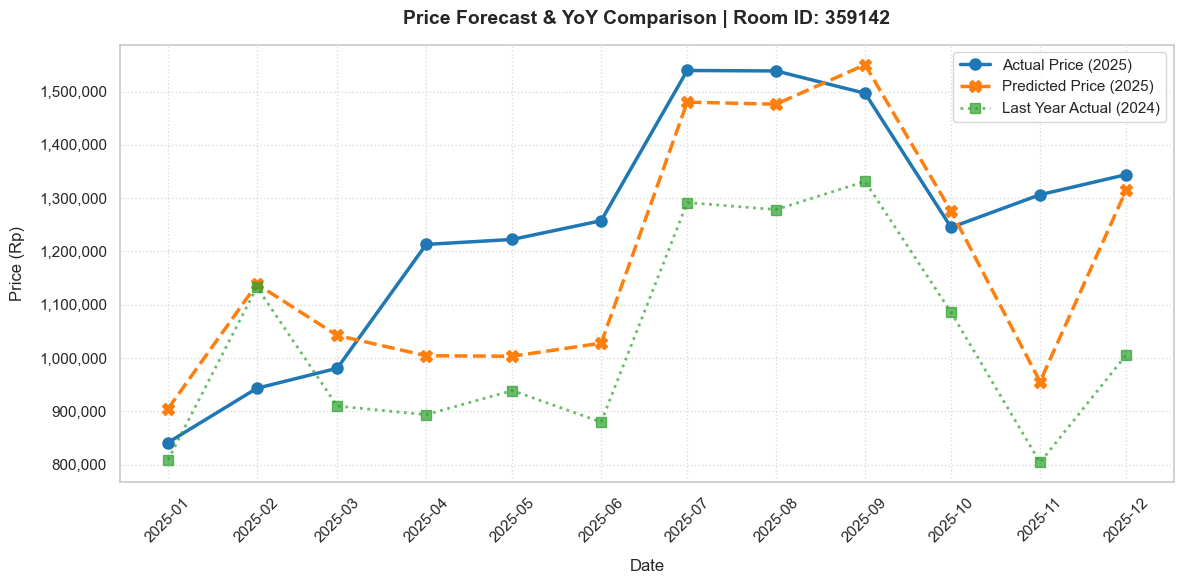

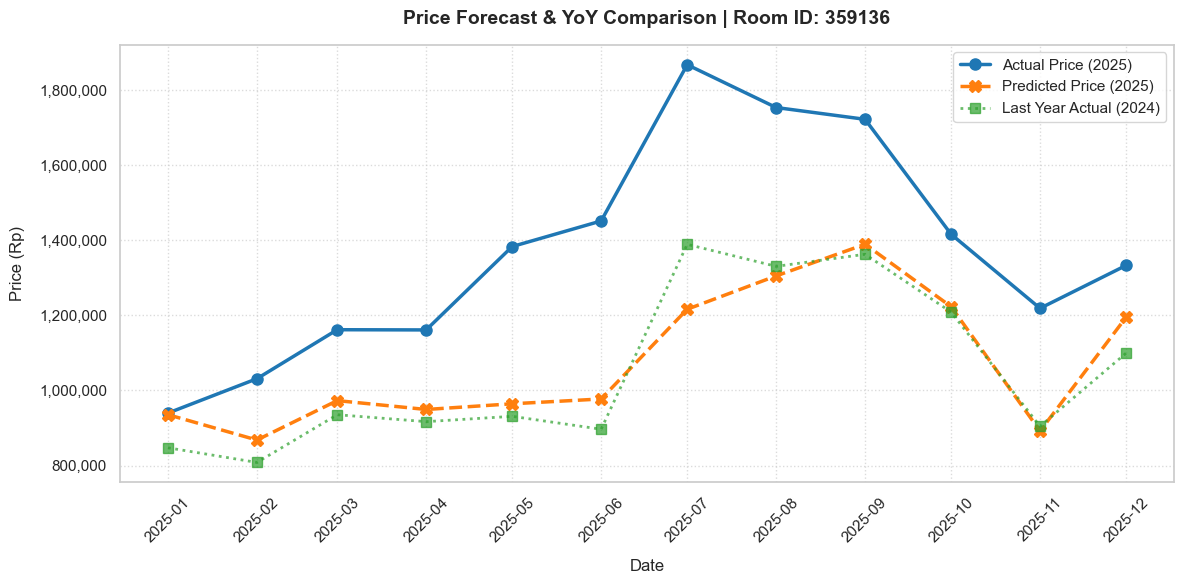

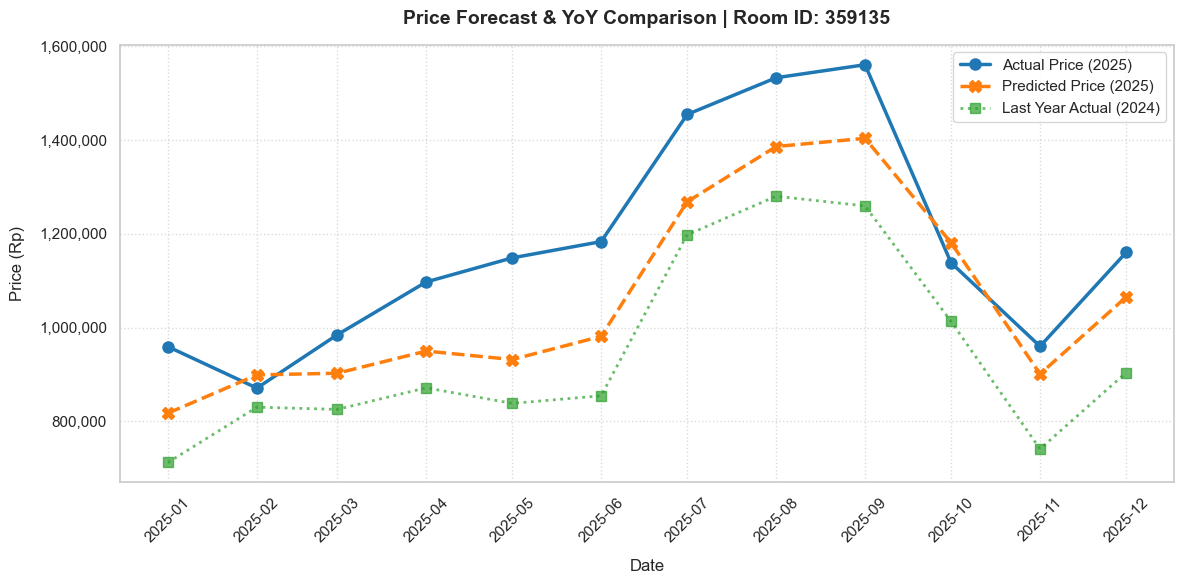

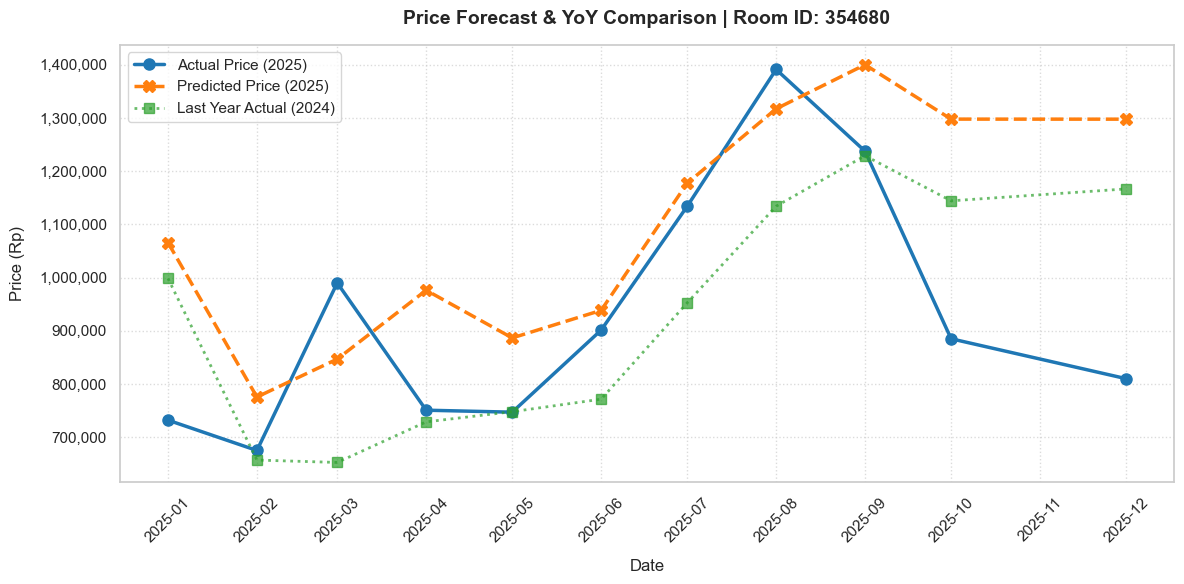

In [37]:
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.dates as mdates
import pandas as pd
import numpy as np

def plot_room_actual_vs_predicted(trained_models, room_ids, full_data):
    """
    Plots Actual, Predicted, and Last Year's Actual prices over time.
    Generates features dynamically per horizon to avoid LightGBM Feature Errors.
    """
    sns.set_theme(style="whitegrid")
    
    # ------------------------------------------------------------------
    # 1. SAFELY HANDLE DATES
    # ------------------------------------------------------------------
    df_master = full_data.copy()
    if 'date' not in df_master.columns:
        if pd.api.types.is_period_dtype(df_master['month_period']):
            df_master['date'] = df_master['month_period'].dt.to_timestamp()
        else:
            df_master['date'] = pd.to_datetime(df_master['month_period'])
    else:
        if pd.api.types.is_period_dtype(df_master['date']):
            df_master['date'] = df_master['date'].dt.to_timestamp()
        else:
            df_master['date'] = pd.to_datetime(df_master['date'])

    # Categorical columns used during training
    cat_cols = [
        "roomId", "propertyId", "room_cfg_room_type",
        "room_cfg_restriction_strategy", "room_cfg_overbooking_protection",
        "room_cfg_unit_allocation", "room_cfg_tier",
    ]

    # ------------------------------------------------------------------
    # 2. PLOTTING LOOP
    # ------------------------------------------------------------------
    for room_id in room_ids:
        dates = []
        actuals = []
        predictions = []
        last_year_actuals = []

        # Predict 2025 month by month (h=1 is Jan, h=12 is Dec)
        for h in range(1, 13):
            if h not in trained_models:
                continue
                
            model = trained_models[h]
            target_year = 2025
            target_month = h 
            
            try:
                # A. Generate the EXACT features this specific model expects
                step_data = advanced_hybrid_fe_direct(df_master, h=h)
                
                # B. Filter for our target prediction month and room
                mask = (
                    (step_data["date"].dt.year == target_year) & 
                    (step_data["date"].dt.month == target_month) & 
                    (step_data["roomId"] == room_id)
                )
                inference_df = step_data[mask].copy()
                
                if inference_df.empty:
                    continue
                    
                # C. Drop columns to match training X
                cols_to_drop = [
                    "price", "log_price", "target_diff", "target_pct",
                    "date", "month_period", f"log_price_lag_{h}", "log_price_lag_12", "id"
                ]
                X_infer = inference_df.drop(columns=[c for c in cols_to_drop if c in inference_df.columns], errors="ignore")
                
                good_lgbm_dtypes = ["number", "category", "bool"]
                X_infer = X_infer.select_dtypes(include=good_lgbm_dtypes).copy()
                
                # Ensure categories match
                for c in cat_cols:
                    if c in X_infer.columns:
                        X_infer[c] = X_infer[c].astype("category")

                # D. Predict and Reconstruct using the YoY anchor
                pred_diff = model.predict(X_infer)
                
                anchor_val = inference_df["price_lag_12"].values[0]
                actual_val = inference_df["price"].values[0]
                
                # Reverse the log1p transformation
                pred_price = np.expm1(np.log1p(anchor_val) + pred_diff)[0]
                
                # Save to lists for plotting
                dates.append(inference_df["date"].values[0])
                actuals.append(actual_val)
                predictions.append(pred_price)
                last_year_actuals.append(anchor_val)

            except Exception as e:
                # If it fails now, it will actually tell us WHY
                print(f"Error predicting Room {room_id} for Month {h}: {e}")

        # ------------------------------------------------------------------
        # 3. RENDER PLOT
        # ------------------------------------------------------------------
        if not dates:
            print(f"Skipping Room ID {room_id}: Could not generate predictions.")
            continue

        fig, ax = plt.subplots(figsize=(12, 6))
        
        ax.plot(dates, actuals, marker='o', label='Actual Price (2025)', color='#1f77b4', linewidth=2.5, markersize=8)
        ax.plot(dates, predictions, marker='X', label='Predicted Price (2025)', color='#ff7f0e', linestyle='--', linewidth=2.5, markersize=8)
        ax.plot(dates, last_year_actuals, marker='s', label='Last Year Actual (2024)', color='#2ca02c', linestyle=':', linewidth=2, markersize=7, alpha=0.7)

        ax.set_title(f"Price Forecast & YoY Comparison | Room ID: {room_id}", fontsize=14, fontweight='bold', pad=15)
        ax.set_xlabel("Date", fontsize=12, labelpad=10)
        ax.set_ylabel("Price (Rp)", fontsize=12, labelpad=10)
        
        ax.xaxis.set_major_locator(mdates.MonthLocator())
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
        plt.xticks(rotation=45)
        
        ax.legend(fontsize=11)
        ax.grid(True, linestyle=':', alpha=0.7)
        ax.get_yaxis().set_major_formatter(plt.FuncFormatter(lambda x, loc: "{:,}".format(int(x))))
        
        plt.tight_layout()
        plt.show()

# ==========================================
# USAGE EXAMPLE (Notice it's much cleaner now!)
# ==========================================
rooms_to_plot = [359142, 359136, 359135, 354680]
# rooms_to_plot = [354683, 354680]

plot_room_actual_vs_predicted(
    trained_models=trained_models, 
    room_ids=rooms_to_plot,
    full_data=data 
)

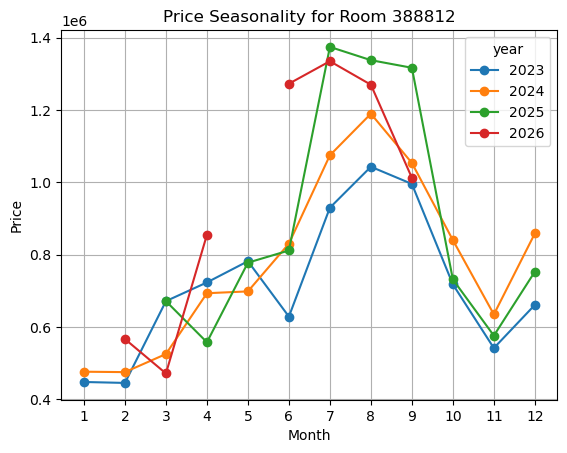

In [34]:
import matplotlib.pyplot as plt
import pandas as pd

# room_id_target = 354683
# room_id_target = 419296
# room_id_target = 370150
# room_id_target = 512299	
# room_id_target = 354683	
# room_id_target = 354680	
room_id_target = 388812
# 5	354683	Deluxe Double or Twin Room with Balcony	Mantra Gili	32.669917	207643.476947	48
# 2	354680

# 354683	
# 1	354680	
# 512299  # change this

subset = data.copy()
subset = subset[subset["roomId"] == room_id_target]

subset["month_period"] = pd.to_datetime(subset["month_period"])
subset["year"] = subset["month_period"].dt.year
subset["month"] = subset["month_period"].dt.month

pivot = subset.pivot(index="month", columns="year", values="price")

pivot.plot(marker="o")

plt.title(f"Price Seasonality for Room {room_id_target}")
plt.xlabel("Month")
plt.ylabel("Price")
plt.xticks(range(1, 13))
plt.grid()

plt.show()

In [ ]:
Property ID: 243134
  ⏳ Fetching year 2023... ✅ Dapat 9080 bookings.
  ⏳ Fetching year 2024... ✅ Dapat 12130 bookings.
  ⏳ Fetching year 2025... ✅ Dapat 11164

In [278]:
data[data['roomId'] == 354680][['date', 'price']].sort_values('date')

,date,price
91,2022-06-01,5.190000e+05
92,2022-07-01,6.570000e+05
93,2022-08-01,7.164583e+05
94,2022-09-01,6.726375e+05
95,2022-10-01,3.553333e+05
96,2022-11-01,6.480000e+05
97,2022-12-01,8.512500e+05
98,2023-01-01,7.275000e+05
99,2023-02-01,6.750000e+05
100,2023-03-01,7.425000e+05


In [337]:
import pandas as pd
import numpy as np

def predict_next_12_months(room_id, start_date, full_data, trained_models):
    """
    Given a starting date (origin), predicts the next 12 months for a specific room.
    Includes Smart Fallbacks for missing YoY anchors.
    """
    print(f"--- Forecasting 12 Months for Room {room_id} ---")
    print(f"Origin Date: {start_date}")
    
    # ------------------------------------------------------------------
    # 1. SAFELY HANDLE DATES
    # ------------------------------------------------------------------
    df_master = full_data.copy()
    if 'date' not in df_master.columns:
        if pd.api.types.is_period_dtype(df_master['month_period']):
            df_master['date'] = df_master['month_period'].dt.to_timestamp()
        else:
            df_master['date'] = pd.to_datetime(df_master['month_period'].astype(str))
    else:
        if pd.api.types.is_period_dtype(df_master['date']):
            df_master['date'] = df_master['date'].dt.to_timestamp()
        else:
            df_master['date'] = pd.to_datetime(df_master['date'])

    start_dt = pd.to_datetime(start_date)
    
    # ------------------------------------------------------------------
    # 2. AUTO-PAD FUTURE DATES (FIXED FORMATTING)
    # ------------------------------------------------------------------
    existing_dates = df_master[df_master['roomId'] == room_id]['date'].values
    target_dates = [start_dt + pd.DateOffset(months=h) for h in range(1, 13)]
    
    missing_dates = [d for d in target_dates if d not in existing_dates]
    
    if missing_dates:
        future_df = pd.DataFrame({'date': missing_dates, 'roomId': room_id})
        
        if 'month_period' in df_master.columns:
            if pd.api.types.is_period_dtype(df_master['month_period']):
                future_df['month_period'] = pd.Series(missing_dates).dt.to_period('M')
            else:
                # 🚨 THE FIX: Force the future dates into clean "YYYY-MM" strings
                future_df['month_period'] = [d.strftime('%Y-%m') for d in missing_dates]
                
        static_cols = ["propertyId", "room_cfg_room_type", "room_cfg_restriction_strategy", 
                       "room_cfg_overbooking_protection", "room_cfg_unit_allocation", "room_cfg_tier"]
        
        last_known_row = df_master[df_master['roomId'] == room_id].iloc[-1]
        for col in static_cols:
            if col in df_master.columns:
                future_df[col] = last_known_row[col]
                
        df_master = pd.concat([df_master, future_df], ignore_index=True)
        df_master = df_master.sort_values(['roomId', 'date']).reset_index(drop=True)

    cat_cols = [
        "roomId", "propertyId", "room_cfg_room_type",
        "room_cfg_restriction_strategy", "room_cfg_overbooking_protection",
        "room_cfg_unit_allocation", "room_cfg_tier",
    ]

    results = []

    # ------------------------------------------------------------------
    # 3. 12-STEP FORECASTING LOOP
    # ------------------------------------------------------------------
    for h in range(1, 13):
        if h not in trained_models:
            print(f"Skipping Month {h}: Model not found.")
            continue
            
        target_dt = start_dt + pd.DateOffset(months=h)
        model = trained_models[h]
        
        try:
            step_data = advanced_hybrid_fe_direct(df_master, h=h)
            
            mask = (step_data["date"] == target_dt) & (step_data["roomId"] == room_id)
            inference_df = step_data[mask].copy()
            
            if inference_df.empty:
                print(f"Month {h} ({target_dt.strftime('%Y-%m')}): Failed to build features.")
                continue
                
            cols_to_drop = [
                "price", "log_price", "target_diff", "target_pct",
                "date", "month_period", f"log_price_lag_{h}", "log_price_lag_12", "id"
            ]
            X_infer = inference_df.drop(columns=[c for c in cols_to_drop if c in inference_df.columns], errors="ignore")
            
            good_lgbm_dtypes = ["number", "category", "bool"]
            X_infer = X_infer.select_dtypes(include=good_lgbm_dtypes).copy()
            
            for c in cat_cols:
                if c in X_infer.columns:
                    X_infer[c] = X_infer[c].astype("category")

            # ----------------------------------------------------------
            # SMART FALLBACK ANCHOR LOGIC
            # ----------------------------------------------------------
            # We use dynamic_anchor_price now instead of strictly price_lag_12
            anchor_val = inference_df["dynamic_anchor_price"].values[0] if "dynamic_anchor_price" in inference_df.columns else np.nan
            baseline_note = f"Dynamic Anchor ({inference_df['anchor_age_months'].values[0]} months old)" if "anchor_age_months" in inference_df.columns else "Unknown Anchor"

            if pd.isna(anchor_val):
                hist_same_month = df_master[
                    (df_master['roomId'] == room_id) & 
                    (df_master['date'].dt.month == target_dt.month) &
                    (df_master['date'] < target_dt) & 
                    (df_master['price'].notna())
                ].sort_values('date')
                
                if not hist_same_month.empty:
                    anchor_val = hist_same_month['price'].values[-1]
                    fallback_year = hist_same_month['date'].dt.year.values[-1]
                    baseline_note = f"Manual Fallback: {fallback_year}"
                else:
                    all_hist = df_master[
                        (df_master['roomId'] == room_id) & 
                        (df_master['date'] < target_dt) &
                        (df_master['price'].notna())
                    ].sort_values('date')
                    
                    if not all_hist.empty:
                        anchor_val = all_hist['price'].values[-1]
                        baseline_note = "Manual Fallback: Last Known Price"
                    else:
                        print(f"Month {h} ({target_dt.strftime('%Y-%m')}): Room has ZERO historical data. Skipping.")
                        continue
                
                if 'dynamic_anchor_price' in X_infer.columns:
                    X_infer['dynamic_anchor_price'] = anchor_val

            # D. Predict
            pred_diff = model.predict(X_infer)
            
            # E. Reconstruct
            pred_price = np.expm1(np.log1p(anchor_val) + pred_diff)[0]
            
            if "price" in inference_df.columns and not pd.isna(inference_df["price"].values[0]):
                actual_val = inference_df["price"].values[0]
            else:
                actual_val = np.nan
            
            results.append({
                "Horizon": f"+{h} Month",
                "Target Date": target_dt.strftime("%Y-%m"),
                "Predicted Price": f"Rp {pred_price:,.0f}",
                "Baseline Used": f"Rp {anchor_val:,.0f}",
                "Baseline Note": baseline_note,
                "Actual Price": f"Rp {actual_val:,.0f}" if pd.notna(actual_val) else "-"
            })

        except Exception as e:
            print(f"Error on Horizon {h}: {e}")

    # ------------------------------------------------------------------
    # 4. PRINT RESULTS
    # ------------------------------------------------------------------
    result_df = pd.DataFrame(results)
    
    if not result_df.empty:
        display(result_df.style.set_properties(**{'text-align': 'right'}))
    else:
        print("No predictions could be generated.")
        
    return result_df
# ==========================================
# HOW TO USE IT
# ==========================================
# Example: Predict the entirety of 2025 by setting the origin to Dec 2024.
# (This means h=1 is Jan 2025, h=2 is Feb 2025... up to h=12 which is Dec 2025)

predicted_df = predict_next_12_months(
    # room_id=359142,
    # room_id=359135,
    # room_id=359142,
    # room_id=354683,	# mantra gili
	room_id=354682,
    start_date='2026-01-01', 
    full_data=data, 
    trained_models=final_production_models
)

--- Forecasting 12 Months for Room 354682 ---
Origin Date: 2026-01-01


,Horizon,Target Date,Predicted Price,Baseline Used,Baseline Note,Actual Price
0,+1 Month,2026-02,"Rp 574,191","Rp 647,163",Dynamic Anchor (12 months old),"Rp 540,000"
1,+2 Month,2026-03,"Rp 644,553","Rp 699,261",Dynamic Anchor (12 months old),"Rp 855,000"
2,+3 Month,2026-04,"Rp 746,842","Rp 733,670",Dynamic Anchor (12 months old),"Rp 697,500"
3,+4 Month,2026-05,"Rp 851,183","Rp 754,849",Dynamic Anchor (12 months old),"Rp 697,500"
4,+5 Month,2026-06,"Rp 838,766","Rp 800,473",Dynamic Anchor (12 months old),"Rp 697,500"
5,+6 Month,2026-07,"Rp 1,334,850","Rp 1,116,136",Dynamic Anchor (12 months old),"Rp 1,125,000"
6,+7 Month,2026-08,"Rp 1,537,707","Rp 1,281,226",Dynamic Anchor (12 months old),"Rp 1,345,000"
7,+8 Month,2026-09,"Rp 1,280,499","Rp 1,187,381",Dynamic Anchor (12 months old),"Rp 1,345,000"
8,+9 Month,2026-10,"Rp 856,225","Rp 771,983",Dynamic Anchor (12 months old),"Rp 1,345,000"
9,+10 Month,2026-11,"Rp 749,569","Rp 630,000",Dynamic Anchor (12 months old),"Rp 1,345,000"


In [291]:
data[data['roomId'] == 359142][['month_period','price']]

,month_period,price
440,2022-06,6.981250e+05
441,2022-07,6.981250e+05
442,2022-08,6.941795e+05
443,2022-09,6.369283e+05
444,2022-10,6.369189e+05
445,2022-11,4.174272e+05
446,2022-12,5.216373e+05
447,2023-01,5.948644e+05
448,2023-02,8.621782e+05
449,2023-03,6.501247e+05


In [108]:
pd.to_datetime(data["month_period"])

TypeError: Passing PeriodDtype data is invalid. Use `data.to_timestamp()` instead

In [290]:
def check_room_gaps(df):
    """
    Analyzes missing price data per roomId after the grid is expanded.
    """
    # 1. Ensure we are looking at the expanded grid but BEFORE filling prices
    # If you've already filled them, this count will be 0.
    
    # Calculate stats per room
    gap_stats = df.groupby('roomId').agg(
        total_months=('date', 'count'),
        missing_months=('price', lambda x: x.isna().sum()),
        first_date=('date', 'min'),
        last_date=('date', 'max')
    )
    
    # Calculate percentage missing
    gap_stats['percent_missing'] = (gap_stats['missing_months'] / gap_stats['total_months']) * 100
    
    # Sort by the most "broken" rooms
    gap_stats = gap_stats.sort_values('percent_missing', ascending=False)
    
    # Summary Info
    print(f"--- Global Data Integrity Report ---")
    print(f"Total Unique Rooms: {len(gap_stats)}")
    print(f"Average Missing Data: {gap_stats['percent_missing'].mean():.2f}%")
    print(f"Rooms with >50% Missing: {len(gap_stats[gap_stats['percent_missing'] > 50])}")
    print("-" * 35)
    
    # Display the top 20 rooms with the most gaps
    display(gap_stats.head(20).style.format({'percent_missing': '{:.1f}%'}))
    
    return gap_stats

# ==========================================
# USAGE
# ==========================================
# 1. Create the grid (Injects NaNs into the gaps)
data_with_gaps = create_continuous_calendar_grid(data)

# 2. Check the report BEFORE you fill the prices
room_report = check_room_gaps(data_with_gaps)

# 3. Optional: Drop rooms that are "Too Broken"
# If a room is 90% missing, the ffill() will just be a flat line and confuse the model.
bad_rooms = room_report[room_report['percent_missing'] > 70].index
# data_with_gaps = data_with_gaps[~data_with_gaps['roomId'].isin(bad_rooms)]

Building continuous calendar grid...
Grid built. Expanded from 2124 to 2200 rows to fill chronological gaps.
--- Global Data Integrity Report ---
Total Unique Rooms: 40
Average Missing Data: 3.45%
Rooms with >50% Missing: 0
-----------------------------------


,total_months,missing_months,first_date,last_date,percent_missing
roomId,,,,,
512299,55,19,2022-06-01 00:00:00,2026-12-01 00:00:00,34.5%
512300,55,19,2022-06-01 00:00:00,2026-12-01 00:00:00,34.5%
515268,55,19,2022-06-01 00:00:00,2026-12-01 00:00:00,34.5%
512298,55,19,2022-06-01 00:00:00,2026-12-01 00:00:00,34.5%
350455,55,0,2022-06-01 00:00:00,2026-12-01 00:00:00,0.0%
350464,55,0,2022-06-01 00:00:00,2026-12-01 00:00:00,0.0%
354680,55,0,2022-06-01 00:00:00,2026-12-01 00:00:00,0.0%
354681,55,0,2022-06-01 00:00:00,2026-12-01 00:00:00,0.0%
359136,55,0,2022-06-01 00:00:00,2026-12-01 00:00:00,0.0%


In [162]:
data

,month_period,id,masterId,propertyId,roomId,numChild,price,commission,range_booking_arrival,num_of_nights,status_confirmed,status_new,subStatus_noShow,subStatus_nonPayment,subStatus_none,subStatus_walkin,title_Honeymoon_decor,title_RO,title_Teman_kim_kasih_breakfast,title_Twin_bed,arrivalTime_16_3,arrivalTime_16_30,arrivalTime__,voucher_geniuscm,groupNote_Room_Only_,custom1_Paid_OTA,custom1_Paid_by_OTA_Auto_Adjusted,referer_Booking_com,refererEditable_Booking_com,reference_45867993_marie,reference_E5593226_ANNA_HUBER,reference_EJ4657377_,reference_PAL643451_LUCAS,reference_PAM228132,reference_YB7740043,channel_booking,apiSource_Booking_com,allowChannelUpdate_all,allowAutoAction_disable,allowAutoAction_enable,allowReview_default,allowCancellation__type_propertyDefault_,cancelTime_2024_08_05T03_15_10Z,year,month,year_month,total_capacity_nights,used_room_nights,leftover_rooms,cal_days_covered,cal_numAvail_mean,cal_numAvail_min,cal_numAvail_max,cal_numAvail_std,cal_numAvail_zero_days,cal_numAvail_low_days,cal_minStay_mean,cal_minStay_max,cal_minStay_restrict_days,cal_maxStay_mean,cal_multiplier_mean,cal_multiplier_max,cal_override_days,cal_soldout_rate,cal_low_avail_rate,cal_restrict_rate,cal_override_rate,prop_latitude,prop_longitude,prop_checkin_start_min,prop_checkin_end_min,prop_checkout_end_min,prop_booking_cutoff_hour,prop_vat_rate,prop_feature_codes_count,prop_group_keywords_count,prop_type_bedAndBreakfast,prop_type_bungalow,prop_type_guesthouse,prop_type_hotel,prop_type_resort,prop_type_villa,prop_country_ID,ch_channel_count,ch_enabled_ratio,ch_publish_ratio,ch_connect_inventory_ratio,ch_connect_limited_ratio,ch_price_per_day_ratio,review_count,avg_review_score,avg_facilities_score,avg_comfort_score,avg_staff_score,avg_value_score,avg_clean_score,avg_location_score,tfidf_beach,tfidf_clean,tfidf_da,tfidf_de,tfidf_der,tfidf_die,tfidf_el,tfidf_en,tfidf_est,tfidf_et,tfidf_friendly,tfidf_good,tfidf_great,tfidf_hotel,tfidf_la,tfidf_le,tfidf_location,tfidf_muy,tfidf_nice,tfidf_place,tfidf_pool,tfidf_que,tfidf_room,tfidf_sehr,tfidf_staff,tfidf_stay,tfidf_super,tfidf_trs,tfidf_un,tfidf_und,qty,room_cfg_qty_raw,room_cfg_min_price,room_cfg_min_stay,room_cfg_max_stay,room_cfg_max_people,room_cfg_max_adult,room_cfg_max_children,room_cfg_tax_percentage,room_cfg_tax_person,room_cfg_rack_rate,room_cfg_cleaning_fee,room_cfg_security_deposit,room_cfg_sell_priority,room_cfg_room_size,room_cfg_block_after_checkout_days,room_cfg_control_priority,room_cfg_include_in_reports,room_cfg_units_count,room_cfg_has_unallocated_unit,room_cfg_feature_count,room_cfg_roomType_bungalow,room_cfg_roomType_double,room_cfg_roomType_family,room_cfg_roomType_quadruple,room_cfg_roomType_single,room_cfg_roomType_triple,room_cfg_roomType_twin,room_cfg_roomType_twindouble,room_cfg_roomType_villa,room_cfg_restrictionStrategy_staythrough,room_cfg_overbookingProtection_property,room_cfg_overbookingProtection_room,room_cfg_unitAllocation_perbooking,room_fc_airport_shuttle,room_fc_air_conditioning,room_fc_baggage_storage,room_fc_balcony,room_fc_bar,room_fc_bathrobe,room_fc_bathroom,room_fc_bath_or_shower,room_fc_bath_shower,room_fc_bath_toilet,room_fc_beach,room_fc_beach_front,room_fc_beach_view,room_fc_bedroom,room_fc_bed_double,room_fc_bed_single,room_fc_bicycle,room_fc_breakfast_included,room_fc_breakfast_in_room,room_fc_breakfast_possible,room_fc_cable,room_fc_car_available,room_fc_cleaning_included,room_fc_cleaning_possible,room_fc_closets_in_room,room_fc_coffee_maker,room_fc_cycling,room_fc_deck_patio_uncovered,room_fc_desk,room_fc_dining_area,room_fc_dining_room_seats,room_fc_garden,room_fc_hair_dryer,room_fc_hangers,room_fc_iron,room_fc_kettle,room_fc_laptop_friendly,room_fc_linens,room_fc_luxory_linen,room_fc_minibar,room_fc_mountain_biking,room_fc_private_bathroom,room_fc_reception_24_hour,room_fc_refrigerator,room_fc_restaurant,room_fc_room_soundproofed,room_fc_safe,room_fc_satellite,room_fc_scuba_or_snorkeling,room_fc_separate_toilet_area,room_fc_shampoo,room

In [ ]:
Mean Holdout MAPE across horizons: 0.2303 (23.03%)
Mean Holdout MAE across horizons : Rp 128,831.87

In [252]:
import numpy as np

def predict_for_room_month(
    test_data,
    x_test_full,
    trained_models,
    room_id,
    year,
    month,
    model_index=7
):
    lag = model_index
    # Sort to ensure lag is correct
    df = test_data.sort_values(["roomId", "date"]).copy()
    
    # Create lag feature
    lag_col = f"price_lag_{lag}"
    df[lag_col] = df.groupby("roomId")["price"].shift(lag)
    
    # Filter mask
    mask = (
        (df["roomId"] == room_id) &
        (df["year"] == year) &
        (df["month"] == month)
    )
    
    # Select data
    X_selected = x_test_full[mask]
    baseline_selected = df.loc[mask, lag_col].values
    
    # Predict diff
    pred_diff = trained_models[model_index].predict(X_selected)
    
    # Reconstruct final prediction
    final_preds = np.expm1(
        np.log1p(baseline_selected) + pred_diff
    )
    
    return final_preds

preds = predict_for_room_month(
    test_data=test_data,
    x_test_full=x_test_full,
    trained_models=final_production_models,
    # room_id=359136,
    # room_id=359135,
    room_id=359142,
    year=2025,
    month=12,
    model_index=6
)

print(preds)

LightGBMError: The number of features in data (305) is not the same as it was in training data (309).
You can set ``predict_disable_shape_check=true`` to discard this error, but please be aware what you are doing.

In [ ]:
359136 359135 359142

In [37]:
test_data = test_data.sort_values(["roomId", "date"]).copy()

test_data["price_lag_6"] = (
    test_data.groupby("roomId")["price"]
    .shift(6)
)
mask = (
    # (test_data['roomId'] == 359136) &
    # (test_data['roomId'] == 359135) &
    (test_data['roomId'] == 359142) &
    (test_data['year'] == 2025) &
    (test_data['month'] == 12)
)

X_selected = x_test_full[mask]
baseline_selected = test_data.loc[mask, 'price_lag_6'].values

pred_test_diff = trained_models[6].predict(X_selected)

final_test_predictions = np.expm1(
    np.log1p(baseline_selected) + pred_test_diff
)

final_test_predictions

array([1470124.58024593])

In [216]:
baseline_selected

array([nan])

In [214]:
X_selected

,propertyId,roomId,year,month,total_capacity_nights,quarter,season_strength,is_peak_season,is_eid_month,is_major_holiday_month,price_lag_10,price_lag_11,price_lag_12,price_lag_15,price_lag_21,price_roll_mean_3,price_roll_std_3,price_roll_max_3,price_roll_min_3,price_roll_mean_6,price_roll_std_6,price_roll_max_6,price_roll_min_6,price_roll_mean_12,price_roll_std_12,price_roll_max_12,price_roll_min_12,price_diff_1,price_diff_12,price_growth_1,price_ema_3,used_room_nights_lag_10,used_room_nights_lag_11,used_room_nights_lag_21,used_room_nights_roll_mean_3,leftover_rooms_lag_10,leftover_rooms_lag_11,leftover_rooms_lag_21,leftover_rooms_roll_mean_3,range_booking_arrival_lag_10,range_booking_arrival_lag_11,range_booking_arrival_lag_21,range_booking_arrival_roll_mean_3,num_of_nights_lag_10,num_of_nights_lag_11,num_of_nights_lag_21,num_of_nights_roll_mean_3,commission_lag_10,commission_lag_11,commission_lag_21,commission_roll_mean_3,numChild_lag_10,numChild_lag_11,numChild_lag_21,numChild_roll_mean_3,occupancy_trend,price_to_mean_ratio,price_vs_property_avg,price_zscore_property,occupancy_price_interaction,trend_3_vs_12,trend_slope,price_vs_roll_mean_6,price_cv_6,is_volatile_room,is_spike,season_price_interaction,peak_price_interaction,occupancy_season_interaction,avg_location_score_lag_10,allowReview_default_lag_10,tfidf_la_lag_10,tfidf_un_lag_10,allowAutoAction_enable_lag_10,reference_EJ4657377__lag_10,tfidf_der_lag_10,channel_booking_lag_10,custom1_Paid_by_OTA_Auto_Adjusted_lag_10,subStatus_nonPayment_lag_10,status_new_lag_10,tfidf_le_lag_10,allowChannelUpdate_all_lag_10,tfidf_da_lag_10,tfidf_stay_lag_10,tfidf_location_lag_10,tfidf_nice_lag_10,tfidf_pool_lag_10,tfidf_place_lag_10,referer_Booking_com_lag_10,subStatus_none_lag_10,tfidf_est_lag_10,tfidf_super_lag_10,tfidf_die_lag_10,subStatus_walkin_lag_10,reference_E5593226_ANNA_HUBER_lag_10,tfidf_clean_lag_10,title_Twin_bed_lag_10,tfidf_room_lag_10,avg_facilities_score_lag_10,voucher_geniuscm_lag_10,arrivalTime_16_30_lag_10,tfidf_great_lag_10,avg_clean_score_lag_10,groupNote_Room_Only__lag_10,custom1_Paid_OTA_lag_10,avg_comfort_score_lag_10,allowCancellation__type_propertyDefault__lag_10,tfidf_en_lag_10,title_Honeymoon_decor_lag_10,tfidf_friendly_lag_10,apiSource_Booking_com_lag_10,arrivalTime___lag_10,review_count_lag_10,tfidf_good_lag_10,tfidf_de_lag_10,tfidf_und_lag_10,tfidf_staff_lag_10,reference_PAL643451_LUCAS_lag_10,title_RO_lag_10,tfidf_que_lag_10,reference_PAM228132_lag_10,allowAutoAction_disable_lag_10,reference_YB7740043_lag_10,tfidf_el_lag_10,subStatus_noShow_lag_10,tfidf_hotel_lag_10,tfidf_muy_lag_10,tfidf_et_lag_10,tfidf_beach_lag_10,title_Teman_kim_kasih_breakfast_lag_10,tfidf_trs_lag_10,avg_staff_score_lag_10,avg_review_score_lag_10,cancelTime_2024_08_05T03_15_10Z_lag_10,reference_45867993_marie_lag_10,refererEditable_Booking_com_lag_10,tfidf_sehr_lag_10,avg_value_score_lag_10,status_confirmed_lag_10,month_sin,month_cos,price_vs_trend_12,trend_strength,month_price_interaction,month_sin_price,month_cos_price,log_price_roll_std_6,log_price_roll_std_12,year_trend
22,163277.0,359136.0,2025,8,124,3,2,1,0,0,1.208834e+06,1.362743e+06,1.330573e+06,931164.305556,739081.635143,1.300717e+06,81182.451621,1.362743e+06,1.208834e+06,1.186567e+06,220244.927323,1389263.0,896823.333333,1.018265e+06,235158.76949,1389263.0,739081.635143,-153909.69697,469752.001221,-0.112941,1.254936e+06,117.0,116.0,107.0,118.666667,7.0,4.0,13.0,4.0,111.242424,131.555556,91.88,121.753173,3.393939,3.444444,3.68,3.202538,730012.757576,847686.592593,471945.36,742121.86886,0.090909,0.074074,0.12,0.166105,1.0,1.187151,1.203632,0.694946,1.414335e+08,1.277386,22266.919548,1.018766,0.185615,1,0,2.417667e+06,1.208834e+06,1.0,9.772727,33.0,0.152294,0.038988,33.0,0.0,0.057446,33.0,0.0,0.0,0.0,0.04892,33.0,0.03482,0.028994,0.100891,0.0,0.007593,0.0,33.0,33.0,0.012202,0.045284,0.025801,0.0,0.0,0.029692,0.0,0.031613,8.977273,33.0,33.0,0.029408,9.204545,33.0,33.0,9.545455,33.0,0.075661,0.0,0.051735,33.0,0.0,0.0,0.031343

In [ ]:
filt_room = x_test_full['roomId'] == 359135
filt_year = x_test_full['year'] == 2026
filt_month = x_test_full['month'] == 5
x_test_full[filt_room & filt_month & filt_year]

,propertyId,roomId,year,month,total_capacity_nights,quarter,season_strength,is_peak_season,is_eid_month,is_major_holiday_month,price_lag_10,price_lag_11,price_lag_12,price_lag_15,price_lag_21,price_roll_mean_3,price_roll_std_3,price_roll_max_3,price_roll_min_3,price_roll_mean_6,price_roll_std_6,price_roll_max_6,price_roll_min_6,price_roll_mean_12,price_roll_std_12,price_roll_max_12,price_roll_min_12,price_diff_1,price_diff_12,price_growth_1,price_ema_3,used_room_nights_lag_10,used_room_nights_lag_11,used_room_nights_lag_21,used_room_nights_roll_mean_3,leftover_rooms_lag_10,leftover_rooms_lag_11,leftover_rooms_lag_21,leftover_rooms_roll_mean_3,range_booking_arrival_lag_10,range_booking_arrival_lag_11,range_booking_arrival_lag_21,range_booking_arrival_roll_mean_3,num_of_nights_lag_10,num_of_nights_lag_11,num_of_nights_lag_21,num_of_nights_roll_mean_3,commission_lag_10,commission_lag_11,commission_lag_21,commission_roll_mean_3,numChild_lag_10,numChild_lag_11,numChild_lag_21,numChild_roll_mean_3,occupancy_trend,price_to_mean_ratio,price_vs_property_avg,price_zscore_property,occupancy_price_interaction,trend_3_vs_12,trend_slope,price_vs_roll_mean_6,price_cv_6,is_volatile_room,is_spike,season_price_interaction,peak_price_interaction,occupancy_season_interaction,avg_location_score_lag_10,allowReview_default_lag_10,tfidf_la_lag_10,tfidf_un_lag_10,allowAutoAction_enable_lag_10,reference_EJ4657377__lag_10,tfidf_der_lag_10,channel_booking_lag_10,custom1_Paid_by_OTA_Auto_Adjusted_lag_10,subStatus_nonPayment_lag_10,status_new_lag_10,tfidf_le_lag_10,allowChannelUpdate_all_lag_10,tfidf_da_lag_10,tfidf_stay_lag_10,tfidf_location_lag_10,tfidf_nice_lag_10,tfidf_pool_lag_10,tfidf_place_lag_10,referer_Booking_com_lag_10,subStatus_none_lag_10,tfidf_est_lag_10,tfidf_super_lag_10,tfidf_die_lag_10,subStatus_walkin_lag_10,reference_E5593226_ANNA_HUBER_lag_10,tfidf_clean_lag_10,title_Twin_bed_lag_10,tfidf_room_lag_10,avg_facilities_score_lag_10,voucher_geniuscm_lag_10,arrivalTime_16_30_lag_10,tfidf_great_lag_10,avg_clean_score_lag_10,groupNote_Room_Only__lag_10,custom1_Paid_OTA_lag_10,avg_comfort_score_lag_10,allowCancellation__type_propertyDefault__lag_10,tfidf_en_lag_10,title_Honeymoon_decor_lag_10,tfidf_friendly_lag_10,apiSource_Booking_com_lag_10,arrivalTime___lag_10,review_count_lag_10,tfidf_good_lag_10,tfidf_de_lag_10,tfidf_und_lag_10,tfidf_staff_lag_10,reference_PAL643451_LUCAS_lag_10,title_RO_lag_10,tfidf_que_lag_10,reference_PAM228132_lag_10,allowAutoAction_disable_lag_10,reference_YB7740043_lag_10,tfidf_el_lag_10,subStatus_noShow_lag_10,tfidf_hotel_lag_10,tfidf_muy_lag_10,tfidf_et_lag_10,tfidf_beach_lag_10,title_Teman_kim_kasih_breakfast_lag_10,tfidf_trs_lag_10,avg_staff_score_lag_10,avg_review_score_lag_10,cancelTime_2024_08_05T03_15_10Z_lag_10,reference_45867993_marie_lag_10,refererEditable_Booking_com_lag_10,tfidf_sehr_lag_10,avg_value_score_lag_10,status_confirmed_lag_10,month_sin,month_cos,price_vs_trend_12,trend_strength,month_price_interaction,month_sin_price,month_cos_price,log_price_roll_std_6,log_price_roll_std_12,year_trend
50,163277.0,359142.0,2026,5,310,2,1,0,0,0,1.539437e+06,1.257685e+06,1.222580e+06,943391.709184,1.278525e+06,1.339901e+06,173692.553253,1.539437e+06,1.222580e+06,1.192875e+06,215757.560646,1.539437e+06,943391.709184,1.125374e+06,218568.410247,1.539437e+06,804287.888776,281752.145931,260911.44817,0.224024,1.372548e+06,305.0,263.0,312.0,276.0,5.0,37.0,-2.0,30.666667,141.071429,73.970588,138.631579,89.194333,3.642857,3.352941,3.276316,3.222643,1.037131e+06,857696.058824,723469.039474,850483.237875,0.528571,0.191176,0.447368,0.310954,42.0,1.367934,1.532813,1.818357,4.695282e+08,1.190627,346562.319325,1.290527,0.180872,1,0,1.539437e+06,0.0,0.0,9.772727,70.0,0.152294,0.038988,70.0,0.0,0.057446,70.0,0.0,0.0,0.0,0.04892,70.0,0.03482,0.028994,0.100891,0.0,0.007593,0.0,70.0,70.0,0.012202,0.045284,0.025801,0.0,0.0,0.029692,0.0,0.031613,8.977273,70.0,70.0,0.029408,9.204545,70.0,70.0,9.545455,70.0,0.075661,0.0,0.051735,70.0,0

In [137]:
final_model.predict(x_test_full)

array([ 0.28455383,  0.18022226, -0.02987059, -0.0173718 ,  0.06977584,
        0.06910901,  0.17693678,  0.14399862,  0.18794647, -0.02933851,
       -0.1272426 ,  0.18739402,  0.04329553,  0.17474131,  0.13593363,
        0.17126423,  0.19274042,  0.03240215,  0.22655749,  0.20306334,
        0.15213975,  0.2328074 ,  0.23132553,  0.04757526,  0.05576755,
        0.22165781, -0.00419445, -0.06804376,  0.25219548,  0.21165028,
        0.18521155,  0.27435337,  0.20158833,  0.24648512,  0.09797842,
        0.17468845,  0.11569778, -0.0398098 , -0.03437158, -0.09577804,
        0.08878486,  0.16319703,  0.2070164 ,  0.12958843,  0.16749446,
        0.22911018,  0.1946344 ,  0.23590488,  0.00157933,  0.23538787,
        0.17216096,  0.1116792 ,  0.00793398,  0.02439255,  0.16884614,
        0.17298186,  0.16655468,  0.23210485,  0.15920129,  0.22405005,
        0.10554205,  0.07936019,  0.12885469,  0.1149995 ,  0.11171344,
        0.16958636,  0.18681891, -0.05324634,  0.03757646, -0.06

In [ ]:
Mean Holdout MAPE across horizons: 0.2347 (23.47%)
Mean Holdout MAE across horizons : Rp 130,458.87

In [ ]:
# Pa
Mean Holdout MAPE across horizons: 0.2358 (23.58%)
Mean Holdout MAE across horizons : Rp 131,044.69

In [ ]:
Mean Holdout MAPE across horizons: 0.2362 (23.62%)
Mean Holdout MAE across horizons : Rp 131,312.78

In [ ]:
🔹 Mean Holdout MAPE across 12 months : 0.2378 (23.78%)
🔹 Mean Holdout MAE across 12 months  : Rp 136,079.21

In [ ]:
🔹 Mean Holdout MAPE across 12 months : 0.2384 (23.84%)
🔹 Mean Holdout MAE across 12 months  : Rp 147,186.31

In [ ]:
163277